# TC-CVE: Trajectory-Conditioned Computational Value Experiment

## Research Question

Does the history of neural computation contain information about the
marginal value of an additional computational step beyond the current
hidden state and prediction?

## Core Hypothesis

I(ΔL_{t+1}; H_{0:t-1}, P_{0:t-1} | h_t, p_t) > 0

## Experimental Strategy

1. Train an iterative neural classifier.
2. Record hidden-state and prediction trajectories.
3. Measure the loss improvement from the next computational step.
4. Train a predictor using only the current state.
5. Train another predictor using the computational trajectory.
6. Compare their out-of-sample predictive performance.

The experiment is exploratory and is designed to falsify the hypothesis.

### Experiment A — Computational Dynamics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.11.0+cpu
CUDA available: False
Device: cpu


In [2]:
# ============================================================
# TC-CVE — Step 3: Synthetic Classification Dataset
# ============================================================

import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset parameters
N_TRAIN = 10000
N_TEST = 3000

def make_dataset(n, seed):
    rng = np.random.default_rng(seed)

    # Two overlapping Gaussian classes
    n0 = n // 2
    n1 = n - n0

    X0 = rng.normal(
        loc=[-1.0, 0.0],
        scale=[1.0, 1.0],
        size=(n0, 2)
    )

    X1 = rng.normal(
        loc=[1.0, 0.0],
        scale=[1.0, 1.0],
        size=(n1, 2)
    )

    X = np.vstack([X0, X1])
    y = np.concatenate([
        np.zeros(n0),
        np.ones(n1)
    ])

    # Shuffle
    idx = rng.permutation(n)
    X = X[idx]
    y = y[idx]

    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )

X_train, y_train = make_dataset(N_TRAIN, SEED)
X_test, y_test = make_dataset(N_TEST, SEED + 1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Input dimension:", X_train.shape[1])
print("Number of classes:", len(torch.unique(y_train)))

Training samples: 10000
Test samples: 3000
Input dimension: 2
Number of classes: 2


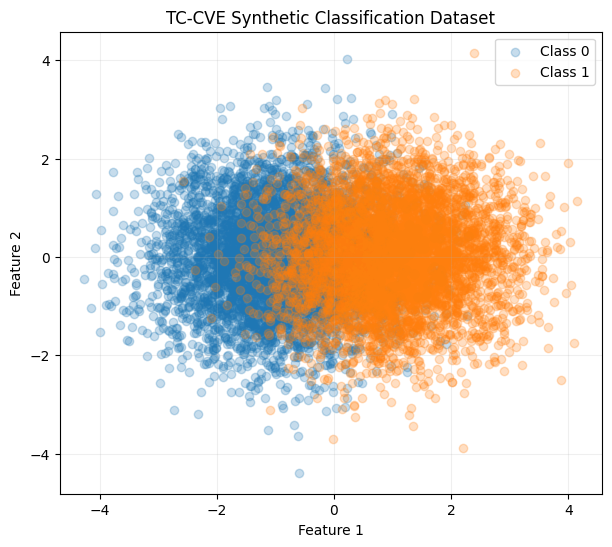

In [3]:
# ============================================================
# Visualize the dataset
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    alpha=0.25,
    label="Class 0"
)

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    alpha=0.25,
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("TC-CVE Synthetic Classification Dataset")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [4]:
# ============================================================
# TC-CVE — Step 4: Iterative Neural Classifier
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class IterativeClassifier(nn.Module):
    def __init__(
        self,
        input_dim=2,
        hidden_dim=32,
        num_classes=2
    ):
        super().__init__()

        # Encode the input into the initial hidden state
        self.input_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh()
        )

        # Iterative computation
        self.transition = nn.Sequential(
            nn.Linear(hidden_dim + input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )

        # Prediction head
        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, x, num_steps=10):

        # Initial computational state
        h = self.input_encoder(x)

        states = []
        predictions = []

        for t in range(num_steps):

            # Prediction at current state
            logits = self.classifier(h)
            p = F.softmax(logits, dim=-1)

            states.append(h)
            predictions.append(p)

            # Next computational state
            h = self.transition(
                torch.cat([h, x], dim=-1)
            )

        return states, predictions


# Create model
model = IterativeClassifier(
    input_dim=2,
    hidden_dim=32,
    num_classes=2
).to(device)

print(model)

IterativeClassifier(
  (input_encoder): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
  )
  (transition): Sequential(
    (0): Linear(in_features=34, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
  )
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)


In [5]:
# ============================================================
# TC-CVE — Step 5: Verify Computational Trajectory
# ============================================================

model.eval()

with torch.no_grad():
    sample_x = X_train[:5].to(device)

    states, predictions = model(
        sample_x,
        num_steps=6
    )

print("Number of computational states:", len(states))
print("State shape at t=0:", states[0].shape)
print("Prediction shape at t=0:", predictions[0].shape)

print("\nTrajectory:")
for t, (h, p) in enumerate(zip(states, predictions)):
    print(
        f"t={t}: "
        f"h shape={tuple(h.shape)}, "
        f"p[0]={p[0].cpu().numpy()}"
    )

Number of computational states: 6
State shape at t=0: torch.Size([5, 32])
Prediction shape at t=0: torch.Size([5, 2])

Trajectory:
t=0: h shape=(5, 32), p[0]=[0.55883193 0.4411681 ]
t=1: h shape=(5, 32), p[0]=[0.5705707  0.42942923]
t=2: h shape=(5, 32), p[0]=[0.5682622  0.43173778]
t=3: h shape=(5, 32), p[0]=[0.56656784 0.43343216]
t=4: h shape=(5, 32), p[0]=[0.5668933  0.43310678]
t=5: h shape=(5, 32), p[0]=[0.5670277  0.43297225]


In [6]:
# ============================================================
# TC-CVE — Step 6: Train the Iterative Classifier
# ============================================================

import torch.optim as optim

NUM_STEPS = 10
EPOCHS = 100
LEARNING_RATE = 1e-3

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

criterion = nn.CrossEntropyLoss()

model.train()

for epoch in range(EPOCHS):

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        states, predictions = model(
            x,
            num_steps=NUM_STEPS
        )

        # IMPORTANT:
        # Train only from the final computational step.
        final_logits = torch.log(
            predictions[-1].clamp_min(1e-8)
        )

        loss = criterion(final_logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(x)

        predicted = predictions[-1].argmax(dim=-1)
        total_correct += (predicted == y).sum().item()
        total_samples += len(x)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Loss: {avg_loss:.4f} | "
            f"Accuracy: {accuracy:.4f}"
        )

Epoch  10 | Loss: 0.3498 | Accuracy: 0.8446
Epoch  20 | Loss: 0.3490 | Accuracy: 0.8467
Epoch  30 | Loss: 0.3494 | Accuracy: 0.8450
Epoch  40 | Loss: 0.3491 | Accuracy: 0.8458
Epoch  50 | Loss: 0.3489 | Accuracy: 0.8445
Epoch  60 | Loss: 0.3488 | Accuracy: 0.8461
Epoch  70 | Loss: 0.3488 | Accuracy: 0.8446
Epoch  80 | Loss: 0.3487 | Accuracy: 0.8448
Epoch  90 | Loss: 0.3491 | Accuracy: 0.8452
Epoch 100 | Loss: 0.3488 | Accuracy: 0.8462


In [7]:
# ============================================================
# TC-CVE — Step 7: Test Accuracy
# ============================================================

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        states, predictions = model(
            x,
            num_steps=NUM_STEPS
        )

        predicted = predictions[-1].argmax(dim=-1)

        correct += (predicted == y).sum().item()
        total += len(y)

test_accuracy = correct / total

print(f"Final test accuracy: {test_accuracy:.4f}")

Final test accuracy: 0.8277


In [8]:
# ============================================================
# TC-CVE — Step 8: Loss Across Computational Time
# ============================================================

model.eval()

all_losses = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        states, predictions = model(
            x,
            num_steps=NUM_STEPS + 1
        )

        batch_losses = []

        for p in predictions:

            loss = F.cross_entropy(
                torch.log(p.clamp_min(1e-8)),
                y,
                reduction="none"
            )

            batch_losses.append(
                loss.cpu()
            )

        # [steps, batch]
        batch_losses = torch.stack(batch_losses)

        all_losses.append(batch_losses)

all_losses = torch.cat(all_losses, dim=1)

mean_loss = all_losses.mean(dim=1).numpy()

print("Mean loss by computational step:")

for t, loss in enumerate(mean_loss):
    print(f"t={t:2d}: {loss:.6f}")

Mean loss by computational step:
t= 0: 0.733878
t= 1: 0.425286
t= 2: 0.392519
t= 3: 0.377859
t= 4: 0.378347
t= 5: 0.377368
t= 6: 0.377699
t= 7: 0.377707
t= 8: 0.377625
t= 9: 0.377652
t=10: 0.377645


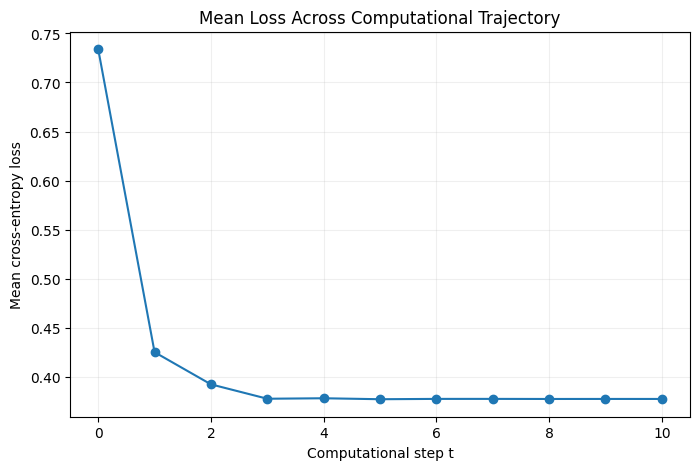

In [9]:
# ============================================================
# Plot Mean Loss Trajectory
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(mean_loss)),
    mean_loss,
    marker="o"
)

plt.xlabel("Computational step t")
plt.ylabel("Mean cross-entropy loss")
plt.title("Mean Loss Across Computational Trajectory")
plt.grid(alpha=0.2)

plt.show()

In [10]:
# ============================================================
# TC-CVE — Step 9: Individual Loss Trajectories
# ============================================================

model.eval()

# Take one test batch
x_batch, y_batch = next(iter(test_loader))

x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():

    states, predictions = model(
        x_batch,
        num_steps=NUM_STEPS + 1
    )

# Calculate per-example loss at every step
loss_matrix = []

for p in predictions:

    loss = F.cross_entropy(
        torch.log(p.clamp_min(1e-8)),
        y_batch,
        reduction="none"
    )

    loss_matrix.append(loss)

# Shape: [steps, examples]
loss_matrix = torch.stack(loss_matrix)

# Marginal improvement
delta_loss = loss_matrix[:-1] - loss_matrix[1:]

print("Loss matrix shape:", loss_matrix.shape)
print("Delta-loss matrix shape:", delta_loss.shape)

# Show first 10 examples
for i in range(10):

    losses = loss_matrix[:, i].cpu().numpy()
    deltas = delta_loss[:, i].cpu().numpy()

    print(f"\nExample {i}")
    print("Losses :", np.round(losses, 4))
    print("ΔLoss  :", np.round(deltas, 4))
    print("Label  :", y_batch[i].item())

Loss matrix shape: torch.Size([11, 256])
Delta-loss matrix shape: torch.Size([10, 256])

Example 0
Losses : [0.4322 1.5177 0.4993 0.6547 0.8493 0.7567 0.767  0.7669 0.76   0.7651
 0.7647]
ΔLoss  : [-1.0855e+00  1.0184e+00 -1.5540e-01 -1.9460e-01  9.2600e-02 -1.0300e-02
  1.0000e-04  6.9000e-03 -5.0000e-03  4.0000e-04]
Label  : 0

Example 1
Losses : [0.6028 0.0538 0.0368 0.0799 0.0751 0.0729 0.071  0.0708 0.0711 0.0713
 0.0712]
ΔLoss  : [ 5.49e-01  1.71e-02 -4.32e-02  4.90e-03  2.20e-03  1.90e-03  3.00e-04
 -4.00e-04 -1.00e-04  0.00e+00]
Label  : 0

Example 2
Losses : [0.4164 1.1906 0.3974 0.5223 0.6971 0.6232 0.6255 0.6262 0.6207 0.6247
 0.6246]
ΔLoss  : [-7.742e-01  7.932e-01 -1.248e-01 -1.749e-01  7.390e-02 -2.300e-03
 -7.000e-04  5.400e-03 -4.000e-03  1.000e-04]
Label  : 0

Example 3
Losses : [0.8582 0.0057 0.014  0.0169 0.0173 0.0167 0.0165 0.0165 0.0165 0.0165
 0.0165]
ΔLoss  : [ 8.525e-01 -8.400e-03 -2.900e-03 -3.000e-04  6.000e-04  2.000e-04
 -0.000e+00 -0.000e+00 -0.000e+00  0.

In [11]:
# ============================================================
# TC-CVE — Step 10: Distribution of Marginal Computational Value
# ============================================================

# delta_loss has shape:
# [transition step, example]

delta_np = delta_loss.cpu().numpy()

print("Marginal loss improvement statistics")
print("=" * 60)

for t in range(delta_np.shape[0]):

    values = delta_np[t]

    print(
        f"t={t:2d} -> t={t+1:2d} | "
        f"mean={values.mean(): .6f} | "
        f"std={values.std(): .6f} | "
        f"min={values.min(): .6f} | "
        f"max={values.max(): .6f} | "
        f"P(improvement)={(values > 0).mean():.3f}"
    )

Marginal loss improvement statistics
t= 0 -> t= 1 | mean= 0.283020 | std= 0.895060 | min=-4.013461 | max= 1.157240 | P(improvement)=0.816
t= 1 -> t= 2 | mean= 0.057132 | std= 0.454664 | min=-0.886521 | max= 1.572145 | P(improvement)=0.488
t= 2 -> t= 3 | mean= 0.003833 | std= 0.176743 | min=-0.338837 | max= 0.765939 | P(improvement)=0.258
t= 3 -> t= 4 | mean=-0.002584 | std= 0.061670 | min=-0.341345 | max= 0.213254 | P(improvement)=0.598
t= 4 -> t= 5 | mean= 0.002830 | std= 0.035512 | min=-0.081397 | max= 0.117522 | P(improvement)=0.688
t= 5 -> t= 6 | mean=-0.000719 | std= 0.013129 | min=-0.052297 | max= 0.025990 | P(improvement)=0.793
t= 6 -> t= 7 | mean= 0.000081 | std= 0.003412 | min=-0.010053 | max= 0.011001 | P(improvement)=0.609
t= 7 -> t= 8 | mean= 0.000157 | std= 0.002215 | min=-0.005917 | max= 0.009985 | P(improvement)=0.180
t= 8 -> t= 9 | mean=-0.000118 | std= 0.001810 | min=-0.006062 | max= 0.004651 | P(improvement)=0.309
t= 9 -> t=10 | mean= 0.000027 | std= 0.000602 | min=-0

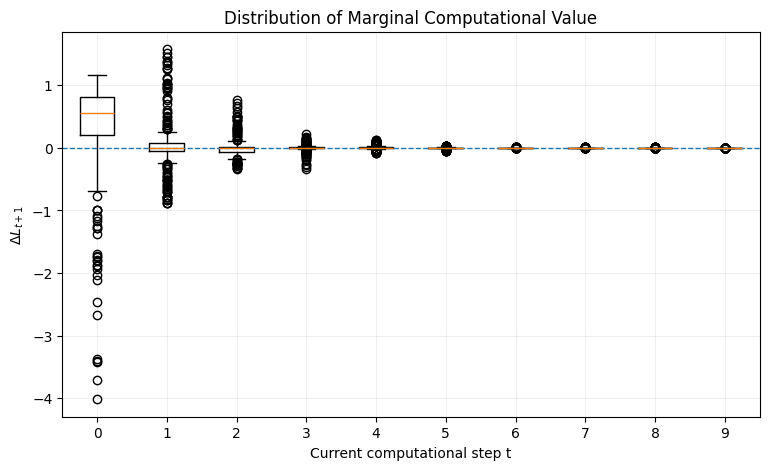

In [12]:
# ============================================================
# Visualize Distribution of Marginal Value
# ============================================================

plt.figure(figsize=(9, 5))

plt.boxplot(
    [delta_np[t] for t in range(delta_np.shape[0])],
    positions=range(delta_np.shape[0])
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Current computational step t")
plt.ylabel(r"$\Delta L_{t+1}$")
plt.title("Distribution of Marginal Computational Value")

plt.grid(alpha=0.2)
plt.show()

In [13]:
# ============================================================
# TC-CVE — Step 11: Collect Full Test Trajectories
# ============================================================

model.eval()

NUM_ANALYSIS_STEPS = 10

all_states = []
all_predictions = []
all_targets = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        states, predictions = model(
            x,
            num_steps=NUM_ANALYSIS_STEPS + 1
        )

        # [steps, batch, hidden_dim]
        states_tensor = torch.stack(states)

        # [steps, batch, classes]
        predictions_tensor = torch.stack(predictions)

        # Calculate loss at every step
        losses = []

        for p in predictions:
            loss = F.cross_entropy(
                torch.log(p.clamp_min(1e-8)),
                y,
                reduction="none"
            )
            losses.append(loss)

        # [steps, batch]
        losses = torch.stack(losses)

        # Marginal value of next computation
        # [steps-1, batch]
        deltas = losses[:-1] - losses[1:]

        all_states.append(states_tensor.cpu())
        all_predictions.append(predictions_tensor.cpu())
        all_targets.append(deltas.cpu())


all_states = torch.cat(all_states, dim=1)
all_predictions = torch.cat(all_predictions, dim=1)
all_targets = torch.cat(all_targets, dim=1)

print("States shape:", all_states.shape)
print("Predictions shape:", all_predictions.shape)
print("Target ΔL shape:", all_targets.shape)

print("\nNumber of test examples:", all_states.shape[1])
print("Number of computational states:", all_states.shape[0])
print("Hidden dimension:", all_states.shape[2])

States shape: torch.Size([11, 3000, 32])
Predictions shape: torch.Size([11, 3000, 2])
Target ΔL shape: torch.Size([10, 3000])

Number of test examples: 3000
Number of computational states: 11
Hidden dimension: 32


In [14]:
import numpy as np

np.save("all_states.npy", all_states.cpu().numpy())
np.save("all_predictions.npy", all_predictions.cpu().numpy())

In [15]:
# ============================================================
# Full-Test Marginal Value Statistics
# ============================================================

delta_full = all_targets.numpy()

print("Full test-set marginal computational value")
print("=" * 70)

for t in range(delta_full.shape[0]):

    values = delta_full[t]

    print(
        f"t={t:2d} -> t={t+1:2d} | "
        f"mean={values.mean(): .6f} | "
        f"std={values.std(): .6f} | "
        f"min={values.min(): .6f} | "
        f"max={values.max(): .6f} | "
        f"P(improvement)={(values > 0).mean():.3f}"
    )

Full test-set marginal computational value
t= 0 -> t= 1 | mean= 0.308592 | std= 0.882430 | min=-4.976470 | max= 1.415905 | P(improvement)=0.805
t= 1 -> t= 2 | mean= 0.032767 | std= 0.448758 | min=-0.886521 | max= 2.022455 | P(improvement)=0.445
t= 2 -> t= 3 | mean= 0.014660 | std= 0.184670 | min=-0.339001 | max= 0.801637 | P(improvement)=0.315
t= 3 -> t= 4 | mean=-0.000488 | std= 0.065606 | min=-0.341345 | max= 0.258072 | P(improvement)=0.589
t= 4 -> t= 5 | mean= 0.000979 | std= 0.036538 | min=-0.082018 | max= 0.119439 | P(improvement)=0.639
t= 5 -> t= 6 | mean=-0.000331 | std= 0.012454 | min=-0.052297 | max= 0.027357 | P(improvement)=0.780
t= 6 -> t= 7 | mean=-0.000008 | std= 0.003235 | min=-0.010067 | max= 0.011001 | P(improvement)=0.585
t= 7 -> t= 8 | mean= 0.000082 | std= 0.002363 | min=-0.006760 | max= 0.010003 | P(improvement)=0.191
t= 8 -> t= 9 | mean=-0.000027 | std= 0.001878 | min=-0.006213 | max= 0.004734 | P(improvement)=0.358
t= 9 -> t=10 | mean= 0.000007 | std= 0.000558 | 

In [16]:
# ============================================================
# Absolute Marginal Value
# ============================================================

print("\nAbsolute marginal value")
print("=" * 70)

for t in range(delta_full.shape[0]):

    values = np.abs(delta_full[t])

    print(
        f"t={t:2d} -> t={t+1:2d} | "
        f"mean |ΔL|={values.mean():.6f} | "
        f"median |ΔL|={np.median(values):.6f}"
    )


Absolute marginal value
t= 0 -> t= 1 | mean |ΔL|=0.764609 | median |ΔL|=0.731910
t= 1 -> t= 2 | mean |ΔL|=0.264949 | median |ΔL|=0.079254
t= 2 -> t= 3 | mean |ΔL|=0.108513 | median |ΔL|=0.042857
t= 3 -> t= 4 | mean |ΔL|=0.034991 | median |ΔL|=0.008744
t= 4 -> t= 5 | mean |ΔL|=0.022072 | median |ΔL|=0.006185
t= 5 -> t= 6 | mean |ΔL|=0.007155 | median |ΔL|=0.001950
t= 6 -> t= 7 | mean |ΔL|=0.001825 | median |ΔL|=0.000405
t= 7 -> t= 8 | mean |ΔL|=0.001381 | median |ΔL|=0.000529
t= 8 -> t= 9 | mean |ΔL|=0.001099 | median |ΔL|=0.000223
t= 9 -> t=10 | mean |ΔL|=0.000302 | median |ΔL|=0.000047


### Experiment B — Future Loss Prediction

In [17]:
# ============================================================
# TC-CVE — Step 12A
# Fixed-step prediction dataset: t = 3 -> 4
# ============================================================

TARGET_STEP = 3

# all_states:
# [11, 3000, 32]
#
# all_predictions:
# [11, 3000, 2]
#
# all_targets:
# [10, 3000]

# ------------------------------------------------------------
# State-only features
# ------------------------------------------------------------

h_t = all_states[TARGET_STEP]          # [3000, 32]
p_t = all_predictions[TARGET_STEP]     # [3000, 2]

X_state = torch.cat(
    [h_t, p_t],
    dim=1
)

# ------------------------------------------------------------
# Full trajectory up to t=3
# ------------------------------------------------------------

trajectory_parts = []

for step in range(TARGET_STEP + 1):

    trajectory_parts.append(
        all_states[step]
    )

    trajectory_parts.append(
        all_predictions[step]
    )

X_trajectory = torch.cat(
    trajectory_parts,
    dim=1
)

# Target: improvement from t=3 to t=4
y_target = all_targets[TARGET_STEP]

print("State-only feature shape:",
      X_state.shape)

print("Trajectory feature shape:",
      X_trajectory.shape)

print("Target shape:",
      y_target.shape)

print("\nTarget statistics:")
print("Mean:", y_target.mean().item())
print("Std :", y_target.std().item())
print("Min :", y_target.min().item())
print("Max :", y_target.max().item())

State-only feature shape: torch.Size([3000, 34])
Trajectory feature shape: torch.Size([3000, 136])
Target shape: torch.Size([3000])

Target statistics:
Mean: -0.0004876710590906441
Std : 0.06561648845672607
Min : -0.3413454294204712
Max : 0.2580717206001282


In [19]:
# ============================================================
# TC-CVE — Step 12B
# Train/test split without trajectory leakage
# ============================================================

N = X_state.shape[0]

rng = np.random.default_rng(123)

indices = rng.permutation(N)

train_size = int(0.8 * N)

train_idx = torch.tensor(
    indices[:train_size],
    dtype=torch.long
)

test_idx = torch.tensor(
    indices[train_size:],
    dtype=torch.long
)

X_state_train = X_state[train_idx]
X_state_test = X_state[test_idx]

X_traj_train = X_trajectory[train_idx]
X_traj_test = X_trajectory[test_idx]

y_train = y_target[train_idx]
y_test = y_target[test_idx]

print("Training examples:", len(train_idx))
print("Test examples:", len(test_idx))

Training examples: 2400
Test examples: 600


In [20]:
# ============================================================
# TC-CVE — Step 12C
# Feature normalization
# ============================================================

def normalize_train_test(X_train, X_test):

    mean = X_train.mean(dim=0, keepdim=True)
    std = X_train.std(dim=0, keepdim=True)

    std = torch.where(
        std < 1e-8,
        torch.ones_like(std),
        std
    )

    X_train_norm = (X_train - mean) / std
    X_test_norm = (X_test - mean) / std

    return X_train_norm, X_test_norm


X_state_train, X_state_test = normalize_train_test(
    X_state_train,
    X_state_test
)

X_traj_train, X_traj_test = normalize_train_test(
    X_traj_train,
    X_traj_test
)

print("Normalization complete.")

Normalization complete.


In [21]:
# ============================================================
# TC-CVE — Step 12D
# Value prediction models
# ============================================================

class ValuePredictor(nn.Module):

    def __init__(self, input_dim, hidden_dim=64):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


state_predictor = ValuePredictor(
    input_dim=X_state_train.shape[1]
).to(device)

trajectory_predictor = ValuePredictor(
    input_dim=X_traj_train.shape[1]
).to(device)

print("State predictor:")
print(state_predictor)

print("\nTrajectory predictor:")
print(trajectory_predictor)

State predictor:
ValuePredictor(
  (network): Sequential(
    (0): Linear(in_features=34, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trajectory predictor:
ValuePredictor(
  (network): Sequential(
    (0): Linear(in_features=136, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [22]:
# ============================================================
# TC-CVE — Step 12E
# Train value predictor
# ============================================================

def train_value_predictor(
    model,
    X_train,
    y_train,
    epochs=300,
    lr=1e-3
):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.MSELoss()

    model.train()

    for epoch in range(epochs):

        optimizer.zero_grad()

        pred = model(X_train.to(device))

        loss = criterion(
            pred,
            y_train.to(device)
        )

        loss.backward()
        optimizer.step()

        if (epoch + 1) % 100 == 0:
            print(
                f"Epoch {epoch+1:3d} | "
                f"Train MSE: {loss.item():.8f}"
            )

    return model

In [ ]:
print("Training STATE-ONLY predictor")
print("=" * 50)

state_predictor = train_value_predictor(
    state_predictor,
    X_state_train,
    y_train
)

Training STATE-ONLY predictor
Epoch 100 | Train MSE: 0.00438973
Epoch 200 | Train MSE: 0.00434602
Epoch 300 | Train MSE: 0.00430378


In [23]:
print("\nTraining TRAJECTORY predictor")
print("=" * 50)

trajectory_predictor = train_value_predictor(
    trajectory_predictor,
    X_traj_train,
    y_train
)


Training TRAJECTORY predictor
Epoch 100 | Train MSE: 0.00428917
Epoch 200 | Train MSE: 0.00418517
Epoch 300 | Train MSE: 0.00408155


In [24]:
# ============================================================
# TC-CVE — Step 13: Held-Out Evaluation
# ============================================================

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

state_predictor.eval()
trajectory_predictor.eval()

with torch.no_grad():

    state_pred = state_predictor(
        X_state_test.to(device)
    ).cpu().numpy()

    trajectory_pred = trajectory_predictor(
        X_traj_test.to(device)
    ).cpu().numpy()

y_true = y_test.numpy()

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

state_mse = mean_squared_error(
    y_true,
    state_pred
)

state_mae = mean_absolute_error(
    y_true,
    state_pred
)

state_r2 = r2_score(
    y_true,
    state_pred
)


trajectory_mse = mean_squared_error(
    y_true,
    trajectory_pred
)

trajectory_mae = mean_absolute_error(
    y_true,
    trajectory_pred
)

trajectory_r2 = r2_score(
    y_true,
    trajectory_pred
)

print("=" * 60)
print("HELD-OUT TEST PERFORMANCE")
print("=" * 60)

print("\nSTATE-ONLY")
print(f"MSE : {state_mse:.8f}")
print(f"MAE : {state_mae:.8f}")
print(f"R²  : {state_r2:.6f}")

print("\nTRAJECTORY")
print(f"MSE : {trajectory_mse:.8f}")
print(f"MAE : {trajectory_mae:.8f}")
print(f"R²  : {trajectory_r2:.6f}")

print("\nTRAJECTORY - STATE")
print(f"ΔMSE : {trajectory_mse - state_mse:.8f}")
print(f"ΔMAE : {trajectory_mae - state_mae:.8f}")
print(f"ΔR²  : {trajectory_r2 - state_r2:.6f}")

HELD-OUT TEST PERFORMANCE

STATE-ONLY
MSE : 0.02673778
MAE : 0.14612889
R²  : -6.167672

TRAJECTORY
MSE : 0.00409525
MAE : 0.03425859
R²  : -0.097824

TRAJECTORY - STATE
ΔMSE : -0.02264253
ΔMAE : -0.11187030
ΔR²  : 6.069848


In [25]:
# ============================================================
# TC-CVE — Step 14: Trivial Mean Baseline
# ============================================================

train_mean = y_train.mean().item()

mean_pred = np.full_like(
    y_true,
    train_mean
)

mean_mse = mean_squared_error(
    y_true,
    mean_pred
)

mean_mae = mean_absolute_error(
    y_true,
    mean_pred
)

mean_r2 = r2_score(
    y_true,
    mean_pred
)

print("=" * 60)
print("TRIVIAL MEAN BASELINE")
print("=" * 60)

print(f"Train mean target: {train_mean:.8f}")
print(f"Test MSE: {mean_mse:.8f}")
print(f"Test MAE: {mean_mae:.8f}")
print(f"Test R² : {mean_r2:.6f}")

TRIVIAL MEAN BASELINE
Train mean target: 0.00000162
Test MSE: 0.00373631
Test MAE: 0.03211575
Test R² : -0.001604


In [ ]:
# ============================================================
# TC-CVE — Step 15: Simple Predictive Signals
# ============================================================

from scipy.stats import pearsonr, spearmanr

# Current prediction for t=3
p3 = all_predictions[TARGET_STEP].numpy()

# Current hidden state for t=3
h3 = all_states[TARGET_STEP].numpy()

# Target: ΔL_4
target = all_targets[TARGET_STEP].numpy()

# ------------------------------------------------------------
# Signal 1: confidence
# ------------------------------------------------------------

confidence = np.max(p3, axis=1)

# ------------------------------------------------------------
# Signal 2: entropy
# ------------------------------------------------------------

entropy = -np.sum(
    p3 * np.log(np.clip(p3, 1e-8, 1.0)),
    axis=1
)

# ------------------------------------------------------------
# Signal 3: hidden-state norm
# ------------------------------------------------------------

state_norm = np.linalg.norm(
    h3,
    axis=1
)

signals = {
    "confidence": confidence,
    "prediction_entropy": entropy,
    "hidden_state_norm": state_norm
}

print("=" * 70)
print("SIMPLE SIGNAL CORRELATIONS WITH ΔL_4")
print("=" * 70)

for name, values in signals.items():

    pearson_r, pearson_p = pearsonr(
        values,
        target
    )

    spearman_r, spearman_p = spearmanr(
        values,
        target
    )

    print(f"\n{name}")
    print(f"Pearson  r = {pearson_r:.6f}, p = {pearson_p:.6g}")
    print(f"Spearman ρ = {spearman_r:.6f}, p = {spearman_p:.6g}")

SIMPLE SIGNAL CORRELATIONS WITH ΔL_4

confidence
Pearson  r = 0.016629, p = 0.362557
Spearman ρ = -0.180695, p = 1.95829e-23

prediction_entropy
Pearson  r = -0.009414, p = 0.606241
Spearman ρ = 0.180695, p = 1.95821e-23

hidden_state_norm
Pearson  r = 0.009650, p = 0.597261
Spearman ρ = -0.172302, p = 2.00771e-21


In [ ]:
# ============================================================
# TC-CVE — Step 16: Dynamical Features
# ============================================================

t = 3

h0 = all_states[t-2].numpy()
h1 = all_states[t-1].numpy()
h2 = all_states[t].numpy()

p0 = all_predictions[t-2].numpy()
p1 = all_predictions[t-1].numpy()
p2 = all_predictions[t].numpy()

target = all_targets[t].numpy()

# First-order dynamics
dh_prev = h1 - h0
dh_now  = h2 - h1

dp_prev = p1 - p0
dp_now  = p2 - p1

# Second-order dynamics
ddh = dh_now - dh_prev
ddp = dp_now - dp_prev

# Scalar dynamical features
features = {
    "state_velocity_norm": np.linalg.norm(dh_now, axis=1),

    "state_acceleration_norm": np.linalg.norm(ddh, axis=1),

    "prediction_velocity_norm": np.linalg.norm(dp_now, axis=1),

    "prediction_acceleration_norm": np.linalg.norm(ddp, axis=1),

    "state_velocity_alignment":
        np.sum(h2 * dh_now, axis=1),

    "velocity_acceleration_alignment":
        np.sum(dh_now * ddh, axis=1),

    "prediction_velocity_alignment":
        np.sum(p2 * dp_now, axis=1),
}

print("=" * 70)
print("DYNAMICAL FEATURES vs FUTURE ΔL")
print("=" * 70)

for name, values in features.items():

    pearson_r, pearson_p = pearsonr(
        values,
        target
    )

    spearman_r, spearman_p = spearmanr(
        values,
        target
    )

    print(f"\n{name}")
    print(f"Pearson  r = {pearson_r:.6f}")
    print(f"Spearman ρ = {spearman_r:.6f}")

DYNAMICAL FEATURES vs FUTURE ΔL

state_velocity_norm
Pearson  r = 0.004255
Spearman ρ = -0.024000

state_acceleration_norm
Pearson  r = -0.035252
Spearman ρ = 0.138717

prediction_velocity_norm
Pearson  r = 0.011833
Spearman ρ = 0.113111

prediction_acceleration_norm
Pearson  r = -0.013730
Spearman ρ = 0.166433

state_velocity_alignment
Pearson  r = -0.007219
Spearman ρ = 0.181947

velocity_acceleration_alignment
Pearson  r = -0.021963
Spearman ρ = 0.193653

prediction_velocity_alignment
Pearson  r = -0.021896
Spearman ρ = 0.042814


### Experiment C — Future Decision Stability

In [ ]:
# ============================================================
# TC-CVE — Step 17: Future Decision Stability
# ============================================================

STABILITY_STEP = 3
FINAL_STEP = 10

# Predictions:
# [steps, examples, classes]

p_current = all_predictions[STABILITY_STEP]
p_final = all_predictions[FINAL_STEP]

# Current and final decisions
current_decision = torch.argmax(
    p_current,
    dim=1
)

final_decision = torch.argmax(
    p_final,
    dim=1
)

# Future decision stability target
stability_target = (
    current_decision == final_decision
).float()

print("=" * 70)
print("FUTURE DECISION STABILITY")
print("=" * 70)

print(
    f"Step evaluated: t={STABILITY_STEP}"
)

print(
    f"Final reference step: T={FINAL_STEP}"
)

print(
    f"Stable decisions: "
    f"{stability_target.mean().item():.4f}"
)

print(
    f"Unstable decisions: "
    f"{1 - stability_target.mean().item():.4f}"
)

FUTURE DECISION STABILITY
Step evaluated: t=3
Final reference step: T=10
Stable decisions: 0.9807
Unstable decisions: 0.0193


In [ ]:
# ============================================================
# TC-CVE — Step 18: Stability Across Computational Time
# ============================================================

print("=" * 70)
print("DECISION STABILITY ACROSS COMPUTATIONAL STEPS")
print("=" * 70)

for t in range(FINAL_STEP):

    current_decision = torch.argmax(
        all_predictions[t],
        dim=1
    )

    stable = (
        current_decision ==
        final_decision
    ).float()

    print(
        f"t={t:2d} | "
        f"stability={stable.mean().item():.4f}"
    )

DECISION STABILITY ACROSS COMPUTATIONAL STEPS
t= 0 | stability=0.4240
t= 1 | stability=0.9290
t= 2 | stability=0.9377
t= 3 | stability=0.9807
t= 4 | stability=0.9877
t= 5 | stability=0.9957
t= 6 | stability=0.9997
t= 7 | stability=1.0000
t= 8 | stability=0.9997
t= 9 | stability=0.9997


In [ ]:
# ============================================================
# TC-CVE — Step 19: Decision Flips
# ============================================================

print("=" * 70)
print("DECISION FLIPS")
print("=" * 70)

decisions = torch.argmax(
    all_predictions,
    dim=2
)

for t in range(1, FINAL_STEP + 1):

    flips = (
        decisions[t] != decisions[t-1]
    ).float()

    print(
        f"{t-1:2d} -> {t:2d} | "
        f"flip rate={flips.mean().item():.4f}"
    )

DECISION FLIPS
 0 ->  1 | flip rate=0.6463
 1 ->  2 | flip rate=0.1333
 2 ->  3 | flip rate=0.0577
 3 ->  4 | flip rate=0.0277
 4 ->  5 | flip rate=0.0167
 5 ->  6 | flip rate=0.0047
 6 ->  7 | flip rate=0.0003
 7 ->  8 | flip rate=0.0003
 8 ->  9 | flip rate=0.0007
 9 -> 10 | flip rate=0.0003


In [ ]:
# ============================================================
# TC-CVE — Step 20: Stability Prediction Dataset
# ============================================================

t = STABILITY_STEP

# State-only representation
X_state_stability = torch.cat(
    [
        all_states[t],
        all_predictions[t]
    ],
    dim=1
)

# Trajectory representation
trajectory_parts = []

for step in range(t + 1):

    trajectory_parts.append(
        all_states[step]
    )

    trajectory_parts.append(
        all_predictions[step]
    )

X_traj_stability = torch.cat(
    trajectory_parts,
    dim=1
)

y_stability = stability_target

print(
    "State features:",
    X_state_stability.shape
)

print(
    "Trajectory features:",
    X_traj_stability.shape
)

print(
    "Target:",
    y_stability.shape
)

State features: torch.Size([3000, 34])
Trajectory features: torch.Size([3000, 136])
Target: torch.Size([3000])


In [ ]:
# ============================================================
# TC-CVE — Step 21: Train/Test Split
# ============================================================

N = len(y_stability)

rng = np.random.default_rng(456)

indices = rng.permutation(N)

train_size = int(0.8 * N)

train_idx = torch.tensor(
    indices[:train_size],
    dtype=torch.long
)

test_idx = torch.tensor(
    indices[train_size:],
    dtype=torch.long
)

X_state_train = X_state_stability[train_idx]
X_state_test = X_state_stability[test_idx]

X_traj_train = X_traj_stability[train_idx]
X_traj_test = X_traj_stability[test_idx]

y_train = y_stability[train_idx]
y_test = y_stability[test_idx]

print("Train:", len(train_idx))
print("Test :", len(test_idx))

Train: 2400
Test : 600


In [ ]:
# ============================================================
# TC-CVE — Step 22: Normalize Features
# ============================================================

X_state_train, X_state_test = normalize_train_test(
    X_state_train,
    X_state_test
)

X_traj_train, X_traj_test = normalize_train_test(
    X_traj_train,
    X_traj_test
)

print("Normalization complete.")

Normalization complete.


In [ ]:
# ============================================================
# TC-CVE — Step 23: Stability Predictor
# ============================================================

class StabilityPredictor(nn.Module):

    def __init__(self, input_dim, hidden_dim=64):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(-1)


state_stability_model = StabilityPredictor(
    X_state_train.shape[1]
).to(device)

trajectory_stability_model = StabilityPredictor(
    X_traj_train.shape[1]
).to(device)

In [ ]:
# ============================================================
# TC-CVE — Step 24: Train Stability Predictor
# ============================================================

def train_stability_model(
    model,
    X_train,
    y_train,
    epochs=300,
    lr=1e-3
):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.BCEWithLogitsLoss()

    model.train()

    for epoch in range(epochs):

        optimizer.zero_grad()

        logits = model(
            X_train.to(device)
        )

        loss = criterion(
            logits,
            y_train.to(device)
        )

        loss.backward()
        optimizer.step()

        if (epoch + 1) % 100 == 0:

            print(
                f"Epoch {epoch+1:3d} | "
                f"Train BCE: {loss.item():.6f}"
            )

    return model


print("STATE-ONLY MODEL")
print("=" * 50)

state_stability_model = train_stability_model(
    state_stability_model,
    X_state_train,
    y_train
)

print("\nTRAJECTORY MODEL")
print("=" * 50)

trajectory_stability_model = train_stability_model(
    trajectory_stability_model,
    X_traj_train,
    y_train
)

STATE-ONLY MODEL
Epoch 100 | Train BCE: 0.054344
Epoch 200 | Train BCE: 0.043659
Epoch 300 | Train BCE: 0.035483

TRAJECTORY MODEL
Epoch 100 | Train BCE: 0.039473
Epoch 200 | Train BCE: 0.026309
Epoch 300 | Train BCE: 0.014622


In [ ]:
# ============================================================
# TC-CVE — Step 25: Held-Out Stability Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss,
    confusion_matrix
)

state_stability_model.eval()
trajectory_stability_model.eval()

with torch.no_grad():

    state_logits = state_stability_model(
        X_state_test.to(device)
    ).cpu().numpy()

    trajectory_logits = trajectory_stability_model(
        X_traj_test.to(device)
    ).cpu().numpy()

# Convert logits -> probabilities
state_prob = 1 / (1 + np.exp(-state_logits))
trajectory_prob = 1 / (1 + np.exp(-trajectory_logits))

# Binary predictions
state_pred = (state_prob >= 0.5).astype(int)
trajectory_pred = (trajectory_prob >= 0.5).astype(int)

y_true = y_test.numpy().astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

def evaluate_stability(y_true, prob, pred):

    accuracy = accuracy_score(
        y_true,
        pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        pred
    )

    auc = roc_auc_score(
        y_true,
        prob
    )

    loss = log_loss(
        y_true,
        np.clip(prob, 1e-7, 1 - 1e-7)
    )

    return accuracy, balanced_accuracy, auc, loss


state_metrics = evaluate_stability(
    y_true,
    state_prob,
    state_pred
)

trajectory_metrics = evaluate_stability(
    y_true,
    trajectory_prob,
    trajectory_pred
)

print("=" * 70)
print("HELD-OUT FUTURE DECISION STABILITY")
print("=" * 70)

print("\nSTATE-ONLY")
print(f"Accuracy          : {state_metrics[0]:.4f}")
print(f"Balanced Accuracy : {state_metrics[1]:.4f}")
print(f"ROC-AUC           : {state_metrics[2]:.4f}")
print(f"Log Loss          : {state_metrics[3]:.6f}")

print("\nTRAJECTORY")
print(f"Accuracy          : {trajectory_metrics[0]:.4f}")
print(f"Balanced Accuracy : {trajectory_metrics[1]:.4f}")
print(f"ROC-AUC           : {trajectory_metrics[2]:.4f}")
print(f"Log Loss          : {trajectory_metrics[3]:.6f}")

print("\nTRAJECTORY - STATE")

print(
    f"Δ Accuracy          : "
    f"{trajectory_metrics[0] - state_metrics[0]:+.4f}"
)

print(
    f"Δ Balanced Accuracy : "
    f"{trajectory_metrics[1] - state_metrics[1]:+.4f}"
)

print(
    f"Δ ROC-AUC           : "
    f"{trajectory_metrics[2] - state_metrics[2]:+.4f}"
)

print(
    f"Δ Log Loss          : "
    f"{trajectory_metrics[3] - state_metrics[3]:+.6f}"
)

print("\nTarget distribution:")
print(
    f"Stable:   {y_true.mean():.4f}"
)

print(
    f"Unstable: {1-y_true.mean():.4f}"
)

HELD-OUT FUTURE DECISION STABILITY

STATE-ONLY
Accuracy          : 0.9833
Balanced Accuracy : 0.5000
ROC-AUC           : 0.9949
Log Loss          : 0.032689

TRAJECTORY
Accuracy          : 0.9950
Balanced Accuracy : 0.8500
ROC-AUC           : 1.0000
Log Loss          : 0.013811

TRAJECTORY - STATE
Δ Accuracy          : +0.0117
Δ Balanced Accuracy : +0.3500
Δ ROC-AUC           : +0.0051
Δ Log Loss          : -0.018878

Target distribution:
Stable:   0.9833
Unstable: 0.0167


There is something even more interesting

Remember our previous experiment:

(h
3
	​

,p
3
	​

)→ΔL
4
	​


failed.

But now:

(h
3
	​

,p
3
	​

,history)→future decision stability

works extremely well.

That suggests that predicting exact future loss is much harder than predicting future decision stability.

This is a meaningful distinction.

The model may not be able to predict:

"How much will my loss improve?"

while being able to predict:

"Is my current decision likely to remain unchanged?"

That is much closer to a potential self-monitoring / computation-control signal.

But we're not there yet.

In [ ]:
# ============================================================
# TC-CVE — Step 26: Future Stability Across All Timesteps
# ============================================================

print("=" * 75)
print("FUTURE DECISION STABILITY ACROSS COMPUTATIONAL TIME")
print("=" * 75)

final_decisions = torch.argmax(
    all_predictions[FINAL_STEP],
    dim=1
)

for t in range(1, FINAL_STEP):

    current_decisions = torch.argmax(
        all_predictions[t],
        dim=1
    )

    stable = (
        current_decisions == final_decisions
    ).float()

    n_stable = int(stable.sum().item())
    n_unstable = len(stable) - n_stable

    print(
        f"t={t:2d} | "
        f"stable={stable.mean().item():.4f} | "
        f"unstable={1-stable.mean().item():.4f} | "
        f"unstable n={n_unstable}"
    )

FUTURE DECISION STABILITY ACROSS COMPUTATIONAL TIME
t= 1 | stable=0.9290 | unstable=0.0710 | unstable n=213
t= 2 | stable=0.9377 | unstable=0.0623 | unstable n=187
t= 3 | stable=0.9807 | unstable=0.0193 | unstable n=58
t= 4 | stable=0.9877 | unstable=0.0123 | unstable n=37
t= 5 | stable=0.9957 | unstable=0.0043 | unstable n=13
t= 6 | stable=0.9997 | unstable=0.0003 | unstable n=1
t= 7 | stable=1.0000 | unstable=0.0000 | unstable n=0
t= 8 | stable=0.9997 | unstable=0.0003 | unstable n=1
t= 9 | stable=0.9997 | unstable=0.0003 | unstable n=1


In [ ]:
# ============================================================
# TC-CVE — Step 27A
# State vs Trajectory Stability Experiment
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss
)


def run_stability_experiment(
    t,
    all_states,
    all_predictions,
    final_decisions,
    test_size=0.20,
    seed=100
):

    # --------------------------------------------------------
    # Target
    # --------------------------------------------------------

    current_decisions = torch.argmax(
        all_predictions[t],
        dim=1
    )

    y = (
        current_decisions == final_decisions
    ).float()

    y_np = y.numpy().astype(int)

    # --------------------------------------------------------
    # State-only representation
    # --------------------------------------------------------

    X_state = torch.cat(
        [
            all_states[t],
            all_predictions[t]
        ],
        dim=1
    )

    # --------------------------------------------------------
    # Trajectory representation
    # --------------------------------------------------------

    trajectory_parts = []

    for step in range(t + 1):

        trajectory_parts.append(
            all_states[step]
        )

        trajectory_parts.append(
            all_predictions[step]
        )

    X_trajectory = torch.cat(
        trajectory_parts,
        dim=1
    )

    # --------------------------------------------------------
    # Stratified split
    # --------------------------------------------------------

    indices = np.arange(len(y_np))

    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=seed,
        stratify=y_np
    )

    train_idx = torch.tensor(
        train_idx,
        dtype=torch.long
    )

    test_idx = torch.tensor(
        test_idx,
        dtype=torch.long
    )

    Xs_train = X_state[train_idx]
    Xs_test = X_state[test_idx]

    Xt_train = X_trajectory[train_idx]
    Xt_test = X_trajectory[test_idx]

    ys_train = y[train_idx]
    ys_test = y[test_idx]

    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    Xs_train, Xs_test = normalize_train_test(
        Xs_train,
        Xs_test
    )

    Xt_train, Xt_test = normalize_train_test(
        Xt_train,
        Xt_test
    )

    # --------------------------------------------------------
    # Models
    # --------------------------------------------------------

    state_model = StabilityPredictor(
        Xs_train.shape[1]
    ).to(device)

    trajectory_model = StabilityPredictor(
        Xt_train.shape[1]
    ).to(device)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    state_model = train_stability_model(
        state_model,
        Xs_train,
        ys_train,
        epochs=300
    )

    trajectory_model = train_stability_model(
        trajectory_model,
        Xt_train,
        ys_train,
        epochs=300
    )

    # --------------------------------------------------------
    # Evaluate
    # --------------------------------------------------------

    state_model.eval()
    trajectory_model.eval()

    with torch.no_grad():

        state_logits = state_model(
            Xs_test.to(device)
        ).cpu().numpy()

        trajectory_logits = trajectory_model(
            Xt_test.to(device)
        ).cpu().numpy()

    state_prob = 1 / (
        1 + np.exp(-state_logits)
    )

    trajectory_prob = 1 / (
        1 + np.exp(-trajectory_logits)
    )

    state_pred = (
        state_prob >= 0.5
    ).astype(int)

    trajectory_pred = (
        trajectory_prob >= 0.5
    ).astype(int)

    y_test_np = ys_test.numpy().astype(int)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    def metrics(y_true, prob, pred):

        return {
            "accuracy":
                accuracy_score(y_true, pred),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    pred
                ),

            "auc":
                roc_auc_score(
                    y_true,
                    prob
                ),

            "log_loss":
                log_loss(
                    y_true,
                    np.clip(
                        prob,
                        1e-7,
                        1 - 1e-7
                    )
                )
        }

    state_metrics = metrics(
        y_test_np,
        state_prob,
        state_pred
    )

    trajectory_metrics = metrics(
        y_test_np,
        trajectory_prob,
        trajectory_pred
    )

    return {
        "t": t,
        "n_test": len(y_test_np),
        "unstable_test": int(
            (y_test_np == 0).sum()
        ),
        "stable_rate": y.mean().item(),
        "state": state_metrics,
        "trajectory": trajectory_metrics
    }

In [ ]:
# ============================================================
# TC-CVE — Step 27B
# Run Stability Experiments
# ============================================================

final_decisions = torch.argmax(
    all_predictions[FINAL_STEP],
    dim=1
)

results = []

for t in [1, 2, 3]:

    print("\n")
    print("=" * 70)
    print(f"RUNNING STABILITY EXPERIMENT: t={t}")
    print("=" * 70)

    result = run_stability_experiment(
        t=t,
        all_states=all_states,
        all_predictions=all_predictions,
        final_decisions=final_decisions,
        seed=100 + t
    )

    results.append(result)

    print(
        f"\nStable rate: "
        f"{result['stable_rate']:.4f}"
    )

    print(
        f"Test examples: "
        f"{result['n_test']}"
    )

    print(
        f"Unstable test examples: "
        f"{result['unstable_test']}"
    )

    print("\nSTATE")
    print(result["state"])

    print("\nTRAJECTORY")
    print(result["trajectory"])

    print("\nTRAJECTORY - STATE")

    for metric in [
        "accuracy",
        "balanced_accuracy",
        "auc",
        "log_loss"
    ]:

        difference = (
            result["trajectory"][metric]
            -
            result["state"][metric]
        )

        print(
            f"{metric}: {difference:+.6f}"
        )



RUNNING STABILITY EXPERIMENT: t=1
Epoch 100 | Train BCE: 0.089712
Epoch 200 | Train BCE: 0.036227
Epoch 300 | Train BCE: 0.016093
Epoch 100 | Train BCE: 0.073110
Epoch 200 | Train BCE: 0.024641
Epoch 300 | Train BCE: 0.010236

Stable rate: 0.9290
Test examples: 600
Unstable test examples: 43

STATE
{'accuracy': 0.995, 'balanced_accuracy': np.float64(0.9758465199782891), 'auc': np.float64(0.9998329923594005), 'log_loss': 0.021039831671942223}

TRAJECTORY
{'accuracy': 0.9983333333333333, 'balanced_accuracy': np.float64(0.9883720930232558), 'auc': np.float64(0.9999582480898501), 'log_loss': 0.01583665646608203}

TRAJECTORY - STATE
accuracy: +0.003333
balanced_accuracy: +0.012526
auc: +0.000125
log_loss: -0.005203


RUNNING STABILITY EXPERIMENT: t=2
Epoch 100 | Train BCE: 0.092157
Epoch 200 | Train BCE: 0.058989
Epoch 300 | Train BCE: 0.024496
Epoch 100 | Train BCE: 0.071828
Epoch 200 | Train BCE: 0.019866
Epoch 300 | Train BCE: 0.010302

Stable rate: 0.9377
Test examples: 600
Unstable t

### Experiment D — Replication Across Random Seeds

We'll repeat the entire state-vs-trajectory comparison for:

t=1,2,3

using several independent seeds.

For example:

{11,22,33,44,55}.

Then calculate:

ΔAUC

and

ΔLogLoss
	​


with standard deviation.

The hypothesis becomes:

H
0
	​

:E[Δ
trajectory-state
	​

]=0

versus

H
1
	​

:E[Δ
trajectory-state
	​

]>0.

That's much stronger than looking at one lucky split.

One more thing before we code

I want to make the next experiment cleaner than our previous one.

For every seed, the state and trajectory models must receive exactly the same train/test indices.

Only then are we making a paired comparison:

trajectory−state.

We'll also record the number of unstable examples in every test set.

Do not modify the architecture yet.

The architecture has already produced enough signal to justify replication.

Our current evidence map

So far:

Finding 1

Iterative computation produces substantial loss reduction:

L
0
	​

≫L
1
	​

>L
2
	​

>⋯
Finding 2

Marginal computational value rapidly decays.

Finding 3

Exact future loss improvement is difficult to predict from simple state/history features.

Finding 4

Future decision stability is highly predictable.

Finding 5

Trajectory information sometimes improves prediction beyond the current state, particularly at t=3.

Finding 6

The trajectory advantage appears more consistently in log loss than in AUC.

And therefore our current hypothesis has evolved from:

"The trajectory predicts future improvement."

to something more precise:

Computational history may contain information about the uncertainty/stability of the system’s future decision beyond the current state.
	​


That's a much better hypothesis.

In [ ]:
# ============================================================
# TC-CVE — Experiment D
# Multi-Seed Replication of State vs Trajectory Stability
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss
)

# ------------------------------------------------------------
# Experimental configuration
# ------------------------------------------------------------

REPLICATION_SEEDS = [11, 22, 33, 44, 55]
REPLICATION_STEPS = [1, 2, 3]

print("=" * 80)
print("EXPERIMENT D — MULTI-SEED REPLICATION")
print("=" * 80)

print("Seeds:", REPLICATION_SEEDS)
print("Timesteps:", REPLICATION_STEPS)
print("Total experiments:", len(REPLICATION_SEEDS) * len(REPLICATION_STEPS))


# ------------------------------------------------------------
# Reproducibility helper
# ------------------------------------------------------------

def set_all_seeds(seed):

    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------
# Single replication
# ------------------------------------------------------------

def run_replication(
    t,
    seed,
    all_states,
    all_predictions,
    final_decisions,
    test_size=0.20,
    epochs=300
):

    # ========================================================
    # Set seed
    # ========================================================

    set_all_seeds(seed)

    # ========================================================
    # Target
    # ========================================================

    current_decisions = torch.argmax(
        all_predictions[t],
        dim=1
    )

    y = (
        current_decisions == final_decisions
    ).float()

    y_np = y.numpy().astype(int)

    # ========================================================
    # State representation
    # ========================================================

    X_state = torch.cat(
        [
            all_states[t],
            all_predictions[t]
        ],
        dim=1
    )

    # ========================================================
    # Trajectory representation
    # ========================================================

    trajectory_parts = []

    for step in range(t + 1):

        trajectory_parts.append(
            all_states[step]
        )

        trajectory_parts.append(
            all_predictions[step]
        )

    X_trajectory = torch.cat(
        trajectory_parts,
        dim=1
    )

    # ========================================================
    # ONE paired stratified split
    # ========================================================

    indices = np.arange(len(y_np))

    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=seed,
        stratify=y_np
    )

    train_idx = torch.tensor(
        train_idx,
        dtype=torch.long
    )

    test_idx = torch.tensor(
        test_idx,
        dtype=torch.long
    )

    # --------------------------------------------------------
    # Same examples for both models
    # --------------------------------------------------------

    Xs_train = X_state[train_idx]
    Xs_test = X_state[test_idx]

    Xt_train = X_trajectory[train_idx]
    Xt_test = X_trajectory[test_idx]

    ys_train = y[train_idx]
    ys_test = y[test_idx]

    # ========================================================
    # Normalize independently
    # ========================================================

    Xs_train, Xs_test = normalize_train_test(
        Xs_train,
        Xs_test
    )

    Xt_train, Xt_test = normalize_train_test(
        Xt_train,
        Xt_test
    )

    # ========================================================
    # Initialize models
    # ========================================================

    state_model = StabilityPredictor(
        input_dim=Xs_train.shape[1]
    ).to(device)

    trajectory_model = StabilityPredictor(
        input_dim=Xt_train.shape[1]
    ).to(device)

    # ========================================================
    # Train
    # ========================================================

    state_model = train_stability_model(
        state_model,
        Xs_train,
        ys_train,
        epochs=epochs
    )

    trajectory_model = train_stability_model(
        trajectory_model,
        Xt_train,
        ys_train,
        epochs=epochs
    )

    # ========================================================
    # Evaluation
    # ========================================================

    state_model.eval()
    trajectory_model.eval()

    with torch.no_grad():

        state_logits = state_model(
            Xs_test.to(device)
        ).cpu().numpy()

        trajectory_logits = trajectory_model(
            Xt_test.to(device)
        ).cpu().numpy()

    # --------------------------------------------------------
    # Probabilities
    # --------------------------------------------------------

    state_prob = 1 / (
        1 + np.exp(-state_logits)
    )

    trajectory_prob = 1 / (
        1 + np.exp(-trajectory_logits)
    )

    # --------------------------------------------------------
    # Binary predictions
    # --------------------------------------------------------

    state_pred = (
        state_prob >= 0.5
    ).astype(int)

    trajectory_pred = (
        trajectory_prob >= 0.5
    ).astype(int)

    y_test_np = ys_test.numpy().astype(int)

    # ========================================================
    # Metrics
    # ========================================================

    def calculate_metrics(
        y_true,
        prob,
        pred
    ):

        return {
            "accuracy": accuracy_score(
                y_true,
                pred
            ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    y_true,
                    pred
                ),

            "auc":
                roc_auc_score(
                    y_true,
                    prob
                ),

            "log_loss":
                log_loss(
                    y_true,
                    np.clip(
                        prob,
                        1e-7,
                        1 - 1e-7
                    )
                )
        }

    state_metrics = calculate_metrics(
        y_test_np,
        state_prob,
        state_pred
    )

    trajectory_metrics = calculate_metrics(
        y_test_np,
        trajectory_prob,
        trajectory_pred
    )

    # ========================================================
    # Improvements
    # Positive = trajectory is better
    # ========================================================

    delta_auc = (
        trajectory_metrics["auc"]
        -
        state_metrics["auc"]
    )

    delta_log_loss = (
        state_metrics["log_loss"]
        -
        trajectory_metrics["log_loss"]
    )

    return {

        "t": t,
        "seed": seed,

        "n_train": len(train_idx),
        "n_test": len(test_idx),

        "unstable_train": int(
            (ys_train.numpy() == 0).sum()
        ),

        "unstable_test": int(
            (y_test_np == 0).sum()
        ),

        "stable_rate": y.mean().item(),

        "state_accuracy":
            state_metrics["accuracy"],

        "trajectory_accuracy":
            trajectory_metrics["accuracy"],

        "state_balanced_accuracy":
            state_metrics["balanced_accuracy"],

        "trajectory_balanced_accuracy":
            trajectory_metrics["balanced_accuracy"],

        "state_auc":
            state_metrics["auc"],

        "trajectory_auc":
            trajectory_metrics["auc"],

        "state_log_loss":
            state_metrics["log_loss"],

        "trajectory_log_loss":
            trajectory_metrics["log_loss"],

        # Positive = trajectory improvement
        "delta_auc":
            delta_auc,

        "delta_log_loss":
            delta_log_loss
    }


# ============================================================
# Run all replications
# ============================================================

replication_results = []

for t in REPLICATION_STEPS:

    print("\n")
    print("#" * 80)
    print(f"TIMESTEP t = {t}")
    print("#" * 80)

    for seed in REPLICATION_SEEDS:

        print("\n")
        print("-" * 80)
        print(f"Running t={t}, seed={seed}")
        print("-" * 80)

        result = run_replication(
            t=t,
            seed=seed,
            all_states=all_states,
            all_predictions=all_predictions,
            final_decisions=final_decisions
        )

        replication_results.append(result)

        print(
            f"Stable rate       : "
            f"{result['stable_rate']:.4f}"
        )

        print(
            f"Unstable test n   : "
            f"{result['unstable_test']}"
        )

        print(
            f"State AUC         : "
            f"{result['state_auc']:.6f}"
        )

        print(
            f"Trajectory AUC    : "
            f"{result['trajectory_auc']:.6f}"
        )

        print(
            f"ΔAUC improvement  : "
            f"{result['delta_auc']:+.6f}"
        )

        print(
            f"State Log Loss    : "
            f"{result['state_log_loss']:.6f}"
        )

        print(
            f"Trajectory LogLoss: "
            f"{result['trajectory_log_loss']:.6f}"
        )

        print(
            f"ΔLL improvement   : "
            f"{result['delta_log_loss']:+.6f}"
        )


# ============================================================
# Convert results to DataFrame
# ============================================================

replication_df = pd.DataFrame(
    replication_results
)

print("\n")
print("=" * 80)
print("RAW REPLICATION RESULTS")
print("=" * 80)

display(
    replication_df
)

EXPERIMENT D — MULTI-SEED REPLICATION
Seeds: [11, 22, 33, 44, 55]
Timesteps: [1, 2, 3]
Total experiments: 15


################################################################################
TIMESTEP t = 1
################################################################################


--------------------------------------------------------------------------------
Running t=1, seed=11
--------------------------------------------------------------------------------
Epoch 100 | Train BCE: 0.095067
Epoch 200 | Train BCE: 0.052773
Epoch 300 | Train BCE: 0.022950
Epoch 100 | Train BCE: 0.076586
Epoch 200 | Train BCE: 0.024353
Epoch 300 | Train BCE: 0.009590
Stable rate       : 0.9290
Unstable test n   : 43
State AUC         : 1.000000
Trajectory AUC    : 1.000000
ΔAUC improvement  : +0.000000
State Log Loss    : 0.023095
Trajectory LogLoss: 0.010426
ΔLL improvement   : +0.012669


--------------------------------------------------------------------------------
Running t=1, seed=22
-----

,t,seed,n_train,n_test,unstable_train,unstable_test,stable_rate,state_accuracy,trajectory_accuracy,state_balanced_accuracy,trajectory_balanced_accuracy,state_auc,trajectory_auc,state_log_loss,trajectory_log_loss,delta_auc,delta_log_loss
0,1,11,2400,600,170,43,0.929000,0.998333,1.000000,0.988372,1.000000,1.000000,1.000000,0.023095,0.010426,0.000000,0.012669
1,1,22,2400,600,170,43,0.929000,0.998333,1.000000,0.988372,1.000000,1.000000,1.000000,0.012659,0.014262,0.000000,-0.001603
2,1,33,2400,600,170,43,0.929000,0.991667,0.998333,0.952591,0.999102,0.999708,0.999916,0.018765,0.009468,0.000209,0.009296
3,1,44,2400,600,170,43,0.929000,0.996667,0.995000,0.987474,0.986577,0.999541,0.999708,0.020070,0.016224,0.000167,0.003846
4,1,55,2400,600,170,43,0.929000,0.996667,0.996667,0.976744,0.976744,1.000000,1.000000,0.016344,0.016545,0.000000,-0.000200
5,2,11,2400,600,150,37,0.937667,0.986667,0.998333,0.891892,0.986486,0.999856,0.999952,0.047067,0.014651,0.000096,0.032416
6,2,22,2400,600,150,37,0.937667,0.996667,0.998333,0.972973,0.986486,1.000000,1.000000,0.017950,0.008076,0.000000,0.009874
7,2,33,2400,600,150,37,0.937667,0.998333,1.000000,0.986486,1.000000,1.000000,1.000000,0.018636,0.007310,0.000000,0.011326
8,2,44,2400,600,150,37,0.937667,0.998333,0.996667,0.986486,0.972973,1.000000,1.000000,0.018604,0.012068,0.000000,0.006537
9,2,55,2400,600,150,37,0.937667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.017013,0.010337,0.000000,0.006676


In [ ]:
# ============================================================
# Experiment D — Summary Statistics
# ============================================================

summary_rows = []

for t in REPLICATION_STEPS:

    subset = replication_df[
        replication_df["t"] == t
    ]

    row = {
        "t": t,
        "n_replications": len(subset),

        "mean_delta_auc":
            subset["delta_auc"].mean(),

        "std_delta_auc":
            subset["delta_auc"].std(ddof=1),

        "mean_delta_log_loss":
            subset["delta_log_loss"].mean(),

        "std_delta_log_loss":
            subset["delta_log_loss"].std(ddof=1),

        "mean_state_auc":
            subset["state_auc"].mean(),

        "mean_trajectory_auc":
            subset["trajectory_auc"].mean(),

        "mean_state_log_loss":
            subset["state_log_loss"].mean(),

        "mean_trajectory_log_loss":
            subset["trajectory_log_loss"].mean(),

        "mean_unstable_test":
            subset["unstable_test"].mean(),

        "min_unstable_test":
            subset["unstable_test"].min(),

        "max_unstable_test":
            subset["unstable_test"].max()
    }

    summary_rows.append(row)


summary_df = pd.DataFrame(
    summary_rows
)

print("=" * 80)
print("MULTI-SEED SUMMARY")
print("=" * 80)

display(summary_df)

MULTI-SEED SUMMARY


,t,n_replications,mean_delta_auc,std_delta_auc,mean_delta_log_loss,std_delta_log_loss,mean_state_auc,mean_trajectory_auc,mean_state_log_loss,mean_trajectory_log_loss,mean_unstable_test,min_unstable_test,max_unstable_test
0,1,5,0.000075,0.000104,0.004801,0.006104,0.999850,0.999925,0.018187,0.013385,43.0,43,43
1,2,5,0.000019,0.000043,0.013366,0.010847,0.999971,0.999990,0.023854,0.010488,37.0,37,37
2,3,5,0.004365,0.002526,0.021367,0.004443,0.995578,0.999943,0.033264,0.011897,12.0,12,12


In [ ]:
# ============================================================
# Experiment D — Replication Win Rate
# ============================================================

for t in REPLICATION_STEPS:

    subset = replication_df[
        replication_df["t"] == t
    ]

    auc_wins = (
        subset["delta_auc"] > 0
    ).sum()

    logloss_wins = (
        subset["delta_log_loss"] > 0
    ).sum()

    n = len(subset)

    print("=" * 70)
    print(f"t = {t}")
    print("=" * 70)

    print(
        f"AUC: "
        f"{auc_wins}/{n} replications "
        f"({auc_wins/n:.1%}) "
        f"trajectory better"
    )

    print(
        f"Log Loss: "
        f"{logloss_wins}/{n} replications "
        f"({logloss_wins/n:.1%}) "
        f"trajectory better"
    )

    print(
        f"Mean ΔAUC: "
        f"{subset['delta_auc'].mean():+.6f}"
    )

    print(
        f"Mean ΔLogLoss: "
        f"{subset['delta_log_loss'].mean():+.6f}"
    )

    print()

t = 1
AUC: 2/5 replications (40.0%) trajectory better
Log Loss: 3/5 replications (60.0%) trajectory better
Mean ΔAUC: +0.000075
Mean ΔLogLoss: +0.004801

t = 2
AUC: 1/5 replications (20.0%) trajectory better
Log Loss: 5/5 replications (100.0%) trajectory better
Mean ΔAUC: +0.000019
Mean ΔLogLoss: +0.013366

t = 3
AUC: 5/5 replications (100.0%) trajectory better
Log Loss: 5/5 replications (100.0%) trajectory better
Mean ΔAUC: +0.004365
Mean ΔLogLoss: +0.021367



### Experiment E — Underlying-network multi-seed replication

seed 11 → train iterative classifier → trajectory → stability prediction
seed 22 → train iterative classifier → trajectory → stability prediction
seed 33 → train iterative classifier → trajectory → stability prediction
seed 44 → train iterative classifier → trajectory → stability prediction
seed 55 → train iterative classifier → trajectory → stability prediction

In [ ]:
# ============================================================
# TC-CVE — EXPERIMENT E
# Independent Multi-Seed Replication of the Underlying
# Iterative Neural Classifier
#
# Research question:
# Does the state-vs-trajectory stability-prediction advantage
# survive independently trained iterative classifiers?
#
# Seeds:
#   11, 22, 33, 44, 55
#
# Stability evaluation:
#   t = 1, 2, 3
#
# IMPORTANT:
# - Dataset is FIXED across all model seeds.
# - Iterative classifier is independently initialized/trained.
# - State and trajectory predictors receive the SAME
#   train/test indices within each model seed and timestep.
# - No ground-truth label is used to construct stability.
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss
)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MODEL_SEEDS = [11, 22, 33, 44, 55]
STABILITY_STEPS = [1, 2, 3]

NUM_STEPS_TRAIN = 10
NUM_STEPS_ANALYSIS = 10

CLASSIFIER_EPOCHS = 100
CLASSIFIER_LR = 1e-3

STABILITY_EPOCHS = 300
STABILITY_LR = 1e-3

BATCH_SIZE = 128
TEST_SIZE = 0.20

HIDDEN_DIM = 32
NUM_CLASSES = 2

print("=" * 80)
print("TC-CVE — EXPERIMENT E")
print("INDEPENDENT MULTI-SEED UNDERLYING-MODEL REPLICATION")
print("=" * 80)

print("Model seeds       :", MODEL_SEEDS)
print("Stability steps   :", STABILITY_STEPS)
print("Classifier epochs :", CLASSIFIER_EPOCHS)
print("Stability epochs  :", STABILITY_EPOCHS)
print("Device            :", device)


# ============================================================
# 1. Reproducibility
# ============================================================

def set_all_seeds(seed):

    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic behavior where possible.
    # This may reduce GPU performance slightly.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# 2. FIXED DATASET
#
# We intentionally keep the same dataset across all model
# seeds. Therefore differences between seeds primarily reflect
# different learned computational trajectories.
# ============================================================

DATA_SEED = 42

X_E_train, y_E_train = make_dataset(
    N_TRAIN,
    DATA_SEED
)

X_E_test, y_E_test = make_dataset(
    N_TEST,
    DATA_SEED + 1
)

train_dataset_E = torch.utils.data.TensorDataset(
    X_E_train,
    y_E_train
)

test_dataset_E = torch.utils.data.TensorDataset(
    X_E_test,
    y_E_test
)

print("\nFixed dataset:")
print("Train:", len(train_dataset_E))
print("Test :", len(test_dataset_E))


# ============================================================
# 3. Stability predictor
#
# Same architecture as Experiment 001.
# ============================================================

class StabilityPredictorE(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                1
            )
        )

    def forward(self, x):

        return self.network(x).squeeze(-1)


# ============================================================
# 4. Normalization
# ============================================================

def normalize_train_test_E(
    X_train,
    X_test
):

    mean = X_train.mean(
        dim=0,
        keepdim=True
    )

    std = X_train.std(
        dim=0,
        keepdim=True
    )

    std = torch.where(
        std < 1e-8,
        torch.ones_like(std),
        std
    )

    X_train_norm = (
        X_train - mean
    ) / std

    X_test_norm = (
        X_test - mean
    ) / std

    return (
        X_train_norm,
        X_test_norm
    )


# ============================================================
# 5. Train iterative classifier
#
# This follows Experiment 001:
# - IterativeClassifier
# - hidden_dim = 32
# - 10 computational steps
# - final-step-only CrossEntropyLoss
# - Adam, lr=1e-3
# ============================================================

def train_iterative_classifier_E(
    seed
):

    set_all_seeds(seed)

    model = IterativeClassifier(
        input_dim=2,
        hidden_dim=HIDDEN_DIM,
        num_classes=NUM_CLASSES
    ).to(device)

    train_loader = torch.utils.data.DataLoader(
        train_dataset_E,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CLASSIFIER_LR
    )

    criterion = nn.CrossEntropyLoss()

    model.train()

    for epoch in range(
        CLASSIFIER_EPOCHS
    ):

        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            states, predictions = model(
                x,
                num_steps=NUM_STEPS_TRAIN
            )

            # Same training objective as Experiment 001:
            # final computational state only.
            final_logits = torch.log(
                predictions[-1].clamp_min(
                    1e-8
                )
            )

            loss = criterion(
                final_logits,
                y
            )

            loss.backward()
            optimizer.step()

            total_loss += (
                loss.item() * len(x)
            )

            predicted = (
                predictions[-1]
                .argmax(dim=-1)
            )

            total_correct += (
                predicted == y
            ).sum().item()

            total_samples += len(x)

        if (
            (epoch + 1) % 25 == 0
            or epoch == 0
            or epoch + 1 == CLASSIFIER_EPOCHS
        ):

            avg_loss = (
                total_loss /
                total_samples
            )

            accuracy = (
                total_correct /
                total_samples
            )

            print(
                f"    Epoch {epoch+1:3d} | "
                f"Loss: {avg_loss:.6f} | "
                f"Accuracy: {accuracy:.4f}"
            )

    return model


# ============================================================
# 6. Evaluate classifier
# ============================================================

def evaluate_classifier_E(
    model
):

    loader = torch.utils.data.DataLoader(
        test_dataset_E,
        batch_size=256,
        shuffle=False
    )

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            states, predictions = model(
                x,
                num_steps=NUM_STEPS_TRAIN
            )

            predicted = (
                predictions[-1]
                .argmax(dim=-1)
            )

            correct += (
                predicted == y
            ).sum().item()

            total += len(y)

    return correct / total


# ============================================================
# 7. Collect complete test trajectory
#
# Produces:
#   all_states_E
#       [11, 3000, 32]
#
#   all_predictions_E
#       [11, 3000, 2]
# ============================================================

def collect_trajectory_E(
    model
):

    loader = torch.utils.data.DataLoader(
        test_dataset_E,
        batch_size=256,
        shuffle=False
    )

    model.eval()

    all_states = []
    all_predictions = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            states, predictions = model(
                x,
                num_steps=NUM_STEPS_ANALYSIS + 1
            )

            states_tensor = torch.stack(
                states
            ).cpu()

            predictions_tensor = torch.stack(
                predictions
            ).cpu()

            all_states.append(
                states_tensor
            )

            all_predictions.append(
                predictions_tensor
            )

    all_states = torch.cat(
        all_states,
        dim=1
    )

    all_predictions = torch.cat(
        all_predictions,
        dim=1
    )

    return (
        all_states,
        all_predictions
    )


# ============================================================
# 8. Train stability predictor
# ============================================================

def train_stability_predictor_E(
    model,
    X_train,
    y_train
):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=STABILITY_LR
    )

    criterion = nn.BCEWithLogitsLoss()

    model.train()

    for epoch in range(
        STABILITY_EPOCHS
    ):

        optimizer.zero_grad()

        logits = model(
            X_train.to(device)
        )

        loss = criterion(
            logits,
            y_train.to(device)
        )

        loss.backward()
        optimizer.step()

    return model


# ============================================================
# 9. Evaluate stability predictor
# ============================================================

def evaluate_stability_E(
    y_true,
    probabilities
):

    probabilities = np.clip(
        probabilities,
        1e-7,
        1 - 1e-7
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    return {

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "auc":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "log_loss":
            log_loss(
                y_true,
                probabilities
            )
    }


# ============================================================
# 10. One state-vs-trajectory stability experiment
# ============================================================

def run_stability_comparison_E(
    t,
    all_states,
    all_predictions,
    final_decisions,
    split_seed
):

    # --------------------------------------------------------
    # Target
    # --------------------------------------------------------

    current_decisions = torch.argmax(
        all_predictions[t],
        dim=1
    )

    y = (
        current_decisions ==
        final_decisions
    ).float()

    y_np = y.numpy().astype(int)

    # --------------------------------------------------------
    # State representation
    # h_t + p_t
    # --------------------------------------------------------

    X_state = torch.cat(
        [
            all_states[t],
            all_predictions[t]
        ],
        dim=1
    )

    # --------------------------------------------------------
    # Full trajectory representation
    #
    # [h_0,p_0,h_1,p_1,...,h_t,p_t]
    # --------------------------------------------------------

    trajectory_parts = []

    for step in range(t + 1):

        trajectory_parts.append(
            all_states[step]
        )

        trajectory_parts.append(
            all_predictions[step]
        )

    X_trajectory = torch.cat(
        trajectory_parts,
        dim=1
    )

    # --------------------------------------------------------
    # Paired stratified split
    #
    # EXACT same indices for state and trajectory.
    # --------------------------------------------------------

    indices = np.arange(
        len(y_np)
    )

    train_idx, test_idx = (
        train_test_split(
            indices,
            test_size=TEST_SIZE,
            random_state=split_seed,
            stratify=y_np
        )
    )

    train_idx = torch.tensor(
        train_idx,
        dtype=torch.long
    )

    test_idx = torch.tensor(
        test_idx,
        dtype=torch.long
    )

    Xs_train = X_state[
        train_idx
    ]

    Xs_test = X_state[
        test_idx
    ]

    Xt_train = X_trajectory[
        train_idx
    ]

    Xt_test = X_trajectory[
        test_idx
    ]

    ys_train = y[
        train_idx
    ]

    ys_test = y[
        test_idx
    ]

    # --------------------------------------------------------
    # Normalize independently
    # --------------------------------------------------------

    Xs_train, Xs_test = (
        normalize_train_test_E(
            Xs_train,
            Xs_test
        )
    )

    Xt_train, Xt_test = (
        normalize_train_test_E(
            Xt_train,
            Xt_test
        )
    )

    # --------------------------------------------------------
    # Predictor seeds are tied to model seed + timestep
    #
    # This makes the predictor initialization reproducible
    # while keeping it separate from classifier randomness.
    # --------------------------------------------------------

    predictor_seed_state = (
        split_seed * 1000 + 17
    )

    predictor_seed_traj = (
        split_seed * 1000 + 29
    )

    # --------------------------------------------------------
    # State model
    # --------------------------------------------------------

    set_all_seeds(
        predictor_seed_state
    )

    state_model = StabilityPredictorE(
        Xs_train.shape[1]
    ).to(device)

    # --------------------------------------------------------
    # Trajectory model
    # --------------------------------------------------------

    set_all_seeds(
        predictor_seed_traj
    )

    trajectory_model = StabilityPredictorE(
        Xt_train.shape[1]
    ).to(device)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    state_model = (
        train_stability_predictor_E(
            state_model,
            Xs_train,
            ys_train
        )
    )

    trajectory_model = (
        train_stability_predictor_E(
            trajectory_model,
            Xt_train,
            ys_train
        )
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    state_model.eval()
    trajectory_model.eval()

    with torch.no_grad():

        state_logits = (
            state_model(
                Xs_test.to(device)
            )
            .cpu()
            .numpy()
        )

        trajectory_logits = (
            trajectory_model(
                Xt_test.to(device)
            )
            .cpu()
            .numpy()
        )

    state_prob = (
        1 /
        (1 + np.exp(-state_logits))
    )

    trajectory_prob = (
        1 /
        (1 + np.exp(-trajectory_logits))
    )

    y_test_np = (
        ys_test
        .numpy()
        .astype(int)
    )

    state_metrics = (
        evaluate_stability_E(
            y_test_np,
            state_prob
        )
    )

    trajectory_metrics = (
        evaluate_stability_E(
            y_test_np,
            trajectory_prob
        )
    )

    # --------------------------------------------------------
    # Positive = trajectory improvement
    # --------------------------------------------------------

    delta_auc = (
        trajectory_metrics["auc"]
        -
        state_metrics["auc"]
    )

    delta_log_loss = (
        state_metrics["log_loss"]
        -
        trajectory_metrics["log_loss"]
    )

    return {

        "t": t,

        "split_seed": split_seed,

        "n_train":
            len(train_idx),

        "n_test":
            len(test_idx),

        "unstable_train":
            int(
                (ys_train.numpy() == 0)
                .sum()
            ),

        "unstable_test":
            int(
                (y_test_np == 0)
                .sum()
            ),

        "stable_rate":
            y.mean().item(),

        "state_accuracy":
            state_metrics["accuracy"],

        "trajectory_accuracy":
            trajectory_metrics["accuracy"],

        "state_balanced_accuracy":
            state_metrics[
                "balanced_accuracy"
            ],

        "trajectory_balanced_accuracy":
            trajectory_metrics[
                "balanced_accuracy"
            ],

        "state_auc":
            state_metrics["auc"],

        "trajectory_auc":
            trajectory_metrics["auc"],

        "state_log_loss":
            state_metrics["log_loss"],

        "trajectory_log_loss":
            trajectory_metrics["log_loss"],

        "delta_auc":
            delta_auc,

        "delta_log_loss":
            delta_log_loss
    }


# ============================================================
# 11. MAIN EXPERIMENT
# ============================================================

experiment_E_results = []

for model_seed in MODEL_SEEDS:

    print("\n")
    print("#" * 80)
    print(
        f"TRAINING UNDERLYING MODEL "
        f"WITH SEED = {model_seed}"
    )
    print("#" * 80)

    # --------------------------------------------------------
    # Train independent iterative classifier
    # --------------------------------------------------------

    model_E = train_iterative_classifier_E(
        model_seed
    )

    # --------------------------------------------------------
    # Final classifier performance
    # --------------------------------------------------------

    final_accuracy = (
        evaluate_classifier_E(
            model_E
        )
    )

    print(
        f"\nFinal test accuracy "
        f"(seed={model_seed}): "
        f"{final_accuracy:.6f}"
    )

    # --------------------------------------------------------
    # Collect trajectory
    # --------------------------------------------------------

    (
        all_states_E,
        all_predictions_E
    ) = collect_trajectory_E(
        model_E
    )

    print(
        "States shape      :",
        tuple(all_states_E.shape)
    )

    print(
        "Predictions shape :",
        tuple(all_predictions_E.shape)
    )

    # --------------------------------------------------------
    # Final decision at T=10
    # --------------------------------------------------------

    final_decisions_E = torch.argmax(
        all_predictions_E[
            NUM_STEPS_ANALYSIS
        ],
        dim=1
    )

    # --------------------------------------------------------
    # Run stability experiments
    # --------------------------------------------------------

    for t in STABILITY_STEPS:

        print("\n")
        print("-" * 80)
        print(
            f"MODEL SEED = {model_seed} | "
            f"STABILITY STEP = {t}"
        )
        print("-" * 80)

        result = (
            run_stability_comparison_E(
                t=t,
                all_states=all_states_E,
                all_predictions=all_predictions_E,
                final_decisions=final_decisions_E,
                split_seed=model_seed
            )
        )

        result[
            "model_seed"
        ] = model_seed

        result[
            "final_test_accuracy"
        ] = final_accuracy

        experiment_E_results.append(
            result
        )

        print(
            f"Stable rate      : "
            f"{result['stable_rate']:.4f}"
        )

        print(
            f"Unstable test n  : "
            f"{result['unstable_test']}"
        )

        print(
            f"State AUC        : "
            f"{result['state_auc']:.6f}"
        )

        print(
            f"Trajectory AUC   : "
            f"{result['trajectory_auc']:.6f}"
        )

        print(
            f"ΔAUC             : "
            f"{result['delta_auc']:+.6f}"
        )

        print(
            f"State Log Loss   : "
            f"{result['state_log_loss']:.6f}"
        )

        print(
            f"Trajectory LogLoss: "
            f"{result['trajectory_log_loss']:.6f}"
        )

        print(
            f"ΔLogLoss improvement: "
            f"{result['delta_log_loss']:+.6f}"
        )


# ============================================================
# 12. RAW RESULTS
# ============================================================

experiment_E_df = pd.DataFrame(
    experiment_E_results
)

print("\n")
print("=" * 80)
print("EXPERIMENT E — RAW RESULTS")
print("=" * 80)

display(
    experiment_E_df
)


# ============================================================
# 13. SUMMARY BY TIMESTEP
# ============================================================

summary_E = []

for t in STABILITY_STEPS:

    subset = experiment_E_df[
        experiment_E_df["t"] == t
    ]

    summary_E.append({

        "t":
            t,

        "n_models":
            len(subset),

        "mean_model_accuracy":
            subset[
                "final_test_accuracy"
            ].mean(),

        "std_model_accuracy":
            subset[
                "final_test_accuracy"
            ].std(ddof=1),

        "mean_delta_auc":
            subset[
                "delta_auc"
            ].mean(),

        "std_delta_auc":
            subset[
                "delta_auc"
            ].std(ddof=1),

        "mean_delta_log_loss":
            subset[
                "delta_log_loss"
            ].mean(),

        "std_delta_log_loss":
            subset[
                "delta_log_loss"
            ].std(ddof=1),

        "mean_state_auc":
            subset[
                "state_auc"
            ].mean(),

        "mean_trajectory_auc":
            subset[
                "trajectory_auc"
            ].mean(),

        "mean_state_log_loss":
            subset[
                "state_log_loss"
            ].mean(),

        "mean_trajectory_log_loss":
            subset[
                "trajectory_log_loss"
            ].mean(),

        "mean_unstable_test":
            subset[
                "unstable_test"
            ].mean(),

        "min_unstable_test":
            subset[
                "unstable_test"
            ].min(),

        "max_unstable_test":
            subset[
                "unstable_test"
            ].max(),

        "auc_wins":
            int(
                (
                    subset["delta_auc"] > 0
                ).sum()
            ),

        "log_loss_wins":
            int(
                (
                    subset["delta_log_loss"] > 0
                ).sum()
            )
    })


summary_E_df = pd.DataFrame(
    summary_E
)

print("\n")
print("=" * 80)
print("EXPERIMENT E — SUMMARY")
print("=" * 80)

display(
    summary_E_df
)


# ============================================================
# 14. WIN RATES
# ============================================================

print("\n")
print("=" * 80)
print("EXPERIMENT E — TRAJECTORY WIN RATES")
print("=" * 80)

for t in STABILITY_STEPS:

    subset = experiment_E_df[
        experiment_E_df["t"] == t
    ]

    n = len(subset)

    auc_wins = (
        subset["delta_auc"] > 0
    ).sum()

    logloss_wins = (
        subset["delta_log_loss"] > 0
    ).sum()

    print(
        f"\nt = {t}"
    )

    print(
        f"AUC wins: "
        f"{auc_wins}/{n} "
        f"({auc_wins/n:.1%})"
    )

    print(
        f"Log-loss wins: "
        f"{logloss_wins}/{n} "
        f"({logloss_wins/n:.1%})"
    )

    print(
        f"Mean ΔAUC: "
        f"{subset['delta_auc'].mean():+.6f}"
    )

    print(
        f"Mean ΔLogLoss improvement: "
        f"{subset['delta_log_loss'].mean():+.6f}"
    )


# ============================================================
# 15. SAVE RESULTS
# ============================================================

experiment_E_df.to_csv(
    "tc_cve_experiment_E_raw_results.csv",
    index=False
)

summary_E_df.to_csv(
    "tc_cve_experiment_E_summary.csv",
    index=False
)

print("\n")
print("=" * 80)
print("Experiment E complete.")
print("=" * 80)

print(
    "Saved:"
)

print(
    "  tc_cve_experiment_E_raw_results.csv"
)

print(
    "  tc_cve_experiment_E_summary.csv"
)

TC-CVE — EXPERIMENT E
INDEPENDENT MULTI-SEED UNDERLYING-MODEL REPLICATION
Model seeds       : [11, 22, 33, 44, 55]
Stability steps   : [1, 2, 3]
Classifier epochs : 100
Stability epochs  : 300
Device            : cpu

Fixed dataset:
Train: 10000
Test : 3000


################################################################################
TRAINING UNDERLYING MODEL WITH SEED = 11
################################################################################
    Epoch   1 | Loss: 0.461072 | Accuracy: 0.7905
    Epoch  25 | Loss: 0.349106 | Accuracy: 0.8455
    Epoch  50 | Loss: 0.349183 | Accuracy: 0.8451
    Epoch  75 | Loss: 0.349127 | Accuracy: 0.8463
    Epoch 100 | Loss: 0.348889 | Accuracy: 0.8460

Final test accuracy (seed=11): 0.826667
States shape      : (11, 3000, 32)
Predictions shape : (11, 3000, 2)


--------------------------------------------------------------------------------
MODEL SEED = 11 | STABILITY STEP = 1
---------------------------------------------------------

,t,split_seed,n_train,n_test,unstable_train,unstable_test,stable_rate,state_accuracy,trajectory_accuracy,state_balanced_accuracy,trajectory_balanced_accuracy,state_auc,trajectory_auc,state_log_loss,trajectory_log_loss,delta_auc,delta_log_loss,model_seed,final_test_accuracy
0,1,11,2400,600,72,18,0.970000,0.995000,0.996667,0.916667,0.944444,0.999236,1.000000,0.022900,0.012854,0.000764,0.010046,11,0.826667
1,2,11,2400,600,34,9,0.985667,0.985000,0.988333,0.500000,0.611111,0.999060,0.996428,0.026235,0.022864,-0.002632,0.003371,11,0.826667
2,3,11,2400,600,71,18,0.970333,0.991667,0.998333,0.861111,0.972222,0.999809,0.999809,0.027880,0.014072,0.000000,0.013809,11,0.826667
3,1,22,2400,600,98,24,0.959333,0.993333,0.996667,0.936632,0.978299,0.999566,0.999855,0.024308,0.012831,0.000289,0.011477,22,0.828333
4,2,22,2400,600,42,11,0.982333,0.981667,0.996667,0.500000,0.909091,0.999846,1.000000,0.027882,0.016606,0.000154,0.011275,22,0.828333
5,3,22,2400,600,33,8,0.986333,0.986667,0.990000,0.500000,0.625000,0.997889,0.998311,0.028405,0.021031,0.000422,0.007374,22,0.828333
6,1,33,2400,600,201,50,0.916333,0.998333,0.995000,0.990000,0.979091,0.999927,0.999927,0.013099,0.013685,0.000000,-0.000586,33,0.825333
7,2,33,2400,600,74,18,0.969333,0.995000,0.998333,0.943585,0.999141,0.999809,1.000000,0.013727,0.008782,0.000191,0.004945,33,0.825333
8,3,33,2400,600,125,31,0.948000,0.998333,0.998333,0.983871,0.983871,1.000000,1.000000,0.017253,0.011217,0.000000,0.006036,33,0.825333
9,1,44,2400,600,77,19,0.968000,0.980000,0.996667,0.786031,0.998279,0.994565,1.000000,0.037439,0.014774,0.005435,0.022665,44,0.825333




EXPERIMENT E — SUMMARY


,t,n_models,mean_model_accuracy,std_model_accuracy,mean_delta_auc,std_delta_auc,mean_delta_log_loss,std_delta_log_loss,mean_state_auc,mean_trajectory_auc,mean_state_log_loss,mean_trajectory_log_loss,mean_unstable_test,min_unstable_test,max_unstable_test,auc_wins,log_loss_wins
0,1,5,0.8268,0.001502,0.001285,0.002343,0.009336,0.008949,0.998530,0.999814,0.024971,0.015635,27.6,18,50,3,4
1,2,5,0.8268,0.001502,-0.000435,0.001231,0.006518,0.003153,0.999720,0.999286,0.020799,0.014281,16.8,9,31,3,5
2,3,5,0.8268,0.001502,0.000371,0.000621,0.012632,0.006239,0.999253,0.999624,0.026142,0.013510,21.4,8,31,2,5




EXPERIMENT E — TRAJECTORY WIN RATES

t = 1
AUC wins: 3/5 (60.0%)
Log-loss wins: 4/5 (80.0%)
Mean ΔAUC: +0.001285
Mean ΔLogLoss improvement: +0.009336

t = 2
AUC wins: 3/5 (60.0%)
Log-loss wins: 5/5 (100.0%)
Mean ΔAUC: -0.000435
Mean ΔLogLoss improvement: +0.006518

t = 3
AUC wins: 2/5 (40.0%)
Log-loss wins: 5/5 (100.0%)
Mean ΔAUC: +0.000371
Mean ΔLogLoss improvement: +0.012632


Experiment E complete.
Saved:
  tc_cve_experiment_E_raw_results.csv
  tc_cve_experiment_E_summary.csv


In [ ]:
NUM_STEPS_ANALYSIS = 10
FINAL_STEP = NUM_STEPS_ANALYSIS

# Ensure the IterativeClassifier model is in evaluation mode
model.eval()

# Collect trajectories using the already trained `model` (IterativeClassifier)
# The `collect_trajectory_E` function from Experiment E can be reused here
# but I need to make sure `test_dataset_E` is also defined or use the original `test_loader`.
# Let's redefine `collect_trajectory_E` temporarily to use `test_loader` from the initial setup.

def collect_trajectory_for_F(model_obj):
    loader = test_loader # Use the globally available test_loader

    model_obj.eval()

    all_states_temp = []
    all_predictions_temp = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            states, predictions = model_obj(
                x,
                num_steps=NUM_STEPS_ANALYSIS + 1
            )

            states_tensor = torch.stack(
                states
            ).cpu()

            predictions_tensor = torch.stack(
                predictions
            ).cpu()

            all_states_temp.append(
                states_tensor
            )

            all_predictions_temp.append(
                predictions_tensor
            )

    all_states_temp = torch.cat(
        all_states_temp,
        dim=1
    )

    all_predictions_temp = torch.cat(
        all_predictions_temp,
        dim=1
    )

    return (
        all_states_temp,
        all_predictions_temp
    )

# Now, populate the global `all_states` and `all_predictions`
all_states, all_predictions = collect_trajectory_for_F(model)

# Define final_decisions as it's used in Experiment F
final_decisions = torch.argmax(
    all_predictions[FINAL_STEP],
    dim=1
)

print("Global 'all_states', 'all_predictions', and 'final_decisions' have been set.")
print("States shape:", all_states.shape)
print("Predictions shape:", all_predictions.shape)

Global 'all_states', 'all_predictions', and 'final_decisions' have been set.
States shape: torch.Size([11, 3000, 32])
Predictions shape: torch.Size([11, 3000, 2])


### EXPERIMENT F — TEMPORAL INFORMATION ABLATION

#### F1: TEMPORAL INFORMATION ABLATION

In [27]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss
)

print("=" * 75)
print("EXPERIMENT F — TEMPORAL INFORMATION ABLATION")
print("=" * 75)

print("Using existing trained model and trajectories.")
print("No iterative classifier retraining.")
print()


# ============================================================
# 1. SETTINGS
# ============================================================

F_TIMESTEPS = [1, 2, 3]

F_EPOCHS = 50
F_HIDDEN = 64
F_LR = 1e-3

F_TEST_SIZE = 0.20

# One fixed split seed for paired comparisons
F_SPLIT_SEED = 2026

# Seed used only for temporal permutation
F_SHUFFLE_SEED = 2026

torch.manual_seed(2026)
np.random.seed(2026)


# ============================================================
# 2. VERIFY EXISTING TRAJECTORIES
# ============================================================

# Ensure global variables are defined for this script
NUM_STEPS_ANALYSIS = 10
FINAL_STEP = NUM_STEPS_ANALYSIS

assert "all_states" in globals(), \
    "all_states not found. Run the trajectory collection step first."

assert "all_predictions" in globals(), \
    "all_predictions not found. Run the trajectory collection step first."

assert "FINAL_STEP" in globals(), \
    "FINAL_STEP not found."

print("Existing trajectory tensors:")
print("all_states      :", tuple(all_states.shape))
print("all_predictions :", tuple(all_predictions.shape))
print()

# Expected:
#
# all_states      : [11, 3000, 32]
# all_predictions : [11, 3000, 2]


# ============================================================
# 3. STABILITY TARGET
# ============================================================
#
# Stability at time t:
#
#   current decision == final decision
#
# This is exactly the stability concept already used in
# Experiment C/D of the existing pipeline.
# ============================================================

final_decisions = torch.argmax(
    all_predictions[FINAL_STEP],
    dim=1
)

def make_stability_target(t):

    current_decisions = torch.argmax(
        all_predictions[t],
        dim=1
    )

    y = (
        current_decisions == final_decisions
    ).float()

    return y


# ============================================================
# 4. REPRESENTATIONS
# ============================================================

def make_current(H, P, t):

    """
    A. Current state

    [h_t, p_t]
    """

    return torch.cat(
        [
            H[t],
            P[t]
        ],
        dim=1
    )


def make_ordered(H, P, t):

    """
    B. Ordered trajectory

    [h0,p0,h1,p1,...,ht,pt]
    """

    parts = []

    for k in range(t + 1):

        parts.append(H[k])
        parts.append(P[k])

    return torch.cat(
        parts,
        dim=1
    )


def make_shuffled(H, P, t, seed):

    """
    C. Shuffled trajectory

    Same trajectory values.
    Only temporal order is destroyed.
    """

    rng = np.random.default_rng(seed)

    permutation = rng.permutation(t + 1)

    parts = []

    for k in permutation:

        parts.append(H[k])
        parts.append(P[k])

    return torch.cat(
        parts,
        dim=1
    )


def make_dimension_matched(H, P, t):

    """
    D. Dimension-matched current state

    Replicate [h_t,p_t] exactly t+1 times.
    """

    current = make_current(
        H,
        P,
        t
    )

    return torch.cat(
        [current] * (t + 1),
        dim=1
    )


# ============================================================
# 5. QUICK DIMENSION CHECK
# ============================================================

print("=" * 75)
print("REPRESENTATION DIMENSIONS")
print("=" * 75)

for t in F_TIMESTEPS:

    current = make_current(
        all_states,
        all_predictions,
        t
    )

    ordered = make_ordered(
        all_states,
        all_predictions,
        t
    )

    shuffled = make_shuffled(
        all_states,
        all_predictions,
        t,
        F_SHUFFLE_SEED + t
    )

    matched = make_dimension_matched(
        all_states,
        all_predictions,
        t
    )

    print(
        f"\nt={t}"
    )

    print(
        f"Current             : {current.shape}"
    )

    print(
        f"Ordered             : {ordered.shape}"
    )

    print(
        f"Shuffled            : {shuffled.shape}"
    )

    print(
        f"Dimension-matched   : {matched.shape}"
    )

    # Critical check
    assert ordered.shape[1] == shuffled.shape[1]
    assert ordered.shape[1] == matched.shape[1]


# ============================================================
# 6. FAST PREDICTOR
# ============================================================

class FastStabilityPredictor(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                1
            )
        )

    def forward(self, x):

        return self.net(x).squeeze(-1)


# ============================================================
# 7. NORMALIZATION
# ============================================================

def normalize_train_test(
    X_train,
    X_test
):

    mean = X_train.mean(
        dim=0,
        keepdim=True
    )

    std = X_train.std(
        dim=0,
        keepdim=True
    )

    std = torch.where(
        std < 1e-8,
        torch.ones_like(std),
        std
    )

    return (
        (X_train - mean) / std,
        (X_test - mean) / std
    )


# ============================================================
# 8. TRAIN ONE PREDICTOR
# ============================================================

def train_fast_predictor(
    X_train,
    y_train,
    epochs=50
):

    model_f = FastStabilityPredictor(
        input_dim=X_train.shape[1],
        hidden_dim=F_HIDDEN
    ).to(device)

    optimizer = torch.optim.Adam(
        model_f.parameters(),
        lr=F_LR
    )

    criterion = nn.BCEWithLogitsLoss()

    X_train = X_train.to(device)
    y_train = y_train.to(device)

    model_f.train()

    for epoch in range(epochs):

        optimizer.zero_grad()

        logits = model_f(
            X_train
        )

        loss = criterion(
            logits,
            y_train
        )

        loss.backward()

        optimizer.step()

    return model_f


# ============================================================
# 9. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate_fast_predictor(
    model_f,
    X_test,
    y_test
):

    model_f.eval()

    logits = model_f(
        X_test.to(device)
    ).cpu().numpy()

    # Numerically stable sigmoid
    probabilities = 1.0 / (
        1.0 + np.exp(
            -np.clip(
                logits,
                -50,
                50
            )
        )
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    y_true = y_test.numpy().astype(int)

    metrics = {

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "log_loss":
            log_loss(
                y_true,
                np.clip(
                    probabilities,
                    1e-7,
                    1 - 1e-7
                )
            )
    }

    return metrics


# ============================================================
# 10. RUN EXPERIMENT F
# ============================================================

F_RESULTS = []

for t in F_TIMESTEPS:

    print("\n")
    print("=" * 75)
    print(f"RUNNING EXPERIMENT F: t={t}")
    print("=" * 75)

    # --------------------------------------------------------
    # Target
    # --------------------------------------------------------

    y = make_stability_target(t)

    y_np = y.numpy().astype(int)

    stable_rate = y_np.mean()

    print(
        f"Stable rate   : {stable_rate:.4f}"
    )

    print(
        f"Unstable rate : {1 - stable_rate:.4f}"
    )

    print(
        f"Unstable N    : {(y_np == 0).sum()}"
    )

    # --------------------------------------------------------
    # SAME SPLIT FOR EVERY CONDITION
    # --------------------------------------------------------
    #
    # This is essential.
    #
    # State, ordered, shuffled and dimension-matched models
    # receive exactly the same examples in train/test.
    # --------------------------------------------------------

    indices = np.arange(
        len(y_np)
    )

    train_idx, test_idx = train_test_split(
        indices,
        test_size=F_TEST_SIZE,
        random_state=F_SPLIT_SEED + t,
        stratify=y_np
    )

    train_idx = torch.tensor(
        train_idx,
        dtype=torch.long
    )

    test_idx = torch.tensor(
        test_idx,
        dtype=torch.long
    )

    y_train = y[train_idx]
    y_test = y[test_idx]

    # --------------------------------------------------------
    # Build all four representations
    # --------------------------------------------------------

    representations = {

        "current":
            make_current(
                all_states,
                all_predictions,
                t
            ),

        "ordered":
            make_ordered(
                all_states,
                all_predictions,
                t
            ),

        "shuffled":
            make_shuffled(
                all_states,
                all_predictions,
                t,
                F_SHUFFLE_SEED + t
            ),

        "dimension_matched":
            make_dimension_matched(
                all_states,
                all_predictions,
                t
            )
    }

    # --------------------------------------------------------
    # Train/evaluate each condition
    # --------------------------------------------------------

    for condition, X in representations.items():

        print(
            f"\n  {condition}"
        )

        print(
            f"  input dimension = {X.shape[1]}"
        )

        X_train = X[train_idx]
        X_test = X[test_idx]

        # Normalize using TRAINING data only
        X_train, X_test = normalize_train_test(
            X_train,
            X_test
        )

        # Train
        predictor = train_fast_predictor(
            X_train,
            y_train,
            epochs=F_EPOCHS
        )

        # Evaluate
        metrics = evaluate_fast_predictor(
            predictor,
            X_test,
            y_test
        )

        print(
            f"  Accuracy          : "
            f"{metrics['accuracy']:.4f}"
        )

        print(
            f"  Balanced Accuracy : "
            f"{metrics['balanced_accuracy']:.4f}"
        )

        print(
            f"  ROC-AUC           : "
            f"{metrics['roc_auc']:.4f}"
        )

        print(
            f"  Log Loss          : "
            f"{metrics['log_loss']:.6f}"
        )

        F_RESULTS.append({

            "t": t,

            "condition":
                condition,

            "input_dim":
                X.shape[1],

            "stable_rate":
                stable_rate,

            "unstable_n_test":
                int(
                    (y_test.numpy() == 0).sum()
                ),

            "accuracy":
                metrics["accuracy"],

            "balanced_accuracy":
                metrics["balanced_accuracy"],

            "roc_auc":
                metrics["roc_auc"],

            "log_loss":
                metrics["log_loss"]
        })


# ============================================================
# 11. RESULTS TABLE
# ============================================================

F_RESULTS_DF = pd.DataFrame(
    F_RESULTS
)

print("\n")
print("=" * 75)
print("EXPERIMENT F — RESULTS")
print("=" * 75)

display(
    F_RESULTS_DF.round(6)
)


# ============================================================
# 12. LOSS COMPARISON
# ============================================================

loss_table = F_RESULTS_DF.pivot(
    index="t",
    columns="condition",
    values="log_loss"
)

print("\n")
print("=" * 75)
print("LOG LOSS")
print("=" * 75)

display(
    loss_table.round(6)
)


# ============================================================
# 13. ROC-AUC COMPARISON
# ============================================================

auc_table = F_RESULTS_DF.pivot(
    index="t",
    columns="condition",
    values="roc_auc"
)

print("\n")
print("=" * 75)
print("ROC-AUC")
print("=" * 75)

display(
    auc_table.round(6)
)


# ============================================================
# 14. CRITICAL ABLATION TESTS
# ============================================================
#
# Positive values mean:
#
# ordered is better than the comparison.
#
# For LOG LOSS:
#
#     comparison - ordered
#
# Positive = ordered has lower loss.
#
# For ROC-AUC:
#
#     ordered - comparison
#
# Positive = ordered has higher AUC.
# ============================================================

comparison_rows = []

for t in F_TIMESTEPS:

    row = F_RESULTS_DF[
        F_RESULTS_DF["t"] == t
    ].set_index("condition")

    comparison_rows.append({

        "t": t,

        # ----------------------------------------------------
        # Ordered vs Current
        # ----------------------------------------------------

        "ΔLogLoss_ordered-current":
            row.loc["current", "log_loss"]
            -
            row.loc["ordered", "log_loss"],

        "ΔAUC_ordered-current":
            row.loc["ordered", "roc_auc"]
            -
            row.loc["current", "roc_auc"],

        # ----------------------------------------------------
        # Ordered vs Shuffled
# ----------------------------------------------------

        "ΔLogLoss_ordered-shuffled":
            row.loc["shuffled", "log_loss"]
            -
            row.loc["ordered", "log_loss"],

        "ΔAUC_ordered-shuffled":
            row.loc["ordered", "roc_auc"]
            -
            row.loc["shuffled", "roc_auc"],

        # ----------------------------------------------------
        # Ordered vs Dimension-matched
        # ----------------------------------------------------

        "ΔLogLoss_ordered-dimMatched":
            row.loc["dimension_matched", "log_loss"]
            -
            row.loc["ordered", "log_loss"],

        "ΔAUC_ordered-dimMatched":
            row.loc["ordered", "roc_auc"]
            -
            row.loc["dimension_matched", "roc_auc"]
    })


F_COMPARISONS = pd.DataFrame(
    comparison_rows
)

print("\n")
print("=" * 75)
print("CRITICAL ABLATION COMPARISONS")
print("=" * 75)

display(
    F_COMPARISONS.round(6)
)


# ============================================================
# 15. AUTOMATIC INTERPRETATION
# ============================================================

print("\n")
print("=" * 75)
print("INTERPRETATION CHECK")
print("=" * 75)

for _, row in F_COMPARISONS.iterrows():

    t = int(row["t"])

    ordered_beats_dim = (
        row["ΔLogLoss_ordered-dimMatched"] > 0
    )

    ordered_beats_shuffle = (
        row["ΔLogLoss_ordered-shuffled"] > 0
    )

    print(f"\nt={t}")

    print(
        "  Ordered < dimension-matched loss:",
        ordered_beats_dim
    )

    print(
        "  Ordered < shuffled loss:",
        ordered_beats_shuffle
    )

    if (
        ordered_beats_dim
        and
        ordered_beats_shuffle
    ):

        print(
            "  >>> SUPPORTS temporal-history hypothesis"
        )

    else:

        print(
            "  >>> Does NOT yet support temporal-history hypothesis"
        )


# ============================================================
# 16. SAVE RESULTS
# ============================================================

F_RESULTS_DF.to_csv(
    "experiment_F_results.csv",
    index=False
)

F_COMPARISONS.to_csv(
    "experiment_F_comparisons.csv",
    index=False
)

print("\nResults saved:")
print("  experiment_F_results.csv")
print("  experiment_F_comparisons.csv")

print("\n")
print("=" * 75)
print("EXPERIMENT F COMPLETE")
print("=" * 75)

EXPERIMENT F — TEMPORAL INFORMATION ABLATION
Using existing trained model and trajectories.
No iterative classifier retraining.

Existing trajectory tensors:
all_states      : (11, 3000, 32)
all_predictions : (11, 3000, 2)

REPRESENTATION DIMENSIONS

t=1
Current             : torch.Size([3000, 34])
Ordered             : torch.Size([3000, 68])
Shuffled            : torch.Size([3000, 68])
Dimension-matched   : torch.Size([3000, 68])

t=2
Current             : torch.Size([3000, 34])
Ordered             : torch.Size([3000, 102])
Shuffled            : torch.Size([3000, 102])
Dimension-matched   : torch.Size([3000, 102])

t=3
Current             : torch.Size([3000, 34])
Ordered             : torch.Size([3000, 136])
Shuffled            : torch.Size([3000, 136])
Dimension-matched   : torch.Size([3000, 136])


RUNNING EXPERIMENT F: t=1
Stable rate   : 0.9290
Unstable rate : 0.0710
Unstable N    : 213

  current
  input dimension = 34
  Accuracy          : 0.9283
  Balanced Accuracy : 0.5000
  R

,t,condition,input_dim,stable_rate,unstable_n_test,accuracy,balanced_accuracy,roc_auc,log_loss
0,1,current,34,0.929000,43,0.928333,0.5,0.963592,0.216251
1,1,ordered,68,0.929000,43,0.928333,0.5,0.982840,0.152590
2,1,shuffled,68,0.929000,43,0.928333,0.5,0.975199,0.143987
3,1,dimension_matched,68,0.929000,43,0.928333,0.5,0.995032,0.133663
4,2,current,34,0.937667,37,0.938333,0.5,0.991695,0.194212
5,2,ordered,102,0.937667,37,0.938333,0.5,0.984062,0.124363
6,2,shuffled,102,0.937667,37,0.938333,0.5,0.975901,0.128419
7,2,dimension_matched,102,0.937667,37,0.938333,0.5,0.998656,0.129831
8,3,current,34,0.980667,12,0.980000,0.5,0.976474,0.153925
9,3,ordered,136,0.980667,12,0.980000,0.5,0.975057,0.070804




LOG LOSS


condition,current,dimension_matched,ordered,shuffled
t,,,,
1,0.216251,0.133663,0.152590,0.143987
2,0.194212,0.129831,0.124363,0.128419
3,0.153925,0.094984,0.070804,0.078760




ROC-AUC


condition,current,dimension_matched,ordered,shuffled
t,,,,
1,0.963592,0.995032,0.982840,0.975199
2,0.991695,0.998656,0.984062,0.975901
3,0.976474,0.991355,0.975057,0.972931




CRITICAL ABLATION COMPARISONS


,t,ΔLogLoss_ordered-current,ΔAUC_ordered-current,ΔLogLoss_ordered-shuffled,ΔAUC_ordered-shuffled,ΔLogLoss_ordered-dimMatched,ΔAUC_ordered-dimMatched
0,1,0.063661,0.019248,-0.008603,0.007641,-0.018927,-0.012192
1,2,0.069848,-0.007633,0.004056,0.008161,0.005468,-0.014594
2,3,0.083121,-0.001417,0.007956,0.002126,0.024180,-0.016298




INTERPRETATION CHECK

t=1
  Ordered < dimension-matched loss: False
  Ordered < shuffled loss: False
  >>> Does NOT yet support temporal-history hypothesis

t=2
  Ordered < dimension-matched loss: True
  Ordered < shuffled loss: True
  >>> SUPPORTS temporal-history hypothesis

t=3
  Ordered < dimension-matched loss: True
  Ordered < shuffled loss: True
  >>> SUPPORTS temporal-history hypothesis

Results saved:
  experiment_F_results.csv
  experiment_F_comparisons.csv


EXPERIMENT F COMPLETE


Preliminary positive evidence, not confirmation.

Something like this belongs in our research notebook:

Experiment F preliminary result: Temporal-information ablation produced mixed but potentially informative evidence. At t=1, ordered trajectories did not outperform either control. At t=2 and t=3, ordered trajectories achieved lower held-out log loss than both shuffled trajectories and dimension-matched replicated-current-state controls. However, ROC-AUC remained highest for the dimension-matched control at all tested timesteps. Because the experiment used a single underlying model and highly imbalanced stability targets, these results are insufficient to establish that temporal ordering improves decision-stability prediction. Further replication and imbalance-aware evaluation are required.

In [28]:
def get_f2_trajectories(model):

    model.eval()

    states_all = []
    predictions_all = []

    for x, y in test_loader:

        x = x.to(device)

        states, predictions = model(
            x,
            num_steps=NUM_STEPS + 1 # Modified here: +1 to get 11 steps for FINAL_STEP = 10
        )

        states_all.append(
            torch.stack(states).cpu()
        )

        predictions_all.append(
            torch.stack(predictions).cpu()
        )

    states_all = torch.cat(
        states_all,
        dim=1
    )

    predictions_all = torch.cat(
        predictions_all,
        dim=1
    )

    return states_all, predictions_all

#### F2: TEMPORAL INFORMATION ABLATION — REPLICATION



In [29]:
# ============================================================
# TC-CVE — EXPERIMENT F2
# TEMPORAL INFORMATION ABLATION — REPLICATION
# ============================================================
#
# Purpose:
# Replicate Experiment F across independently trained
# iterative models while adding PR-AUC and Brier score.
#
# Conditions:
#
# A. CURRENT
#       [h_t, p_t]
#
# B. ORDERED
#       [h0,p0,...,ht,pt]
#
# C. SHUFFLED
#       same values, temporal positions permuted
#
# D. DIMENSION-MATCHED
#       [ht,pt,ht,pt,...,ht,pt]
#
# Primary comparisons:
#
#   Ordered vs Shuffled
#   Ordered vs Dimension-Matched
#
# Primary metrics:
#
#   Log Loss
#   PR-AUC
#   ROC-AUC
#   Brier Score
#
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    balanced_accuracy_score
)

import random

print("=" * 80)
print("TC-CVE — EXPERIMENT F2")
print("TEMPORAL INFORMATION ABLATION — REPLICATION")
print("=" * 80)

print("Device:", device)


# ============================================================
# 1. SETTINGS
# ============================================================

F2_MODEL_SEEDS = [11, 22, 33]

F2_TIMESTEPS = [1, 2, 3]

# Faster than the original 100 epochs
F2_MODEL_EPOCHS = 60

# Lightweight predictor
F2_PREDICTOR_EPOCHS = 40

F2_MODEL_LR = 1e-3
F2_PREDICTOR_LR = 1e-3

F2_TEST_SIZE = 0.20

# Fixed split seed.
# The same split is used by all four conditions
# for each model seed and timestep.
F2_SPLIT_BASE = 7000

# Temporal permutation seed
F2_SHUFFLE_BASE = 9000


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def set_all_seeds(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ============================================================
# 3. TRAIN A FRESH ITERATIVE CLASSIFIER
# ============================================================
#
# Uses the same architecture as TC-CVE Experiment 001.
# ============================================================

def train_f2_iterative_model(
    seed,
    epochs=F2_MODEL_EPOCHS
):

    set_all_seeds(seed)

    model = IterativeClassifier(
        input_dim=2,
        hidden_dim=32,
        num_classes=2
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=F2_MODEL_LR
    )

    criterion = nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            states, predictions = model(
                x,
                num_steps=NUM_STEPS
            )

            final_logits = torch.log(
                predictions[-1].clamp_min(1e-8)
            )

            loss = criterion(
                final_logits,
                y
            )

            loss.backward()
            optimizer.step()

    model.eval()

    return model


# ============================================================
# 4. EXTRACT TRAJECTORIES
# ============================================================

@torch.no_grad()
def get_f2_trajectories(model):

    model.eval()

    states_all = []
    predictions_all = []

    for x, y in test_loader:

        x = x.to(device)

        states, predictions = model(
            x,
            num_steps=NUM_STEPS + 1 # Fixed here: Changed from NUM_STEPS to NUM_STEPS + 1
        )

        states_all.append(
            torch.stack(states).cpu()
        )

        predictions_all.append(
            torch.stack(predictions).cpu()
        )

    states_all = torch.cat(
        states_all,
        dim=1
    )

    predictions_all = torch.cat(
        predictions_all,
        dim=1
    )

    return states_all, predictions_all


# ============================================================
# 5. REPRESENTATIONS
# ============================================================

def f2_current(H, P, t):

    return torch.cat(
        [
            H[t],
            P[t]
        ],
        dim=1
    )


def f2_ordered(H, P, t):

    parts = []

    for k in range(t + 1):

        parts.append(H[k])
        parts.append(P[k])

    return torch.cat(
        parts,
        dim=1
    )


def f2_shuffled(H, P, t, seed):

    rng = np.random.default_rng(seed)

    order = rng.permutation(t + 1)

    parts = []

    for k in order:

        parts.append(H[k])
        parts.append(P[k])

    return torch.cat(
        parts,
        dim=1
    )


def f2_dimension_matched(H, P, t):

    current = f2_current(
        H,
        P,
        t
    )

    return torch.cat(
        [current] * (t + 1),
        dim=1
    )


# ============================================================
# 6. FAST PREDICTOR
# ============================================================

class F2Predictor(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=48
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                1
            )
        )

    def forward(self, x):

        return self.net(x).squeeze(-1)


# ============================================================
# 7. NORMALIZATION
# ============================================================

def f2_normalize(
    X_train,
    X_test
):

    mean = X_train.mean(
        dim=0,
        keepdim=True
    )

    std = X_train.std(
        dim=0,
        keepdim=True
    )

    std = torch.where(
        std < 1e-8,
        torch.ones_like(std),
        std
    )

    return (
        (X_train - mean) / std,
        (X_test - mean) / std
    )


# ============================================================
# 8. TRAIN PREDICTOR
# ============================================================

def train_f2_predictor(
    X_train,
    y_train,
    seed
):

    set_all_seeds(seed)

    model = F2Predictor(
        input_dim=X_train.shape[1]
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=F2_PREDICTOR_LR
    )

    criterion = nn.BCEWithLogitsLoss()

    X_train = X_train.to(device)
    y_train = y_train.to(device)

    model.train()

    for epoch in range(
        F2_PREDICTOR_EPOCHS
    ):

        optimizer.zero_grad()

        logits = model(
            X_train
        )

        loss = criterion(
            logits,
            y_train
        )

        loss.backward()

        optimizer.step()

    return model


# ============================================================
# 9. EVALUATE
# ============================================================

@torch.no_grad()
def evaluate_f2(
    model,
    X_test,
    y_test
):

    model.eval()

    logits = model(
        X_test.to(device)
    ).cpu().numpy()

    logits = np.clip(
        logits,
        -50,
        50
    )

    prob = 1.0 / (
        1.0 + np.exp(-logits)
    )

    y_true = (
        y_test.numpy()
        .astype(int)
    )

    pred = (
        prob >= 0.5
    ).astype(int)

    # --------------------------------------------------------
    # Standard metrics
    # --------------------------------------------------------

    roc_auc = roc_auc_score(
        y_true,
        prob
    )

    pr_auc = average_precision_score(
        y_true,
        prob
    )

    logloss = log_loss(
        y_true,
        np.clip(
            prob,
            1e-7,
            1 - 1e-7
        )
    )

    brier = brier_score_loss(
        y_true,
        prob
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        pred
    )

    return {

        "roc_auc":
            roc_auc,

        "pr_auc":
            pr_auc,

        "log_loss":
            logloss,

        "brier":
            brier,

        "balanced_accuracy":
            balanced_acc
    }


# ============================================================
# 10. MAIN EXPERIMENT
# ============================================================

F2_RESULTS = []

for model_seed in F2_MODEL_SEEDS:

    print("\n")
    print("=" * 80)
    print(
        f"TRAINING INDEPENDENT MODEL "
        f"SEED = {model_seed}"
    )
    print("=" * 80)

    # --------------------------------------------------------
    # Train fresh model
    # --------------------------------------------------------

    model = train_f2_iterative_model(
        seed=model_seed
    )

    # --------------------------------------------------------
    # Extract trajectory
    # --------------------------------------------------------

    H, P = get_f2_trajectories(
        model
    )

    print(
        "Trajectory:",
        tuple(H.shape),
        tuple(P.shape)
    )

    # --------------------------------------------------------
    # Final decisions
    # --------------------------------------------------------

    final_decisions = torch.argmax(
        P[FINAL_STEP],
        dim=1
    )

    # --------------------------------------------------------
    # Each timestep
    # --------------------------------------------------------

    for t in F2_TIMESTEPS:

        print("\n" + "-" * 70)

        print(
            f"MODEL SEED {model_seed} | "
            f"t={t}"
        )

        # ----------------------------------------------------
        # Stability target
        # ----------------------------------------------------

        current_decisions = torch.argmax(
            P[t],
            dim=1
        )

        y = (
            current_decisions ==
            final_decisions
        ).float()

        y_np = y.numpy().astype(int)

        stable_rate = y_np.mean()

        unstable_count = (
            y_np == 0
        ).sum()

        print(
            f"Stable   : {stable_rate:.4f}"
        )

        print(
            f"Unstable : {1-stable_rate:.4f}"
        )

        print(
            f"Unstable N: {unstable_count}"
        )

        # ----------------------------------------------------
        # Paired split
        # ----------------------------------------------------

        indices = np.arange(
            len(y_np)
        )

        train_idx, test_idx = train_test_split(
            indices,
            test_size=F2_TEST_SIZE,
            random_state=(
                F2_SPLIT_BASE
                + model_seed
                + t
            ),
            stratify=y_np
        )

        train_idx = torch.tensor(
            train_idx,
            dtype=torch.long
        )

        test_idx = torch.tensor(
            test_idx,
            dtype=torch.long
        )

        y_train = y[train_idx]
        y_test = y[test_idx]

        # ----------------------------------------------------
        # Representations
        # ----------------------------------------------------

        representations = {

            "current":
                f2_current(
                    H,
                    P,
                    t
                ),

            "ordered":
                f2_ordered(
                    H,
                    P,
                    t
                ),

            "shuffled":
                f2_shuffled(
                    H,
                    P,
                    t,
                    F2_SHUFFLE_BASE
                    + model_seed
                    + t
                ),

            "dimension_matched":
                f2_dimension_matched(
                    H,
                    P,
                    t
                )
        }

        # ----------------------------------------------------
        # Train/evaluate conditions
        # ----------------------------------------------------

        for condition, X in representations.items():

            X_train = X[train_idx]
            X_test = X[test_idx]

            X_train, X_test = f2_normalize(
                X_train,
                X_test
            )

            predictor = train_f2_predictor(
                X_train,
                y_train,
                seed=(
                    model_seed * 100
                    + t
                )
            )

            metrics = evaluate_f2(
                predictor,
                X_test,
                y_test
            )

            print(
                f"{condition:20s} | "
                f"AUC={metrics['roc_auc']:.4f} | "
                f"PR-AUC={metrics['pr_auc']:.4f} | "
                f"LL={metrics['log_loss']:.5f} | "
                f"Brier={metrics['brier']:.5f}"
            )

            F2_RESULTS.append({

                "model_seed":
                    model_seed,

                "t":
                    t,

                "condition":
                    condition,

                "input_dim":
                    X.shape[1],

                "stable_rate":
                    stable_rate,

                "unstable_test":
                    int(
                        (y_test.numpy() == 0).sum()
                    ),

                "roc_auc":
                    metrics["roc_auc"],

                "pr_auc":
                    metrics["pr_auc"],

                "log_loss":
                    metrics["log_loss"],

                "brier":
                    metrics["brier"],

                "balanced_accuracy":
                    metrics["balanced_accuracy"]
            })


# ============================================================
# 11. RAW RESULTS
# ============================================================

F2_DF = pd.DataFrame(
    F2_RESULTS
)

print("\n")
print("=" * 80)
print("EXPERIMENT F2 — RAW RESULTS")
print("=" * 80)

display(
    F2_DF.round(6)
)


# ============================================================
# 12. PAIRED COMPARISONS
# ============================================================
#
# Positive Δ means ORDERED is better.
#
# For loss/Brier:
#
#     comparison - ordered
#
# For AUC/PR-AUC:
#
#     ordered - comparison
# ============================================================

comparison_rows = []

for seed in F2_MODEL_SEEDS:

    for t in F2_TIMESTEPS:

        subset = F2_DF[
            (F2_DF["model_seed"] == seed)
            &
            (F2_DF["t"] == t)
        ].set_index("condition")

        comparison_rows.append({

            "model_seed":
                seed,

            "t":
                t,

            # ------------------------------------------------
            # ORDERED vs SHUFFLED
            # ------------------------------------------------

            "LL_O_minus_S":
                subset.loc[
                    "shuffled",
                    "log_loss"
                ]
                -
                subset.loc[
                    "ordered",
                    "log_loss"
                ],

            "Brier_O_minus_S":
                subset.loc[
                    "shuffled",
                    "brier"
                ]
                -
                subset.loc[
                    "ordered",
                    "brier"
                ],

            "AUC_O_minus_S":
                subset.loc[
                    "ordered",
                    "roc_auc"
                ]
                -
                subset.loc[
                    "shuffled",
                    "roc_auc"
                ],

            "PRAUC_O_minus_S":
                subset.loc[
                    "ordered",
                    "pr_auc"
                ]
                -
                subset.loc[
                    "shuffled",
                    "pr_auc"
                ],

            # ------------------------------------------------
            # ORDERED vs DIMENSION-MATCHED
            # ------------------------------------------------

            "LL_O_minus_D":
                subset.loc[
                    "dimension_matched",
                    "log_loss"
                ]
                -
                subset.loc[
                    "ordered",
                    "log_loss"
                ],

            "Brier_O_minus_D":
                subset.loc[
                    "dimension_matched",
                    "brier"
                ]
                -
                subset.loc[
                    "ordered",
                    "brier"
                ],

            "AUC_O_minus_D":
                subset.loc[
                    "ordered",
                    "roc_auc"
                ]
                -
                subset.loc[
                    "dimension_matched",
                    "roc_auc"
                ],

            "PRAUC_O_minus_D":
                subset.loc[
                    "ordered",
                    "pr_auc"
                ]
                -
                subset.loc[
                    "dimension_matched",
                    "pr_auc"
                ]
        })


F2_COMPARE = pd.DataFrame(
    comparison_rows
)

print("\n")
print("=" * 80)
print("PAIRED ABLATION EFFECTS")
print("=" * 80)

display(
    F2_COMPARE.round(6)
)


# ============================================================
# 13. REPLICATION SUMMARY
# ============================================================

summary = (
    F2_COMPARE
    .groupby("t")
    .agg(
        mean_LL_O_minus_S=(
            "LL_O_minus_S",
            "mean"
        ),

        sd_LL_O_minus_S=(
            "LL_O_minus_S",
            "std"
        ),

        mean_LL_O_minus_D=(
            "LL_O_minus_D",
            "mean"
        ),

        sd_LL_O_minus_D=(
            "LL_O_minus_D",
            "std"
        ),

        mean_Brier_O_minus_S=(
            "Brier_O_minus_S",
            "mean"
        ),

        mean_Brier_O_minus_D=(
            "Brier_O_minus_D",
            "mean"
        ),

        mean_AUC_O_minus_S=(
            "AUC_O_minus_S",
            "mean"
        ),

        mean_AUC_O_minus_D=(
            "AUC_O_minus_D",
            "mean"
        ),

        mean_PRAUC_O_minus_S=(
            "PRAUC_O_minus_S",
            "mean"
        ),

        mean_PRAUC_O_minus_D=(
            "PRAUC_O_minus_D",
            "mean"
        )
    )
    .reset_index()
)

print("\n")
print("=" * 80)
print("REPLICATION SUMMARY — MEAN ± SD")
print("=" * 80)

display(
    summary.round(6)
)


# ============================================================
# 14. COUNT HOW MANY MODEL SEEDS SUPPORT THE HYPOTHESIS
# ============================================================
#
# Temporal-history evidence requires:
#
# Ordered better than Shuffled
# AND
# Ordered better than Dimension-matched
#
# We evaluate this separately for:
#
#   Log Loss
#   Brier
#   PR-AUC
#   ROC-AUC
# ============================================================

support_rows = []

for t in F2_TIMESTEPS:

    subset = F2_COMPARE[
        F2_COMPARE["t"] == t
    ]

    support_rows.append({

        "t":
            t,

        # ----------------------------------------------------
        # Log Loss
        # ----------------------------------------------------

        "LL_support_O>S":
            (
                subset["LL_O_minus_S"] > 0
            ).sum(),

        "LL_support_O>D":
            (
                subset["LL_O_minus_D"] > 0
            ).sum(),

        # ----------------------------------------------------
        # Brier
        # ----------------------------------------------------

        "Brier_support_O>S":
            (
                subset["Brier_O_minus_S"] > 0
            ).sum(),

        "Brier_support_O>D":
            (
                subset["Brier_O_minus_D"] > 0
            ).sum(),

        # ----------------------------------------------------
        # PR-AUC
        # ----------------------------------------------------

        "PR-AUC_support_O>S":
            (
                subset["PRAUC_O_minus_S"] > 0
            ).sum(),

        "PR-AUC_support_O>D":
            (
                subset["PRAUC_O_minus_D"] > 0
            ).sum(),

        # ----------------------------------------------------
        # ROC-AUC
        # ----------------------------------------------------

        "ROC-AUC_support_O>S":
            (
                subset["AUC_O_minus_S"] > 0
            ).sum(),

        "ROC-AUC_support_O>D":
            (
                subset["AUC_O_minus_D"] > 0
            ).sum()
    })


support_df = pd.DataFrame(
    support_rows
)

print("\n")
print("=" * 80)
print("NUMBER OF INDEPENDENT MODEL SEEDS SUPPORTING ORDERED HISTORY")
print("=" * 80)

print(
    f"Total independent seeds = "
    f"{len(F2_MODEL_SEEDS)}"
)

display(
    support_df
)


# ============================================================
# 15. STRONGEST TEMPORAL-HISTORY TEST
# ============================================================
#
# We define the strongest evidence as:
#
#   Ordered better than BOTH controls
#
# on BOTH:
#
#   Log Loss
#   Brier Score
#
# for the same model seed.
# ============================================================

print("\n")
print("=" * 80)
print("STRONG TEMPORAL-HISTORY TEST")
print("=" * 80)

for t in F2_TIMESTEPS:

    subset = F2_COMPARE[
        F2_COMPARE["t"] == t
    ]

    strong_support = (

        (subset["LL_O_minus_S"] > 0)
        &
        (subset["LL_O_minus_D"] > 0)
        &
        (subset["Brier_O_minus_S"] > 0)
        &
        (subset["Brier_O_minus_D"] > 0)
    )

    print(
        f"t={t}: "
        f"{strong_support.sum()}/"
        f"{len(subset)} seeds"
    )


# ============================================================
# 16. SAVE
# ============================================================

F2_DF.to_csv(
    "experiment_F2_raw_results.csv",
    index=False
)

F2_COMPARE.to_csv(
    "experiment_F2_paired_comparisons.csv",
    index=False
)

summary.to_csv(
    "experiment_F2_summary.csv",
    index=False
)

support_df.to_csv(
    "experiment_F2_support_counts.csv",
    index=False
)

print("\n")
print("=" * 80)
print("EXPERIMENT F2 COMPLETE")
print("=" * 80)

print(
    "Saved:"
)

print(
    "  experiment_F2_raw_results.csv"
)

print(
    "  experiment_F2_paired_comparisons.csv"
)

print(
    "  experiment_F2_summary.csv"
)

print(
    "  experiment_F2_support_counts.csv"
)


TC-CVE — EXPERIMENT F2
TEMPORAL INFORMATION ABLATION — REPLICATION
Device: cpu


TRAINING INDEPENDENT MODEL SEED = 11
Trajectory: (11, 3000, 32) (11, 3000, 2)

----------------------------------------------------------------------
MODEL SEED 11 | t=1
Stable   : 0.9787
Unstable : 0.0213
Unstable N: 64
current              | AUC=0.9813 | PR-AUC=0.9996 | LL=0.15671 | Brier=0.03451
ordered              | AUC=0.9388 | PR-AUC=0.9986 | LL=0.15830 | Brier=0.03595
shuffled             | AUC=0.9674 | PR-AUC=0.9993 | LL=0.14135 | Brier=0.03152
dimension_matched    | AUC=0.9856 | PR-AUC=0.9997 | LL=0.13337 | Brier=0.03091

----------------------------------------------------------------------
MODEL SEED 11 | t=2
Stable   : 0.9753
Unstable : 0.0247
Unstable N: 74
current              | AUC=0.9264 | PR-AUC=0.9980 | LL=0.26433 | Brier=0.06832
ordered              | AUC=0.9736 | PR-AUC=0.9993 | LL=0.13458 | Brier=0.03176
shuffled             | AUC=0.9736 | PR-AUC=0.9993 | LL=0.13458 | Brier=0.03176
di

,model_seed,t,condition,input_dim,stable_rate,unstable_test,roc_auc,pr_auc,log_loss,brier,balanced_accuracy
0,11,1,current,34,0.978667,13,0.981261,0.999577,0.156707,0.034506,0.5
1,11,1,ordered,68,0.978667,13,0.938802,0.998579,0.158303,0.035950,0.5
2,11,1,shuffled,68,0.978667,13,0.967370,0.999255,0.141347,0.031524,0.5
3,11,1,dimension_matched,68,0.978667,13,0.985585,0.999680,0.133374,0.030909,0.5
4,11,2,current,34,0.975333,15,0.926382,0.998038,0.264330,0.068315,0.5
5,11,2,ordered,102,0.975333,15,0.973561,0.999290,0.134584,0.031759,0.5
6,11,2,shuffled,102,0.975333,15,0.973561,0.999290,0.134584,0.031759,0.5
7,11,2,dimension_matched,102,0.975333,15,0.938803,0.998369,0.148629,0.037218,0.5
8,11,3,current,34,0.984667,9,0.974431,0.999606,0.220531,0.052729,0.5
9,11,3,ordered,136,0.984667,9,0.980259,0.999696,0.113951,0.026057,0.5




PAIRED ABLATION EFFECTS


,model_seed,t,LL_O_minus_S,Brier_O_minus_S,AUC_O_minus_S,PRAUC_O_minus_S,LL_O_minus_D,Brier_O_minus_D,AUC_O_minus_D,PRAUC_O_minus_D
0,11,1,-0.016956,-0.004426,-0.028568,-0.000677,-0.024929,-0.005041,-0.046783,-0.001101
1,11,2,0.000000,0.000000,0.000000,0.000000,0.014044,0.005460,0.034758,0.000921
2,11,3,-0.002411,0.000091,0.004700,0.000073,-0.000120,0.000971,-0.004324,-0.000068
3,22,1,0.017857,0.004294,0.003401,0.000187,-0.000400,0.001704,-0.030471,-0.000667
4,22,2,0.002347,0.000426,0.010363,0.000402,0.003548,0.001213,0.004194,0.000148
5,22,3,0.003219,0.000704,0.000678,0.000024,0.007185,0.000781,-0.015523,-0.000612
6,33,1,0.000000,0.000000,0.000000,0.000000,-0.001730,-0.000306,-0.017165,-0.000986
7,33,2,0.001844,-0.000284,0.005017,0.000017,-0.008345,-0.000005,-0.031773,-0.000109
8,33,3,0.000000,0.000000,0.000000,0.000000,-0.004531,-0.000191,-0.001681,-0.000016




REPLICATION SUMMARY — MEAN ± SD


,t,mean_LL_O_minus_S,sd_LL_O_minus_S,mean_LL_O_minus_D,sd_LL_O_minus_D,mean_Brier_O_minus_S,mean_Brier_O_minus_D,mean_AUC_O_minus_S,mean_AUC_O_minus_D,mean_PRAUC_O_minus_S,mean_PRAUC_O_minus_D
0,1,0.000301,0.017408,-0.009019,0.013794,-0.000044,-0.001215,-0.008389,-0.031473,-0.000163,-0.000918
1,2,0.001397,0.001236,0.003082,0.011202,0.000047,0.002223,0.005126,0.002393,0.000140,0.000320
2,3,0.000269,0.002825,0.000845,0.005917,0.000265,0.000520,0.001793,-0.007176,0.000032,-0.000232




NUMBER OF INDEPENDENT MODEL SEEDS SUPPORTING ORDERED HISTORY
Total independent seeds = 3


,t,LL_support_O>S,LL_support_O>D,Brier_support_O>S,Brier_support_O>D,PR-AUC_support_O>S,PR-AUC_support_O>D,ROC-AUC_support_O>S,ROC-AUC_support_O>D
0,1,1,0,1,1,1,0,1,0
1,2,2,2,1,2,2,2,2,2
2,3,1,1,2,2,2,0,2,0




STRONG TEMPORAL-HISTORY TEST
t=1: 0/3 seeds
t=2: 1/3 seeds
t=3: 1/3 seeds


EXPERIMENT F2 COMPLETE
Saved:
  experiment_F2_raw_results.csv
  experiment_F2_paired_comparisons.csv
  experiment_F2_summary.csv
  experiment_F2_support_counts.csv


#### F3: VALIDATED TEMPORAL PERMUTATION CONTROL

In [30]:
# ============================================================
# EXPERIMENT F3
# VALIDATED TEMPORAL PERMUTATION CONTROL
# ============================================================
#
# Purpose:
#   Validate that the shuffled trajectory genuinely differs
#   from the ordered trajectory while preserving exactly the
#   same values and dimensionality.
#
# This is a diagnostic experiment BEFORE the final multi-seed F.
# ============================================================

import torch
import numpy as np
import pandas as pd

print("=" * 80)
print("EXPERIMENT F3 — VALIDATED TEMPORAL PERMUTATION CONTROL")
print("=" * 80)


# ============================================================
# 1. SETTINGS
# ============================================================

F3_TIMESTEPS = [1, 2, 3]

# Deterministic non-identity permutations.
#
# These are deliberately NOT random draws that could accidentally
# reproduce the original order.
#
# t=1:
#   [0,1] -> [1,0]
#
# t=2:
#   [0,1,2] -> [2,0,1]
#
# t=3:
#   [0,1,2,3] -> [2,0,3,1]
#
# Every permutation is guaranteed to change the temporal order.

F3_PERMUTATIONS = {

    1: [1, 0],

    2: [2, 0, 1],

    3: [2, 0, 3, 1]
}


# ============================================================
# 2. VALIDATED SHUFFLING FUNCTION
# ============================================================

def f3_ordered(H, P, t):

    parts = []

    for k in range(t + 1):

        parts.append(H[k])
        parts.append(P[k])

    return torch.cat(
        parts,
        dim=1
    )


def f3_shuffled(H, P, t):

    permutation = F3_PERMUTATIONS[t]

    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    original = list(range(t + 1))

    assert permutation != original, (
        f"Permutation for t={t} "
        f"did not change temporal order."
    )

    assert sorted(permutation) == original, (
        f"Permutation for t={t} "
        f"is not a valid permutation."
    )

    parts = []

    for k in permutation:

        parts.append(H[k])
        parts.append(P[k])

    return torch.cat(
        parts,
        dim=1
    )


# ============================================================
# 3. LOAD EXISTING TRAJECTORY
# ============================================================
#
# We preferentially use the trajectory already produced in the
# current notebook.
#
# Expected:
#
#   H = [num_steps, N, 32]
#   P = [num_steps, N, 2]
#
# If your notebook uses all_states/all_predictions instead,
# uncomment the conversion below.
# ============================================================

if "H" not in globals() or "P" not in globals():

    if (
        "all_states" in globals()
        and
        "all_predictions" in globals()
    ):

        H = all_states
        P = all_predictions

    else:

        raise RuntimeError(
            "No trajectory tensors found. "
            "Expected H/P or all_states/all_predictions."
        )


print(
    "\nTrajectory shapes:"
)

print(
    "H:",
    tuple(H.shape)
)

print(
    "P:",
    tuple(P.shape)
)


# ============================================================
# 4. VALIDATE EVERY TIMESTEP
# ============================================================

F3_VALIDATION = []

for t in F3_TIMESTEPS:

    print("\n" + "-" * 80)

    print(
        f"VALIDATING t={t}"
    )

    ordered = f3_ordered(
        H,
        P,
        t
    )

    shuffled = f3_shuffled(
        H,
        P,
        t
    )

    # --------------------------------------------------------
    # Shape equality
    # --------------------------------------------------------

    same_shape = (
        ordered.shape ==
        shuffled.shape
    )

    # --------------------------------------------------------
    # Exact equality
    # --------------------------------------------------------

    exactly_equal = torch.equal(
        ordered,
        shuffled
    )

    # --------------------------------------------------------
    # Same multiset of values
    #
    # Sort every feature column independently.
    #
    # Since temporal blocks are only rearranged, the complete
    # collection of values should be identical.
    # --------------------------------------------------------

    ordered_sorted = torch.sort(
        ordered,
        dim=1
    ).values

    shuffled_sorted = torch.sort(
        shuffled,
        dim=1
    ).values

    same_values = torch.allclose(
        ordered_sorted,
        shuffled_sorted,
        atol=1e-7,
        rtol=1e-6
    )

    # --------------------------------------------------------
    # Difference magnitude
    # --------------------------------------------------------

    abs_difference = torch.abs(
        ordered - shuffled
    )

    mean_abs_difference = (
        abs_difference.mean().item()
    )

    max_abs_difference = (
        abs_difference.max().item()
    )

    fraction_different = (
        (abs_difference > 1e-8)
        .float()
        .mean()
        .item()
    )

    print(
        "Permutation:",
        F3_PERMUTATIONS[t]
    )

    print(
        "Ordered shape:",
        tuple(ordered.shape)
    )

    print(
        "Shuffled shape:",
        tuple(shuffled.shape)
    )

    print(
        "Same shape:",
        same_shape
    )

    print(
        "Exactly equal:",
        exactly_equal
    )

    print(
        "Same values:",
        same_values
    )

    print(
        f"Mean |ordered-shuffled| : "
        f"{mean_abs_difference:.8f}"
    )

    print(
        f"Max  |ordered-shuffled| : "
        f"{max_abs_difference:.8f}"
    )

    print(
        f"Fraction different      : "
        f"{fraction_different:.4f}"
    )

    # --------------------------------------------------------
    # Critical assertions
    # --------------------------------------------------------

    assert same_shape, (
        f"Shape mismatch at t={t}"
    )

    assert not exactly_equal, (
        f"CRITICAL: shuffled representation is identical "
        f"to ordered at t={t}"
    )

    assert same_values, (
        f"CRITICAL: shuffled representation does not contain "
        f"the same values at t={t}"
    )

    assert fraction_different > 0.0, (
        f"CRITICAL: no values changed at t={t}"
    )

    F3_VALIDATION.append({

        "t":
            t,

        "permutation":
            str(F3_PERMUTATIONS[t]),

        "input_dim":
            ordered.shape[1],

        "same_shape":
            same_shape,

        "exactly_equal":
            exactly_equal,

        "same_values":
            same_values,

        "mean_abs_difference":
            mean_abs_difference,

        "max_abs_difference":
            max_abs_difference,

        "fraction_different":
            fraction_different
    })


# ============================================================
# 5. VALIDATION TABLE
# ============================================================

F3_VALIDATION_DF = pd.DataFrame(
    F3_VALIDATION
)

print("\n")
print("=" * 80)
print("F3 VALIDATION RESULTS")
print("=" * 80)

display(
    F3_VALIDATION_DF
)


# ============================================================
# 6. STRONG GLOBAL VALIDATION
# ============================================================

assert (
    F3_VALIDATION_DF["same_shape"]
    .all()
)

assert not (
    F3_VALIDATION_DF["exactly_equal"]
    .any()
)

assert (
    F3_VALIDATION_DF["same_values"]
    .all()
)

assert (
    (
        F3_VALIDATION_DF[
            "fraction_different"
        ] > 0
    ).all()
)


print("\n")
print("=" * 80)
print("F3 PASSED")
print("=" * 80)

print(
    """
The shuffled trajectories:

1. Have exactly the same dimensionality.
2. Contain the same values.
3. Use a different temporal ordering.
4. Are numerically different from the ordered trajectories.

The temporal permutation control is therefore valid.
"""
)


# ============================================================
# 7. SAVE VALIDATION
# ============================================================

F3_VALIDATION_DF.to_csv(
    "experiment_F3_permutation_validation.csv",
    index=False
)

print(
    "Saved:"
)

print(
    "  experiment_F3_permutation_validation.csv"
)

EXPERIMENT F3 — VALIDATED TEMPORAL PERMUTATION CONTROL

Trajectory shapes:
H: (11, 3000, 32)
P: (11, 3000, 2)

--------------------------------------------------------------------------------
VALIDATING t=1
Permutation: [1, 0]
Ordered shape: (3000, 68)
Shuffled shape: (3000, 68)
Same shape: True
Exactly equal: False
Same values: True
Mean |ordered-shuffled| : 0.56470644
Max  |ordered-shuffled| : 1.90494609
Fraction different      : 1.0000

--------------------------------------------------------------------------------
VALIDATING t=2
Permutation: [2, 0, 1]
Ordered shape: (3000, 102)
Shuffled shape: (3000, 102)
Same shape: True
Exactly equal: False
Same values: True
Mean |ordered-shuffled| : 0.43068218
Max  |ordered-shuffled| : 1.90660596
Fraction different      : 1.0000

--------------------------------------------------------------------------------
VALIDATING t=3
Permutation: [2, 0, 3, 1]
Ordered shape: (3000, 136)
Shuffled shape: (3000, 136)
Same shape: True
Exactly equal: False
Sam

,t,permutation,input_dim,same_shape,exactly_equal,same_values,mean_abs_difference,max_abs_difference,fraction_different
0,1,"[1, 0]",68,True,False,True,0.564706,1.904946,1.0
1,2,"[2, 0, 1]",102,True,False,True,0.430682,1.906606,1.0
2,3,"[2, 0, 3, 1]",136,True,False,True,0.348889,1.906606,1.0




F3 PASSED

The shuffled trajectories:

1. Have exactly the same dimensionality.
2. Contain the same values.
3. Use a different temporal ordering.
4. Are numerically different from the ordered trajectories.

The temporal permutation control is therefore valid.

Saved:
  experiment_F3_permutation_validation.csv


#### F4: Robust Temporal-Order Ablation

In [31]:
# ============================================================
# TC-CVE — EXPERIMENT F4
# REPEATED VALIDATED TEMPORAL PERMUTATION ABLATION
# ============================================================
#
# Research question:
#
# Does ordered computational history contain information about
# future decision stability beyond:
#
#   A. current state
#   B. additional dimensions
#   C. unordered historical information
#
# ------------------------------------------------------------
# Conditions
# ------------------------------------------------------------
#
# A. CURRENT
#    [h_t, p_t]
#
# B. ORDERED TRAJECTORY
#    [h_0,p_0,h_1,p_1,...,h_t,p_t]
#
# C. SHUFFLED TRAJECTORY
#    same values, same dimensionality,
#    but temporal positions randomly permuted
#
# D. DIMENSION-MATCHED CURRENT
#    [h_t,p_t,h_t,p_t,...,h_t,p_t]
#
# ------------------------------------------------------------
# F4 improvement over F:
#
#   1. Multiple independent seeds
#   2. Non-identity permutation is enforced
#   3. Same train/test split across all conditions
#   4. Same training seed across conditions
#   5. Train-only normalization
#   6. Raw results retained
#   7. Mean ± SD aggregation
#   8. Paired Ordered-vs-Shuffled comparisons
#   9. Paired Ordered-vs-DimensionMatched comparisons
#
# ============================================================


import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss
)


print("=" * 75)
print("EXPERIMENT F4 — REPEATED VALIDATED TEMPORAL PERMUTATION ABLATION")
print("=" * 75)

print("Using existing trained model and trajectories.")
print("No iterative classifier retraining.")
print()


# ============================================================
# 1. SETTINGS
# ============================================================

F4_TIMESTEPS = [1, 2, 3]

# Keep architecture and optimization identical to Experiment F
F4_EPOCHS = 50
F4_HIDDEN = 64
F4_LR = 1e-3

F4_TEST_SIZE = 0.20

# Number of independent repetitions
F4_N_SEEDS = 10

# Base seed
F4_BASE_SEED = 2026


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def set_global_seed(seed):

    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

        # Deterministic behavior where possible
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_global_seed(F4_BASE_SEED)


# ============================================================
# 3. VERIFY EXISTING TRAJECTORIES
# ============================================================

assert "all_states" in globals(), \
    "all_states not found. Run the trajectory collection step first."

assert "all_predictions" in globals(), \
    "all_predictions not found. Run the trajectory collection step first."

assert "FINAL_STEP" in globals(), \
    "FINAL_STEP not found."

assert "device" in globals(), \
    "device not found."


print("Existing trajectory tensors:")
print("all_states      :", tuple(all_states.shape))
print("all_predictions :", tuple(all_predictions.shape))
print("FINAL_STEP      :", FINAL_STEP)
print("device          :", device)
print()


# Expected:
#
# all_states      : [11, 3000, 32]
# all_predictions : [11, 3000, 2]


# ============================================================
# 4. STABILITY TARGET
# ============================================================
#
# Stability at time t:
#
#     current decision == final decision
#
# This is exactly the stability concept used in the
# previous Experiment F.
# ============================================================

final_decisions = torch.argmax(
    all_predictions[FINAL_STEP],
    dim=1
)


def make_stability_target(t):

    current_decisions = torch.argmax(
        all_predictions[t],
        dim=1
    )

    y = (
        current_decisions == final_decisions
    ).float()

    return y


# ============================================================
# 5. REPRESENTATIONS
# ============================================================

def make_current(H, P, t):

    """
    A. Current state

    [h_t, p_t]
    """

    return torch.cat(
        [
            H[t],
            P[t]
        ],
        dim=1
    )


def make_ordered(H, P, t):

    """
    B. Ordered trajectory

    [h0,p0,h1,p1,...,ht,pt]
    """

    parts = []

    for k in range(t + 1):

        parts.append(H[k])
        parts.append(P[k])

    return torch.cat(
        parts,
        dim=1
    )


def make_shuffled(H, P, t, seed):

    """
    C. Validated shuffled trajectory

    Same trajectory values.
    Same dimensionality.
    Only temporal order is changed.

    IMPORTANT:
    The identity permutation is explicitly rejected.
    """

    rng = np.random.default_rng(seed)

    identity = np.arange(t + 1)

    # --------------------------------------------------------
    # Generate permutation until temporal order is actually
    # changed.
    # --------------------------------------------------------

    while True:

        permutation = rng.permutation(t + 1)

        if not np.array_equal(
            permutation,
            identity
        ):
            break

    parts = []

    for k in permutation:

        parts.append(H[k])
        parts.append(P[k])

    X = torch.cat(
        parts,
        dim=1
    )

    return X, permutation


def make_dimension_matched(H, P, t):

    """
    D. Dimension-matched current state

    Replicate [h_t,p_t] exactly t+1 times.
    """

    current = make_current(
        H,
        P,
        t
    )

    return torch.cat(
        [current] * (t + 1),
        dim=1
    )


# ============================================================
# 6. VALIDATE SHUFFLED REPRESENTATION
# ============================================================

print("=" * 75)
print("F4 REPRESENTATION VALIDATION")
print("=" * 75)

for t in F4_TIMESTEPS:

    ordered = make_ordered(
        all_states,
        all_predictions,
        t
    )

    shuffled, permutation = make_shuffled(
        all_states,
        all_predictions,
        t,
        F4_BASE_SEED + t
    )

    matched = make_dimension_matched(
        all_states,
        all_predictions,
        t
    )

    print()
    print(f"t={t}")
    print("Permutation        :", permutation)
    print("Ordered shape      :", tuple(ordered.shape))
    print("Shuffled shape     :", tuple(shuffled.shape))
    print("Dimension-matched  :", tuple(matched.shape))

    # Same dimensionality
    assert (
        ordered.shape == shuffled.shape
    ), "Ordered and shuffled shapes differ."

    assert (
        ordered.shape == matched.shape
    ), "Ordered and dimension-matched shapes differ."

    # Same values
    ordered_flat = ordered.detach().cpu().numpy()
    shuffled_flat = shuffled.detach().cpu().numpy()

    ordered_values = np.sort(
        ordered_flat.reshape(-1)
    )

    shuffled_values = np.sort(
        shuffled_flat.reshape(-1)
    )

    assert np.array_equal(
        ordered_values,
        shuffled_values
    ), "Shuffled representation does not contain the same values."

    # Must not be numerically identical
    assert not torch.equal(
        ordered,
        shuffled
    ), "Shuffled trajectory is identical to ordered trajectory."

    mean_abs_difference = torch.mean(
        torch.abs(
            ordered - shuffled
        )
    ).item()

    max_abs_difference = torch.max(
        torch.abs(
            ordered - shuffled
        )
    ).item()

    fraction_different = (
        torch.abs(
            ordered - shuffled
        ) > 0
    ).float().mean().item()

    print(
        f"Mean |ordered-shuffled| : "
        f"{mean_abs_difference:.8f}"
    )

    print(
        f"Max  |ordered-shuffled| : "
        f"{max_abs_difference:.8f}"
    )

    print(
        f"Fraction different      : "
        f"{fraction_different:.4f}"
    )


print()
print("=" * 75)
print("REPRESENTATION VALIDATION PASSED")
print("=" * 75)
print()


# ============================================================
# 7. FAST PREDICTOR
# ============================================================

class FastStabilityPredictor(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                1
            )
        )

    def forward(self, x):

        return self.net(x).squeeze(-1)


# ============================================================
# 8. NORMALIZATION
# ============================================================

def normalize_train_test(
    X_train,
    X_test
):

    """
    Normalize using TRAINING statistics only.
    """

    mean = X_train.mean(
        dim=0,
        keepdim=True
    )

    std = X_train.std(
        dim=0,
        keepdim=True
    )

    std = torch.where(
        std < 1e-8,
        torch.ones_like(std),
        std
    )

    return (
        (X_train - mean) / std,
        (X_test - mean) / std
    )


# ============================================================
# 9. TRAIN ONE PREDICTOR
# ============================================================

def train_fast_predictor(
    X_train,
    y_train,
    training_seed,
    epochs=50
):

    # --------------------------------------------------------
    # Explicitly control predictor initialization.
    # --------------------------------------------------------

    set_global_seed(
        training_seed
    )

    model_f = FastStabilityPredictor(
        input_dim=X_train.shape[1],
        hidden_dim=F4_HIDDEN
    ).to(device)

    optimizer = torch.optim.Adam(
        model_f.parameters(),
        lr=F4_LR
    )

    criterion = nn.BCEWithLogitsLoss()

    X_train = X_train.to(device)
    y_train = y_train.to(device)

    model_f.train()

    for epoch in range(epochs):

        optimizer.zero_grad()

        logits = model_f(
            X_train
        )

        loss = criterion(
            logits,
            y_train
        )

        loss.backward()

        optimizer.step()

    return model_f


# ============================================================
# 10. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate_fast_predictor(
    model_f,
    X_test,
    y_test
):

    model_f.eval()

    logits = model_f(
        X_test.to(device)
    ).cpu().numpy()

    # Numerically stable sigmoid
    probabilities = 1.0 / (
        1.0 + np.exp(
            -np.clip(
                logits,
                -50,
                50
            )
        )
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    y_true = y_test.cpu().numpy().astype(int)

    # --------------------------------------------------------
    # ROC-AUC requires both classes to be present.
    # Stratification should normally guarantee this.
    # --------------------------------------------------------

    if len(np.unique(y_true)) == 2:

        auc = roc_auc_score(
            y_true,
            probabilities
        )

    else:

        auc = np.nan

    metrics = {

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "roc_auc":
            auc,

        "log_loss":
            log_loss(
                y_true,
                np.clip(
                    probabilities,
                    1e-7,
                    1 - 1e-7
                )
            )
    }

    return metrics


# ============================================================
# 11. SEED DEFINITIONS
# ============================================================

F4_SEEDS = [
    F4_BASE_SEED + i
    for i in range(F4_N_SEEDS)
]

print("=" * 75)
print("F4 RANDOM SEEDS")
print("=" * 75)
print(F4_SEEDS)
print()


# ============================================================
# 12. RUN EXPERIMENT F4
# ============================================================

F4_RESULTS = []

for repetition, seed in enumerate(
    F4_SEEDS,
    start=1
):

    print()
    print("=" * 75)
    print(
        f"F4 REPETITION {repetition}/{F4_N_SEEDS}"
    )
    print(
        f"Seed = {seed}"
    )
    print("=" * 75)


    # --------------------------------------------------------
    # Each repetition receives a fresh controlled RNG state.
    # --------------------------------------------------------

    set_global_seed(seed)


    # ========================================================
    # RUN EACH COMPUTATIONAL TIME
    # ========================================================

    for t in F4_TIMESTEPS:

        print()
        print("-" * 75)
        print(
            f"RUNNING F4: repetition={repetition}, t={t}"
        )
        print("-" * 75)


        # ====================================================
        # TARGET
        # ====================================================

        y = make_stability_target(t)

        y_np = y.cpu().numpy().astype(int)

        stable_rate = y_np.mean()

        print(
            f"Stable rate   : {stable_rate:.4f}"
        )

        print(
            f"Unstable rate : {1 - stable_rate:.4f}"
        )

        print(
            f"Total unstable N : "
            f"{(y_np == 0).sum()}"
        )


        # ====================================================
        # SAME SPLIT FOR EVERY CONDITION
        # ====================================================
        #
        # Critical paired comparison.
        #
        # Every representation receives exactly the same
        # train/test examples.
        # ====================================================

        indices = np.arange(
            len(y_np)
        )

        split_seed = (
            F4_BASE_SEED
            + seed
            + t
        )

        train_idx, test_idx = train_test_split(
            indices,
            test_size=F4_TEST_SIZE,
            random_state=split_seed,
            stratify=y_np
        )

        train_idx = torch.tensor(
            train_idx,
            dtype=torch.long
        )

        test_idx = torch.tensor(
            test_idx,
            dtype=torch.long
        )

        y_train = y[train_idx]
        y_test = y[test_idx]

        print(
            f"Train N        : {len(train_idx)}"
        )

        print(
            f"Test N         : {len(test_idx)}"
        )

        print(
            f"Unstable test N : "
            f"{int((y_test.numpy() == 0).sum())}"
        )


        # ====================================================
        # BUILD REPRESENTATIONS
        # ====================================================

        current = make_current(
            all_states,
            all_predictions,
            t
        )

        ordered = make_ordered(
            all_states,
            all_predictions,
            t
        )

        shuffled, permutation = make_shuffled(
            all_states,
            all_predictions,
            t,
            seed
        )

        dimension_matched = make_dimension_matched(
            all_states,
            all_predictions,
            t
        )


        # ----------------------------------------------------
        # Final validation for this repetition
        # ----------------------------------------------------

        assert (
            ordered.shape
            ==
            shuffled.shape
            ==
            dimension_matched.shape
        )

        assert not torch.equal(
            ordered,
            shuffled
        )

        print(
            "Permutation      :",
            permutation
        )


        representations = {

            "current":
                current,

            "ordered":
                ordered,

            "shuffled":
                shuffled,

            "dimension_matched":
                dimension_matched
        }


        # ====================================================
        # TRAIN / EVALUATE CONDITIONS
        # ====================================================

        for condition, X in representations.items():

            print()
            print(
                f"  CONDITION: {condition}"
            )

            print(
                f"  Input dimension = "
                f"{X.shape[1]}"
            )


            # ------------------------------------------------
            # Same train/test examples
            # ------------------------------------------------

            X_train = X[train_idx]
            X_test = X[test_idx]


            # ------------------------------------------------
            # TRAIN-ONLY NORMALIZATION
            # ------------------------------------------------

            X_train, X_test = normalize_train_test(
                X_train,
                X_test
            )


            # ------------------------------------------------
            # Train
            # ------------------------------------------------
            #
            # Same seed for every condition within this
            # repetition.
            # ------------------------------------------------

            predictor = train_fast_predictor(
                X_train,
                y_train,
                training_seed=seed,
                epochs=F4_EPOCHS
            )


            # ------------------------------------------------
            # Evaluate
            # ------------------------------------------------

            metrics = evaluate_fast_predictor(
                predictor,
                X_test,
                y_test
            )


            print(
                f"  Accuracy          : "
                f"{metrics['accuracy']:.4f}"
            )

            print(
                f"  Balanced Accuracy : "
                f"{metrics['balanced_accuracy']:.4f}"
            )

            print(
                f"  ROC-AUC           : "
                f"{metrics['roc_auc']:.4f}"
            )

            print(
                f"  Log Loss          : "
                f"{metrics['log_loss']:.6f}"
            )


            # ------------------------------------------------
            # Store raw result
            # ------------------------------------------------

            F4_RESULTS.append({

                "repetition":
                    repetition,

                "seed":
                    seed,

                "t":
                    t,

                "condition":
                    condition,

                "input_dim":
                    X.shape[1],

                "stable_rate":
                    stable_rate,

                "unstable_n_total":
                    int(
                        (y_np == 0).sum()
                    ),

                "unstable_n_test":
                    int(
                        (y_test.numpy() == 0).sum()
                    ),

                "permutation":
                    str(
                        permutation.tolist()
                    ),

                "accuracy":
                    metrics["accuracy"],

                "balanced_accuracy":
                    metrics["balanced_accuracy"],

                "roc_auc":
                    metrics["roc_auc"],

                "log_loss":
                    metrics["log_loss"]
            })


# ============================================================
# 13. RAW RESULTS TABLE
# ============================================================

F4_RESULTS_DF = pd.DataFrame(
    F4_RESULTS
)


print()
print("=" * 75)
print("F4 RAW RESULTS")
print("=" * 75)

display(
    F4_RESULTS_DF.round(6)
)


# ============================================================
# 14. AGGREGATED RESULTS
# ============================================================
#
# Mean ± SD across independent repetitions.
# ============================================================

F4_SUMMARY = (
    F4_RESULTS_DF
    .groupby(
        [
            "t",
            "condition",
            "input_dim"
        ]
    )
    .agg(

        accuracy_mean=(
            "accuracy",
            "mean"
        ),

        accuracy_std=(
            "accuracy",
            "std"
        ),

        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean"
        ),

        balanced_accuracy_std=(
            "balanced_accuracy",
            "std"
        ),

        roc_auc_mean=(
            "roc_auc",
            "mean"
        ),

        roc_auc_std=(
            "roc_auc",
            "std"
        ),

        log_loss_mean=(
            "log_loss",
            "mean"
        ),

        log_loss_std=(
            "log_loss",
            "std"
        )
    )
    .reset_index()
)


print()
print("=" * 75)
print("F4 AGGREGATED RESULTS — MEAN ± SD")
print("=" * 75)

display(
    F4_SUMMARY.round(6)
)


# ============================================================
# 15. FORMATTED SUMMARY
# ============================================================

F4_SUMMARY_FORMATTED = (
    F4_SUMMARY.copy()
)

F4_SUMMARY_FORMATTED[
    "Accuracy"
] = (
    F4_SUMMARY_FORMATTED["accuracy_mean"].map(
        lambda x: f"{x:.4f}"
    )
    + " ± "
    +
    F4_SUMMARY_FORMATTED["accuracy_std"].map(
        lambda x: f"{x:.4f}"
    )
)

F4_SUMMARY_FORMATTED[
    "Balanced Accuracy"
] = (
    F4_SUMMARY_FORMATTED[
        "balanced_accuracy_mean"
    ].map(
        lambda x: f"{x:.4f}"
    )
    + " ± "
    +
    F4_SUMMARY_FORMATTED[
        "balanced_accuracy_std"
    ].map(
        lambda x: f"{x:.4f}"
    )
)

F4_SUMMARY_FORMATTED[
    "ROC-AUC"
] = (
    F4_SUMMARY_FORMATTED[
        "roc_auc_mean"
    ].map(
        lambda x: f"{x:.4f}"
    )
    + " ± "
    +
    F4_SUMMARY_FORMATTED[
        "roc_auc_std"
    ].map(
        lambda x: f"{x:.4f}"
    )
)

F4_SUMMARY_FORMATTED[
    "Log Loss"
] = (
    F4_SUMMARY_FORMATTED[
        "log_loss_mean"
    ].map(
        lambda x: f"{x:.6f}"
    )
    + " ± "
    +
    F4_SUMMARY_FORMATTED[
        "log_loss_std"
    ].map(
        lambda x: f"{x:.6f}"
    )
)


print()
print("=" * 75)
print("F4 FORMATTED SUMMARY")
print("=" * 75)

display(
    F4_SUMMARY_FORMATTED[
        [
            "t",
            "condition",
            "input_dim",
            "Accuracy",
            "Balanced Accuracy",
            "ROC-AUC",
            "Log Loss"
        ]
    ]
)


# ============================================================
# 16. PAIRED COMPARISONS
# ============================================================
#
# Each repetition has:
#
#   Ordered
#   Shuffled
#   Dimension-matched
#
# evaluated on the SAME test examples.
#
# Therefore we compute paired differences within each
# repetition.
#
# Positive values favor ORDERED.
#
# ------------------------------------------------------------
#
# ΔAUC:
#
#     Ordered AUC - Comparison AUC
#
# Positive = Ordered better.
#
# ------------------------------------------------------------
#
# ΔLogLoss:
#
#     Comparison Loss - Ordered Loss
#
# Positive = Ordered better.
#
# ============================================================

F4_PAIRED = []


for t in F4_TIMESTEPS:

    for repetition in range(
        1,
        F4_N_SEEDS + 1
    ):

        subset = F4_RESULTS_DF[
            (F4_RESULTS_DF["t"] == t)
            &
            (
                F4_RESULTS_DF[
                    "repetition"
                ] == repetition
            )
        ].set_index(
            "condition"
        )


        # ----------------------------------------------------
        # Ensure all required conditions exist
        # ----------------------------------------------------

        required_conditions = [
            "ordered",
            "shuffled",
            "dimension_matched",
            "current"
        ]

        for condition in required_conditions:

            assert condition in subset.index, (
                f"Missing condition: "
                f"{condition}"
            )


        # ----------------------------------------------------
        # Ordered vs Shuffled
        # ----------------------------------------------------

        delta_auc_ordered_shuffled = (
            subset.loc[
                "ordered",
                "roc_auc"
            ]
            -
            subset.loc[
                "shuffled",
                "roc_auc"
            ]
        )

        delta_logloss_ordered_shuffled = (
            subset.loc[
                "shuffled",
                "log_loss"
            ]
            -
            subset.loc[
                "ordered",
                "log_loss"
            ]
        )


        # ----------------------------------------------------
        # Ordered vs Dimension Matched
        # ----------------------------------------------------

        delta_auc_ordered_dim = (
            subset.loc[
                "ordered",
                "roc_auc"
            ]
            -
            subset.loc[
                "dimension_matched",
                "roc_auc"
            ]
        )

        delta_logloss_ordered_dim = (
            subset.loc[
                "dimension_matched",
                "log_loss"
            ]
            -
            subset.loc[
                "ordered",
                "log_loss"
            ]
        )


        # ----------------------------------------------------
        # Ordered vs Current
        # ----------------------------------------------------

        delta_auc_ordered_current = (
            subset.loc[
                "ordered",
                "roc_auc"
            ]
            -
            subset.loc[
                "current",
                "roc_auc"
            ]
        )

        delta_logloss_ordered_current = (
            subset.loc[
                "current",
                "log_loss"
            ]
            -
            subset.loc[
                "ordered",
                "log_loss"
            ]
        )


        F4_PAIRED.append({

            "repetition":
                repetition,

            "seed":
                subset.loc[
                    "ordered",
                    "seed"
                ],

            "t":
                t,

            "ΔAUC_ordered-shuffled":
                delta_auc_ordered_shuffled,

            "ΔLogLoss_ordered-shuffled":
                delta_logloss_ordered_shuffled,

            "ΔAUC_ordered-dimMatched":
                delta_auc_ordered_dim,

            "ΔLogLoss_ordered-dimMatched":
                delta_logloss_ordered_dim,

            "ΔAUC_ordered-current":
                delta_auc_ordered_current,

            "ΔLogLoss_ordered-current":
                delta_logloss_ordered_current
        })


F4_PAIRED_DF = pd.DataFrame(
    F4_PAIRED
)


print()
print("=" * 75)
print("F4 PAIRED EFFECTS — INDIVIDUAL REPETITIONS")
print("=" * 75)

display(
    F4_PAIRED_DF.round(6)
)


# ============================================================
# 17. PAIRED EFFECT SUMMARY
# ============================================================

F4_EFFECT_SUMMARY = (
    F4_PAIRED_DF
    .groupby("t")
    .agg(

        mean_ΔAUC_ordered_shuffled=(
            "ΔAUC_ordered-shuffled",
            "mean"
        ),

        std_ΔAUC_ordered_shuffled=(
            "ΔAUC_ordered-shuffled",
            "std"
        ),

        mean_ΔLogLoss_ordered_shuffled=(
            "ΔLogLoss_ordered-shuffled",
            "mean"
        ),

        std_ΔLogLoss_ordered_shuffled=(
            "ΔLogLoss_ordered-shuffled",
            "std"
        ),

        mean_ΔAUC_ordered_dimMatched=(
            "ΔAUC_ordered-dimMatched",
            "mean"
        ),

        std_ΔAUC_ordered_dimMatched=(
            "ΔAUC_ordered-dimMatched",
            "std"
        ),

        mean_ΔLogLoss_ordered_dimMatched=(
            "ΔLogLoss_ordered-dimMatched",
            "mean"
        ),

        std_ΔLogLoss_ordered_dimMatched=(
            "ΔLogLoss_ordered-dimMatched",
            "std"
        ),

        mean_ΔAUC_ordered_current=(
            "ΔAUC_ordered-current",
            "mean"
        ),

        std_ΔAUC_ordered_current=(
            "ΔAUC_ordered-current",
            "std"
        ),

        mean_ΔLogLoss_ordered_current=(
            "ΔLogLoss_ordered-current",
            "mean"
        ),

        std_ΔLogLoss_ordered_current=(
            "ΔLogLoss_ordered-current",
            "std"
        )
    )
    .reset_index()
)


print()
print("=" * 75)
print("F4 EFFECT SUMMARY — MEAN ± SD")
print("=" * 75)

display(
    F4_EFFECT_SUMMARY.round(6)
)


# ============================================================
# 18. CONSISTENCY OF TEMPORAL-ORDER EFFECT
# ============================================================
#
# Count how many repetitions favor ORDERED.
#
# Positive:
#
#   ΔAUC > 0
#   ΔLogLoss > 0
#
# ============================================================

consistency_rows = []


for t in F4_TIMESTEPS:

    subset = F4_PAIRED_DF[
        F4_PAIRED_DF["t"] == t
    ]


    n = len(subset)


    auc_shuffle_positive = (
        subset[
            "ΔAUC_ordered-shuffled"
        ] > 0
    ).sum()

    logloss_shuffle_positive = (
        subset[
            "ΔLogLoss_ordered-shuffled"
        ] > 0
    ).sum()


    auc_dim_positive = (
        subset[
            "ΔAUC_ordered-dimMatched"
        ] > 0
    ).sum()

    logloss_dim_positive = (
        subset[
            "ΔLogLoss_ordered-dimMatched"
        ] > 0
    ).sum()


    auc_current_positive = (
        subset[
            "ΔAUC_ordered-current"
        ] > 0
    ).sum()

    logloss_current_positive = (
        subset[
            "ΔLogLoss_ordered-current"
        ] > 0
    ).sum()


    consistency_rows.append({

        "t":
            t,

        "N":
            n,

        "Ordered_AUC_beats_Shuffled":
            auc_shuffle_positive,

        "Ordered_AUC_beats_Shuffled_fraction":
            auc_shuffle_positive / n,

        "Ordered_LogLoss_beats_Shuffled":
            logloss_shuffle_positive,

        "Ordered_LogLoss_beats_Shuffled_fraction":
            logloss_shuffle_positive / n,

        "Ordered_AUC_beats_DimMatched":
            auc_dim_positive,

        "Ordered_AUC_beats_DimMatched_fraction":
            auc_dim_positive / n,

        "Ordered_LogLoss_beats_DimMatched":
            logloss_dim_positive,

        "Ordered_LogLoss_beats_DimMatched_fraction":
            logloss_dim_positive / n,

        "Ordered_AUC_beats_Current":
            auc_current_positive,

        "Ordered_AUC_beats_Current_fraction":
            auc_current_positive / n,

        "Ordered_LogLoss_beats_Current":
            logloss_current_positive,

        "Ordered_LogLoss_beats_Current_fraction":
            logloss_current_positive / n
    })


F4_CONSISTENCY = pd.DataFrame(
    consistency_rows
)


print()
print("=" * 75)
print("F4 EFFECT CONSISTENCY")
print("=" * 75)

display(
    F4_CONSISTENCY.round(4)
)


# ============================================================
# 19. LOG LOSS TABLE
# ============================================================

F4_LOGLOSS_TABLE = (
    F4_SUMMARY
    .pivot(
        index="t",
        columns="condition",
        values="log_loss_mean"
    )
)


print()
print("=" * 75)
print("F4 MEAN LOG LOSS")
print("=" * 75)

display(
    F4_LOGLOSS_TABLE.round(6)
)


# ============================================================
# 20. ROC-AUC TABLE
# ============================================================

F4_AUC_TABLE = (
    F4_SUMMARY
    .pivot(
        index="t",
        columns="condition",
        values="roc_auc_mean"
    )
)


print()
print("=" * 75)
print("F4 MEAN ROC-AUC")
print("=" * 75)

display(
    F4_AUC_TABLE.round(6)
)


# ============================================================
# 21. AUTOMATIC DIAGNOSTIC
# ============================================================
#
# This is intentionally only a diagnostic.
# It is NOT a statistical significance test.
#
# ============================================================

print()
print("=" * 75)
print("F4 TEMPORAL-HISTORY DIAGNOSTIC")
print("=" * 75)


for _, row in F4_EFFECT_SUMMARY.iterrows():

    t = int(row["t"])


    mean_auc_shuffle = row[
        "mean_ΔAUC_ordered_shuffled"
    ]

    mean_logloss_shuffle = row[
        "mean_ΔLogLoss_ordered_shuffled"
    ]


    mean_auc_dim = row[
        "mean_ΔAUC_ordered_dimMatched"
    ]

    mean_logloss_dim = row[
        "mean_ΔLogLoss_ordered_dimMatched"
    ]


    print()
    print(f"t={t}")

    print(
        f"  Ordered - Shuffled ΔAUC : "
        f"{mean_auc_shuffle:.6f}"
    )

    print(
        f"  Shuffled - Ordered ΔLL  : "
        f"{mean_logloss_shuffle:.6f}"
    )

    print(
        f"  Ordered - DimMatched ΔAUC : "
        f"{mean_auc_dim:.6f}"
    )

    print(
        f"  DimMatched - Ordered ΔLL  : "
        f"{mean_logloss_dim:.6f}"
    )


    supports_shuffle = (
        mean_auc_shuffle > 0
        and
        mean_logloss_shuffle > 0
    )

    supports_dim = (
        mean_auc_dim > 0
        and
        mean_logloss_dim > 0
    )


    if (
        supports_shuffle
        and
        supports_dim
    ):

        print(
            "  >>> MEAN EFFECT SUPPORTS "
            "TEMPORAL-HISTORY HYPOTHESIS"
        )

    else:

        print(
            "  >>> MEAN EFFECT DOES NOT "
            "YET SUPPORT TEMPORAL-HISTORY HYPOTHESIS"
        )


# ============================================================
# 22. OVERALL DIAGNOSTIC
# ============================================================

print()
print("=" * 75)
print("F4 OVERALL DIAGNOSTIC")
print("=" * 75)


overall_shuffle_auc = (
    F4_PAIRED_DF[
        "ΔAUC_ordered-shuffled"
    ].mean()
)

overall_shuffle_logloss = (
    F4_PAIRED_DF[
        "ΔLogLoss_ordered-shuffled"
    ].mean()
)

overall_dim_auc = (
    F4_PAIRED_DF[
        "ΔAUC_ordered-dimMatched"
    ].mean()
)

overall_dim_logloss = (
    F4_PAIRED_DF[
        "ΔLogLoss_ordered-dimMatched"
    ].mean()
)


print(
    f"Overall Ordered-Shuffled ΔAUC : "
    f"{overall_shuffle_auc:.6f}"
)

print(
    f"Overall Ordered-Shuffled ΔLL  : "
    f"{overall_shuffle_logloss:.6f}"
)

print(
    f"Overall Ordered-DimMatched ΔAUC : "
    f"{overall_dim_auc:.6f}"
)

print(
    f"Overall Ordered-DimMatched ΔLL  : "
    f"{overall_dim_logloss:.6f}"
)


if (
    overall_shuffle_auc > 0
    and
    overall_shuffle_logloss > 0
    and
    overall_dim_auc > 0
    and
    overall_dim_logloss > 0
):

    print()
    print(
        ">>> F4 DIAGNOSTIC:"
    )

    print(
        ">>> Ordered trajectory shows a "
        "consistent mean advantage over both"
    )

    print(
        ">>> shuffled trajectory and "
        "dimension-matched current state."
    )

else:

    print()
    print(
        ">>> F4 DIAGNOSTIC:"
    )

    print(
        ">>> The mean effects do not consistently "
        "favor ordered history."
    )

print()
print(
    "NOTE: This diagnostic does NOT establish "
    "statistical significance."
)


# ============================================================
# 23. SAVE RAW RESULTS
# ============================================================

F4_RESULTS_DF.to_csv(
    "experiment_F4_raw_results.csv",
    index=False
)


# ============================================================
# 24. SAVE SUMMARY RESULTS
# ============================================================

F4_SUMMARY.to_csv(
    "experiment_F4_summary.csv",
    index=False
)


# ============================================================
# 25. SAVE PAIRED EFFECTS
# ============================================================

F4_PAIRED_DF.to_csv(
    "experiment_F4_paired_effects.csv",
    index=False
)


# ============================================================
# 26. SAVE EFFECT SUMMARY
# ============================================================

F4_EFFECT_SUMMARY.to_csv(
    "experiment_F4_effect_summary.csv",
    index=False
)


# ============================================================
# 27. SAVE CONSISTENCY RESULTS
# ============================================================

F4_CONSISTENCY.to_csv(
    "experiment_F4_consistency.csv",
    index=False
)


# ============================================================
# 28. SAVE COMPARISON TABLES
# ============================================================

F4_LOGLOSS_TABLE.to_csv(
    "experiment_F4_logloss_table.csv"
)

F4_AUC_TABLE.to_csv(
    "experiment_F4_auc_table.csv"
)


# ============================================================
# 29. FINAL REPORT
# ============================================================

print()
print("=" * 75)
print("F4 FILES SAVED")
print("=" * 75)

print(
    "  experiment_F4_raw_results.csv"
)

print(
    "  experiment_F4_summary.csv"
)

print(
    "  experiment_F4_paired_effects.csv"
)

print(
    "  experiment_F4_effect_summary.csv"
)

print(
    "  experiment_F4_consistency.csv"
)

print(
    "  experiment_F4_logloss_table.csv"
)

print(
    "  experiment_F4_auc_table.csv"
)


print()
print("=" * 75)
print("EXPERIMENT F4 COMPLETE")
print("=" * 75)

EXPERIMENT F4 — REPEATED VALIDATED TEMPORAL PERMUTATION ABLATION
Using existing trained model and trajectories.
No iterative classifier retraining.

Existing trajectory tensors:
all_states      : (11, 3000, 32)
all_predictions : (11, 3000, 2)
FINAL_STEP      : 10
device          : cpu

F4 REPRESENTATION VALIDATION

t=1
Permutation        : [1 0]
Ordered shape      : (3000, 68)
Shuffled shape     : (3000, 68)
Dimension-matched  : (3000, 68)
Mean |ordered-shuffled| : 0.52247769
Max  |ordered-shuffled| : 1.86803102
Fraction different      : 1.0000

t=2
Permutation        : [0 2 1]
Ordered shape      : (3000, 102)
Shuffled shape     : (3000, 102)
Dimension-matched  : (3000, 102)
Mean |ordered-shuffled| : 0.10568825
Max  |ordered-shuffled| : 0.67354876
Fraction different      : 0.6667

t=3
Permutation        : [0 3 2 1]
Ordered shape      : (3000, 136)
Shuffled shape     : (3000, 136)
Dimension-matched  : (3000, 136)
Mean |ordered-shuffled| : 0.08346649
Max  |ordered-shuffled| : 0.68504232


,repetition,seed,t,condition,input_dim,stable_rate,unstable_n_total,unstable_n_test,permutation,accuracy,balanced_accuracy,roc_auc,log_loss
0,1,2026,1,current,34,0.929000,213,43,"[1, 0]",0.928333,0.5,0.946432,0.209632
1,1,2026,1,ordered,68,0.929000,213,43,"[1, 0]",0.928333,0.5,0.980418,0.144769
2,1,2026,1,shuffled,68,0.929000,213,43,"[1, 0]",0.928333,0.5,0.979291,0.143780
3,1,2026,1,dimension_matched,68,0.929000,213,43,"[1, 0]",0.928333,0.5,0.983508,0.134241
4,1,2026,2,current,34,0.937667,187,37,"[1, 0, 2]",0.938333,0.5,0.978254,0.217281
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,10,2035,2,dimension_matched,102,0.937667,187,37,"[0, 2, 1]",0.938333,0.5,0.998176,0.136372
116,10,2035,3,current,34,0.980667,58,12,"[2, 0, 3, 1]",0.980000,0.5,0.981718,0.146245
117,10,2035,3,ordered,136,0.980667,58,12,"[2, 0, 3, 1]",0.980000,0.5,0.977891,0.073339
118,10,2035,3,shuffled,136,0.980667,58,12,"[2, 0, 3, 1]",0.980000,0.5,0.977891,0.072378



F4 AGGREGATED RESULTS — MEAN ± SD


,t,condition,input_dim,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,log_loss_mean,log_loss_std
0,1,current,34,0.928333,0.0,0.5,0.0,0.975872,0.014988,0.187180,0.017788
1,1,dimension_matched,68,0.928333,0.0,0.5,0.0,0.989913,0.004984,0.135871,0.005710
2,1,ordered,68,0.928333,0.0,0.5,0.0,0.980510,0.006407,0.146927,0.007195
3,1,shuffled,68,0.928333,0.0,0.5,0.0,0.981329,0.008009,0.147126,0.007814
4,2,current,34,0.938333,0.0,0.5,0.0,0.982819,0.006263,0.198663,0.018633
5,2,dimension_matched,102,0.938333,0.0,0.5,0.0,0.995632,0.003999,0.120990,0.008009
6,2,ordered,102,0.938333,0.0,0.5,0.0,0.971370,0.009885,0.132215,0.007330
7,2,shuffled,102,0.938333,0.0,0.5,0.0,0.968700,0.007348,0.134439,0.007302
8,3,current,34,0.980000,0.0,0.5,0.0,0.974943,0.010855,0.177949,0.023990
9,3,dimension_matched,136,0.980000,0.0,0.5,0.0,0.991071,0.005313,0.082747,0.011177



F4 FORMATTED SUMMARY


...


F4 MEAN LOG LOSS


condition,current,dimension_matched,ordered,shuffled
t,,,,
1,0.187180,0.135871,0.146927,0.147126
2,0.198663,0.120990,0.132215,0.134439
3,0.177949,0.082747,0.079208,0.078790



F4 MEAN ROC-AUC


condition,current,dimension_matched,ordered,shuffled
t,,,,
1,0.975872,0.989913,0.980510,0.981329
2,0.982819,0.995632,0.971370,0.968700
3,0.974943,0.991071,0.970408,0.969232



F4 TEMPORAL-HISTORY DIAGNOSTIC

t=1
  Ordered - Shuffled ΔAUC : -0.000818
  Shuffled - Ordered ΔLL  : 0.000199
  Ordered - DimMatched ΔAUC : -0.009403
  DimMatched - Ordered ΔLL  : -0.011056
  >>> MEAN EFFECT DOES NOT YET SUPPORT TEMPORAL-HISTORY HYPOTHESIS

t=2
  Ordered - Shuffled ΔAUC : 0.002669
  Shuffled - Ordered ΔLL  : 0.002225
  Ordered - DimMatched ΔAUC : -0.024262
  DimMatched - Ordered ΔLL  : -0.011225
  >>> MEAN EFFECT DOES NOT YET SUPPORT TEMPORAL-HISTORY HYPOTHESIS

t=3
  Ordered - Shuffled ΔAUC : 0.001176
  Shuffled - Ordered ΔLL  : -0.000418
  Ordered - DimMatched ΔAUC : -0.020663
  DimMatched - Ordered ΔLL  : 0.003540
  >>> MEAN EFFECT DOES NOT YET SUPPORT TEMPORAL-HISTORY HYPOTHESIS

F4 OVERALL DIAGNOSTIC
Overall Ordered-Shuffled ΔAUC : 0.001009
Overall Ordered-Shuffled ΔLL  : 0.000668
Overall Ordered-DimMatched ΔAUC : -0.018109
Overall Ordered-DimMatched ΔLL  : -0.006247

>>> F4 DIAGNOSTIC:
>>> The mean effects do not consistently favor ordered history.

NOTE: This 

#### F5: FINAL ROBUSTNESS / REPLICATION TEST


In [33]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    balanced_accuracy_score
)

import random


print("=" * 80)
print("EXPERIMENT F5 — FINAL ROBUSTNESS / REPLICATION")
print("=" * 80)


# ============================================================
# 1. SETTINGS
# ============================================================

# Five genuinely independent model initializations
F5_SEEDS = [101, 202, 303, 404, 505]

F5_TIMESTEPS = [1, 2, 3]

# Keep this moderate for Colab runtime.
# F5 is a robustness experiment, not a new model-development run.
F5_MODEL_EPOCHS = 60
F5_PREDICTOR_EPOCHS = 40

F5_MODEL_LR = 1e-3
F5_PREDICTOR_LR = 1e-3

F5_TEST_SIZE = 0.20

F5_SPLIT_BASE = 17000

print(
    "Independent model seeds:",
    F5_SEEDS
)

print(
    "Timesteps:",
    F5_TIMESTEPS
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def f5_set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ============================================================
# 3. TRAIN FRESH ITERATIVE MODEL
# ============================================================

def f5_train_model(
    seed,
    epochs=F5_MODEL_EPOCHS
):

    f5_set_seed(seed)

    model = IterativeClassifier(
        input_dim=2,
        hidden_dim=32,
        num_classes=2
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=F5_MODEL_LR
    )

    criterion = nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            states, predictions = model(
                x,
                num_steps=NUM_STEPS
            )

            final_logits = torch.log(
                predictions[-1].clamp_min(1e-8)
            )

            loss = criterion(
                final_logits,
                y
            )

            loss.backward()
            optimizer.step()

    model.eval()

    return model


# ============================================================
# 4. EXTRACT TRAJECTORY
# ============================================================

@torch.no_grad()
def f5_extract_trajectory(model):

    model.eval()

    states_all = []
    predictions_all = []

    for x, y in test_loader:

        x = x.to(device)

        states, predictions = model(
            x,
            num_steps=NUM_STEPS + 1 # Modified: added +1 to num_steps
        )

        states_all.append(
            torch.stack(states).cpu()
        )

        predictions_all.append(
            torch.stack(predictions).cpu()
        )

    H = torch.cat(
        states_all,
        dim=1
    )

    P = torch.cat(
        predictions_all,
        dim=1
    )

    return H, P


# ============================================================
# 5. REPRESENTATIONS
# ============================================================

def f5_current(H, P, t):

    return torch.cat(
        [H[t], P[t]],
        dim=1
    )


def f5_ordered(H, P, t):

    parts = []

    for k in range(t + 1):

        parts.append(H[k])
        parts.append(P[k])

    return torch.cat(
        parts,
        dim=1
    )


# ------------------------------------------------------------
# Validated permutations from F3.
#
# These are deterministic, non-identity permutations.
# ------------------------------------------------------------

F5_PERMUTATIONS = {

    1: [1, 0],

    2: [2, 0, 1],

    3: [2, 0, 3, 1]
}


def f5_shuffled(H, P, t):

    permutation = F5_PERMUTATIONS[t]

    original = list(range(t + 1))

    assert permutation != original

    assert sorted(permutation) == original

    parts = []

    for k in permutation:

        parts.append(H[k])
        parts.append(P[k])

    return torch.cat(
        parts,
        dim=1
    )


def f5_dimension_matched(H, P, t):

    current = f5_current(
        H,
        P,
        t
    )

    return torch.cat(
        [current] * (t + 1),
        dim=1
    )


# ============================================================
# 6. PREDICTOR
# ============================================================

class F5Predictor(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=48
    ):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                1
            )
        )

    def forward(self, x):

        return self.net(x).squeeze(-1)


# ============================================================
# 7. NORMALIZATION
# ============================================================

def f5_normalize(
    X_train,
    X_test
):

    mean = X_train.mean(
        dim=0,
        keepdim=True
    )

    std = X_train.std(
        dim=0,
        keepdim=True
    )

    std = torch.where(
        std < 1e-8,
        torch.ones_like(std),
        std
    )

    X_train = (
        X_train - mean
    ) / std

    X_test = (
        X_test - mean
    ) / std

    return X_train, X_test


# ============================================================
# 8. TRAIN PREDICTOR
# ============================================================

def f5_train_predictor(
    X_train,
    y_train,
    seed
):

    f5_set_seed(seed)

    model = F5Predictor(
        input_dim=X_train.shape[1]
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=F5_PREDICTOR_LR
    )

    criterion = nn.BCEWithLogitsLoss()

    X_train = X_train.to(device)
    y_train = y_train.to(device)

    model.train()

    for epoch in range(
        F5_PREDICTOR_EPOCHS
    ):

        optimizer.zero_grad()

        logits = model(
            X_train
        )

        loss = criterion(
            logits,
            y_train
        )

        loss.backward()

        optimizer.step()

    return model


# ============================================================
# 9. EVALUATION
# ============================================================

@torch.no_grad()
def f5_evaluate(
    model,
    X_test,
    y_test
):

    model.eval()

    logits = model(
        X_test.to(device)
    ).cpu().numpy()

    logits = np.clip(
        logits,
        -50,
        50
    )

    prob = (
        1.0 /
        (
            1.0 +
            np.exp(-logits)
        )
    )

    y_true = (
        y_test.numpy()
        .astype(int)
    )

    pred = (
        prob >= 0.5
    ).astype(int)

    return {

        "roc_auc":
            roc_auc_score(
                y_true,
                prob
            ),

        "pr_auc":
            average_precision_score(
                y_true,
                prob
            ),

        "log_loss":
            log_loss(
                y_true,
                np.clip(
                    prob,
                    1e-7,
                    1 - 1e-7
                )
            ),

        "brier":
            brier_score_loss(
                y_true,
                prob
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                pred
            )
    }


# ============================================================
# 10. RUN F5
# ============================================================

F5_RESULTS = []


for model_seed in F5_SEEDS:

    print("\n")
    print("=" * 80)
    print(
        f"F5 MODEL SEED = {model_seed}"
    )
    print("=" * 80)

    # --------------------------------------------------------
    # Train independent model
    # --------------------------------------------------------

    model = f5_train_model(
        seed=model_seed
    )

    # --------------------------------------------------------
    # Extract trajectory
    # --------------------------------------------------------

    H, P = f5_extract_trajectory(
        model
    )

    print(
        "H:",
        tuple(H.shape)
    )

    print(
        "P:",
        tuple(P.shape)
    )

    # --------------------------------------------------------
    # Final decision
    # --------------------------------------------------------

    final_decision = torch.argmax(
        P[FINAL_STEP],
        dim=1
    )

    # --------------------------------------------------------
    # Timesteps
    # --------------------------------------------------------

    for t in F5_TIMESTEPS:

        print("\n" + "-" * 70)

        print(
            f"t = {t}"
        )

        current_decision = torch.argmax(
            P[t],
            dim=1
        )

        # Future decision stability
        y = (
            current_decision ==
            final_decision
        ).float()

        y_np = (
            y.numpy()
            .astype(int)
        )

        stable_rate = y_np.mean()

        unstable_n = (
            y_np == 0
        ).sum()

        print(
            f"Stable rate   : "
            f"{stable_rate:.4f}"
        )

        print(
            f"Unstable rate : "
            f"{1 - stable_rate:.4f}"
        )

        print(
            f"Unstable N    : "
            f"{unstable_n}"
        )

        # ----------------------------------------------------
        # Fixed paired split
        # ----------------------------------------------------

        indices = np.arange(
            len(y_np)
        )

        train_idx, test_idx = (
            train_test_split(
                indices,
                test_size=F5_TEST_SIZE,
                random_state=(
                    F5_SPLIT_BASE
                    + model_seed
                    + t
                ),
                stratify=y_np
            )
        )

        train_idx = torch.tensor(
            train_idx,
            dtype=torch.long
        )

        test_idx = torch.tensor(
            test_idx,
            dtype=torch.long
        )

        y_train = y[train_idx]
        y_test = y[test_idx]

        # ----------------------------------------------------
        # Representations
        # ----------------------------------------------------

        representations = {

            "current":
                f5_current(
                    H,
                    P,
                    t
                ),

            "ordered":
                f5_ordered(
                    H,
                    P,
                    t
                ),

            "shuffled":
                f5_shuffled(
                    H,
                    P,
                    t
                ),

            "dimension_matched":
                f5_dimension_matched(
                    H,
                    P,
                    t
                )
        }

        # ----------------------------------------------------
        # Validate shuffled representation
        # ----------------------------------------------------

        ordered = representations[
            "ordered"
        ]

        shuffled = representations[
            "shuffled"
        ]

        assert (
            ordered.shape ==
            shuffled.shape
        )

        assert not torch.equal(
            ordered,
            shuffled
        )

        # ----------------------------------------------------
        # Train/evaluate each condition
        # ----------------------------------------------------

        for condition, X in representations.items():

            X_train = X[train_idx]
            X_test = X[test_idx]

            X_train, X_test = (
                f5_normalize(
                    X_train,
                    X_test
                )
            )

            predictor = (
                f5_train_predictor(
                    X_train,
                    y_train,
                    seed=(
                        model_seed * 100
                        + t
                    )
                )
            )

            metrics = f5_evaluate(
                predictor,
                X_test,
                y_test
            )

            print(
                f"{condition:20s} "
                f"AUC={metrics['roc_auc']:.4f} | "
                f"PR-AUC={metrics['pr_auc']:.4f} | "
                f"LL={metrics['log_loss']:.6f} | "
                f"Brier={metrics['brier']:.6f}"
            )

            F5_RESULTS.append({

                "model_seed":
                    model_seed,

                "t":
                    t,

                "condition":
                    condition,

                "input_dim":
                    X.shape[1],

                "stable_rate":
                    stable_rate,

                "unstable_test":
                    int(
                        (
                            y_test.numpy()
                            == 0
                        ).sum()
                    ),

                "roc_auc":
                    metrics[
                        "roc_auc"
                    ],

                "pr_auc":
                    metrics[
                        "pr_auc"
                    ],

                "log_loss":
                    metrics[
                        "log_loss"
                    ],

                "brier":
                    metrics[
                        "brier"
                    ],

                "balanced_accuracy":
                    metrics[
                        "balanced_accuracy"
                    ]
            })


# ============================================================
# 11. RAW RESULTS
# ============================================================

F5_DF = pd.DataFrame(
    F5_RESULTS
)

print("\n")
print("=" * 80)
print("F5 RAW RESULTS")
print("=" * 80)

display(
    F5_DF.round(6)
)


# ============================================================
# 12. PAIRED EFFECTS
# ============================================================
#
# Positive values mean ORDERED is better.
#
# Loss/Brier:
#
#   comparison - ordered
#
# AUC/PR-AUC:
#
#   ordered - comparison
# ============================================================

F5_EFFECTS = []


for seed in F5_SEEDS:

    for t in F5_TIMESTEPS:

        s = F5_DF[
            (F5_DF["model_seed"] == seed)
            &
            (F5_DF["t"] == t)
        ].set_index("condition")

        F5_EFFECTS.append({

            "model_seed":
                seed,

            "t":
                t,

            # ------------------------------------------------
            # ORDERED vs SHUFFLED
            # ------------------------------------------------

            "LL_O_minus_S":
                s.loc[
                    "shuffled",
                    "log_loss"
                ]
                -
                s.loc[
                    "ordered",
                    "log_loss"
                ],

            "Brier_O_minus_S":
                s.loc[
                    "shuffled",
                    "brier"
                ]
                -
                s.loc[
                    "ordered",
                    "brier"
                ],

            "AUC_O_minus_S":
                s.loc[
                    "ordered",
                    "roc_auc"
                ]
                -
                s.loc[
                    "shuffled",
                    "roc_auc"
                ],

            "PRAUC_O_minus_S":
                s.loc[
                    "ordered",
                    "pr_auc"
                ]
                -
                s.loc[
                    "shuffled",
                    "pr_auc"
                ],

            # ------------------------------------------------
            # ORDERED vs DIMENSION-MATCHED
            # ------------------------------------------------

            "LL_O_minus_D":
                s.loc[
                    "dimension_matched",
                    "log_loss"
                ]
                -
                s.loc[
                    "ordered",
                    "log_loss"
                ],

            "Brier_O_minus_D":
                s.loc[
                    "dimension_matched",
                    "brier"
                ]
                -
                s.loc[
                    "ordered",
                    "brier"
                ],

            "AUC_O_minus_D":
                s.loc[
                    "ordered",
                    "roc_auc"
                ]
                -
                s.loc[
                    "dimension_matched",
                    "roc_auc"
                ],

            "PRAUC_O_minus_D":
                s.loc[
                    "ordered",
                    "pr_auc"
                ]
                -
                s.loc[
                    "dimension_matched",
                    "pr_auc"
                ]
        })


F5_EFFECT_DF = pd.DataFrame(
    F5_EFFECTS
)

print("\n")
print("=" * 80)
print("F5 PAIRED EFFECTS")
print("=" * 80)

display(
    F5_EFFECT_DF.round(6)
)


# ============================================================
# 13. MEAN ± SD
# ============================================================

F5_SUMMARY = (
    F5_EFFECT_DF
    .groupby("t")
    .agg(
        LL_O_minus_S_mean=(
            "LL_O_minus_S",
            "mean"
        ),

        LL_O_minus_S_sd=(
            "LL_O_minus_S",
            "std"
        ),

        LL_O_minus_D_mean=(
            "LL_O_minus_D",
            "mean"
        ),

        LL_O_minus_D_sd=(
            "LL_O_minus_D",
            "std"
        ),

        Brier_O_minus_S_mean=(
            "Brier_O_minus_S",
            "mean"
        ),

        Brier_O_minus_S_sd=(
            "Brier_O_minus_S",
            "std"
        ),

        Brier_O_minus_D_mean=(
            "Brier_O_minus_D",
            "mean"
        ),

        Brier_O_minus_D_sd=(
            "Brier_O_minus_D",
            "std"
        ),

        AUC_O_minus_S_mean=(
            "AUC_O_minus_S",
            "mean"
        ),

        AUC_O_minus_S_sd=(
            "AUC_O_minus_S",
            "std"
        ),

        AUC_O_minus_D_mean=(
            "AUC_O_minus_D",
            "mean"
        ),

        AUC_O_minus_D_sd=(
            "AUC_O_minus_D",
            "std"
        ),

        PRAUC_O_minus_S_mean=(
            "PRAUC_O_minus_S",
            "mean"
        ),

        PRAUC_O_minus_S_sd=(
            "PRAUC_O_minus_S",
            "std"
        ),

        PRAUC_O_minus_D_mean=(
            "PRAUC_O_minus_D",
            "mean"
        ),

        PRAUC_O_minus_D_sd=(
            "PRAUC_O_minus_D",
            "std"
        )
    )
    .reset_index()
)

print("\n")
print("=" * 80)
print("F5 EFFECT SUMMARY — MEAN ± SD")
print("=" * 80)

display(
    F5_SUMMARY.round(6)
)


# ============================================================
# 14. SEED CONSISTENCY
# ============================================================
#
# Count how many seeds show:
#
#   Ordered > Shuffled
#   Ordered > Dimension-matched
#
# separately for each metric.
# ============================================================

F5_CONSISTENCY = []


for t in F5_TIMESTEPS:

    s = F5_EFFECT_DF[
        F5_EFFECT_DF["t"] == t
    ]

    F5_CONSISTENCY.append({

        "t":
            t,

        # ----------------------------------------------------
        # Log Loss
        # ----------------------------------------------------

        "LL_O>S":
            int(
                (
                    s["LL_O_minus_S"] > 0
                ).sum()
            ),

        "LL_O>D":
            int(
                (
                    s["LL_O_minus_D"] > 0
                ).sum()
            ),

        # ----------------------------------------------------
        # Brier
        # ----------------------------------------------------

        "Brier_O>S":
            int(
                (
                    s["Brier_O_minus_S"] > 0
                ).sum()
            ),

        "Brier_O>D":
            int(
                (
                    s["Brier_O_minus_D"] > 0
                ).sum()
            ),

        # ----------------------------------------------------
        # ROC-AUC
        # ----------------------------------------------------

        "AUC_O>S":
            int(
                (
                    s["AUC_O_minus_S"] > 0
                ).sum()
            ),

        "AUC_O>D":
            int(
                (
                    s["AUC_O_minus_D"] > 0
                ).sum()
            ),

        # ----------------------------------------------------
        # PR-AUC
        # ----------------------------------------------------

        "PRAUC_O>S":
            int(
                (
                    s["PRAUC_O_minus_S"] > 0
                ).sum()
            ),

        "PRAUC_O>D":
            int(
                (
                    s["PRAUC_O_minus_D"] > 0
                ).sum()
            )
    })


F5_CONSISTENCY_DF = pd.DataFrame(
    F5_CONSISTENCY
)

print("\n")
print("=" * 80)
print("F5 SEED CONSISTENCY")
print("=" * 80)

print(
    f"Total independent seeds = "
    f"{len(F5_SEEDS)}"
)

display(
    F5_CONSISTENCY_DF
)


# ============================================================
# 15. 95% CONFIDENCE INTERVALS
# ============================================================
#
# Simple t-based CI across independent model seeds.
#
# This is descriptive because n=5 is small.
# ============================================================

from scipy.stats import t as student_t


def f5_ci(values):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    n = len(values)

    mean = values.mean()

    if n < 2:

        return (
            mean,
            np.nan,
            np.nan
        )

    sd = values.std(
        ddof=1
    )

    se = sd / np.sqrt(n)

    critical = student_t.ppf(
        0.975,
        df=n - 1
    )

    margin = (
        critical * se
    )

    return (
        mean,
        mean - margin,
        mean + margin
    )


CI_ROWS = []


for t in F5_TIMESTEPS:

    s = F5_EFFECT_DF[
        F5_EFFECT_DF["t"] == t
    ]

    for metric in [
        "LL_O_minus_S",
        "LL_O_minus_D",
        "Brier_O_minus_S",
        "Brier_O_minus_D",
        "AUC_O_minus_S",
        "AUC_O_minus_D",
        "PRAUC_O_minus_S",
        "PRAUC_O_minus_D"
    ]:

        mean, low, high = f5_ci(
            s[metric].values
        )

        CI_ROWS.append({

            "t":
                t,

            "effect":
                metric,

            "mean":
                mean,

            "CI95_low":
                low,

            "CI95_high":
                high
        })


F5_CI_DF = pd.DataFrame(
    CI_ROWS
)

print("\n")
print("=" * 80)
print("F5 EFFECTS — 95% CI")
print("=" * 80)

display(
    F5_CI_DF.round(6)
)


# ============================================================
# 16. OVERALL NULL-EFFECT DIAGNOSTIC
# ============================================================
#
# We explicitly DO NOT call this statistical proof of the null.
#
# We classify:
#
#   robust temporal evidence
#   mixed evidence
#   no detectable temporal advantage
#
# based on effect direction and consistency.
# ============================================================

print("\n")
print("=" * 80)
print("F5 FINAL DIAGNOSTIC")
print("=" * 80)


for t in F5_TIMESTEPS:

    s = F5_EFFECT_DF[
        F5_EFFECT_DF["t"] == t
    ]

    ll_os = (
        s["LL_O_minus_S"] > 0
    ).sum()

    ll_od = (
        s["LL_O_minus_D"] > 0
    ).sum()

    auc_os = (
        s["AUC_O_minus_S"] > 0
    ).sum()

    auc_od = (
        s["AUC_O_minus_D"] > 0
    ).sum()

    print(
        f"\nt={t}"
    )

    print(
        f"  Log Loss: "
        f"Ordered > Shuffled = "
        f"{ll_os}/{len(s)}"
    )

    print(
        f"  Log Loss: "
        f"Ordered > DimMatched = "
        f"{ll_od}/{len(s)}"
    )

    print(
        f"  AUC: "
        f"Ordered > Shuffled = "
        f"{auc_os}/{len(s)}"
    )

    print(
        f"  AUC: "
        f"Ordered > DimMatched = "
        f"{auc_od}/{len(s)}"
    )

    # --------------------------------------------------------
    # Conservative classification
    # --------------------------------------------------------

    strong = (
        ll_os == len(s)
        and
        ll_od == len(s)
        and
        auc_os == len(s)
        and
        auc_od == len(s)
    )

    if strong:

        print(
            "  >>> ROBUST TEMPORAL-HISTORY "
            "EVIDENCE"
        )

    elif (
        ll_os >= 4
        and
        ll_od >= 4
    ):

        print(
            "  >>> POSSIBLE TEMPORAL-HISTORY "
            "EFFECT — REQUIRES FURTHER TESTING"
        )

    else:

        print(
            "  >>> NO ROBUST TEMPORAL-HISTORY "
            "EVIDENCE"
        )


# ============================================================
# 17. OVERALL MEAN EFFECT
# ============================================================

print("\n")
print("=" * 80)
print("OVERALL F5 MEAN EFFECT")
print("=" * 80)

overall_effects = {

    "Ordered-Shuffled AUC":
        F5_EFFECT_DF[
            "AUC_O_minus_S"
        ].mean(),

    "Ordered-Shuffled LogLoss":
        F5_EFFECT_DF[
            "LL_O_minus_S"
        ].mean(),

    "Ordered-DimMatched AUC":
        F5_EFFECT_DF[
            "AUC_O_minus_D"
        ].mean(),

    "Ordered-DimMatched LogLoss":
        F5_EFFECT_DF[
            "LL_O_minus_D"
        ].mean(),

    "Ordered-Shuffled PR-AUC":
        F5_EFFECT_DF[
            "PRAUC_O_minus_S"
        ].mean(),

    "Ordered-DimMatched PR-AUC":
        F5_EFFECT_DF[
            "PRAUC_O_minus_D"
        ].mean(),

    "Ordered-Shuffled Brier":
        F5_EFFECT_DF[
            "Brier_O_minus_S"
        ].mean(),

    "Ordered-DimMatched Brier":
        F5_EFFECT_DF[
            "Brier_O_minus_D"
        ].mean()
}


for key, value in overall_effects.items():

    print(
        f"{key:35s}: "
        f"{value:+.8f}"
    )


# ============================================================
# 18. SAVE ALL RESULTS
# ============================================================

F5_DF.to_csv(
    "experiment_F5_raw_results.csv",
    index=False
)

F5_EFFECT_DF.to_csv(
    "experiment_F5_paired_effects.csv",
    index=False
)

F5_SUMMARY.to_csv(
    "experiment_F5_effect_summary.csv",
    index=False
)

F5_CONSISTENCY_DF.to_csv(
    "experiment_F5_consistency.csv",
    index=False
)

F5_CI_DF.to_csv(
    "experiment_F5_confidence_intervals.csv",
    index=False
)


# ============================================================
# 19. COMPLETION
# ============================================================

print("\n")
print("=" * 80)
print("EXPERIMENT F5 COMPLETE")
print("=" * 80)

print(
    """
Files saved:

  experiment_F5_raw_results.csv
  experiment_F5_paired_effects.csv
  experiment_F5_effect_summary.csv
  experiment_F5_consistency.csv
  experiment_F5_confidence_intervals.csv
"""
)

print(
    """
IMPORTANT:

This experiment is designed to test whether the F4 null result
is robust across independent model initializations.

Do NOT interpret a single favorable seed as evidence.

The primary quantities to inspect are:

  1. Ordered - Shuffled
  2. Ordered - DimensionMatched

across:

  - Log Loss
  - ROC-AUC
  - PR-AUC
  - Brier Score
"""
)


EXPERIMENT F5 — FINAL ROBUSTNESS / REPLICATION
Independent model seeds: [101, 202, 303, 404, 505]
Timesteps: [1, 2, 3]


F5 MODEL SEED = 101
H: (11, 3000, 32)
P: (11, 3000, 2)

----------------------------------------------------------------------
t = 1
Stable rate   : 0.9383
Unstable rate : 0.0617
Unstable N    : 185
current              AUC=0.9907 | PR-AUC=0.9994 | LL=0.211385 | Brier=0.053913
ordered              AUC=0.9830 | PR-AUC=0.9989 | LL=0.182296 | Brier=0.046368
shuffled             AUC=0.9813 | PR-AUC=0.9988 | LL=0.174492 | Brier=0.045039
dimension_matched    AUC=0.9908 | PR-AUC=0.9994 | LL=0.151434 | Brier=0.039229

----------------------------------------------------------------------
t = 2
Stable rate   : 0.9403
Unstable rate : 0.0597
Unstable N    : 179
current              AUC=0.9985 | PR-AUC=0.9999 | LL=0.219007 | Brier=0.055192
ordered              AUC=0.9604 | PR-AUC=0.9975 | LL=0.165172 | Brier=0.044680
shuffled             AUC=0.9679 | PR-AUC=0.9980 | LL=0.159497 

,model_seed,t,condition,input_dim,stable_rate,unstable_test,roc_auc,pr_auc,log_loss,brier,balanced_accuracy
0,101,1,current,34,0.938333,37,0.990735,0.999394,0.211385,0.053913,0.500000
1,101,1,ordered,68,0.938333,37,0.983006,0.998853,0.182296,0.046368,0.500000
2,101,1,shuffled,68,0.938333,37,0.981326,0.998781,0.174492,0.045039,0.500000
3,101,1,dimension_matched,68,0.938333,37,0.990831,0.999405,0.151434,0.039229,0.500000
4,101,2,current,34,0.940333,36,0.998522,0.999906,0.219007,0.055192,0.500000
5,101,2,ordered,102,0.940333,36,0.960402,0.997531,0.165172,0.044680,0.500000
6,101,2,shuffled,102,0.940333,36,0.967937,0.998004,0.159497,0.043111,0.500000
7,101,2,dimension_matched,102,0.940333,36,0.990987,0.999427,0.162981,0.042185,0.500000
8,101,3,current,34,0.983000,10,0.982203,0.999697,0.226633,0.057038,0.500000
9,101,3,ordered,136,0.983000,10,0.983220,0.999715,0.107599,0.025298,0.500000




F5 PAIRED EFFECTS


,model_seed,t,LL_O_minus_S,Brier_O_minus_S,AUC_O_minus_S,PRAUC_O_minus_S,LL_O_minus_D,Brier_O_minus_D,AUC_O_minus_D,PRAUC_O_minus_D
0,101,1,-0.007804,-0.001329,0.001680,0.000072,-0.030862,-0.007139,-0.007825,-0.000552
1,101,2,-0.005675,-0.001568,-0.007535,-0.000472,-0.002191,-0.002495,-0.030585,-0.001896
2,101,3,-0.000028,-0.000997,0.006102,0.000105,0.006523,0.001612,-0.010508,-0.000177
3,202,1,0.007455,0.000940,0.024115,0.000809,-0.025505,-0.006506,-0.009686,-0.000286
4,202,2,-0.000845,-0.000158,-0.008205,-0.000245,0.018490,0.005347,-0.030085,-0.000850
5,202,3,-0.002757,-0.000720,0.002006,0.000039,-0.002958,0.000008,-0.001080,-0.000022
6,303,1,0.015825,0.004548,0.028113,0.001764,-0.013470,-0.003224,-0.010185,-0.000639
7,303,2,0.000767,-0.000171,0.000000,-0.000000,0.009051,0.002758,0.016835,0.000753
8,303,3,0.000738,-0.000082,0.000000,0.000008,0.005836,0.002734,0.014284,0.000325
9,404,1,0.005638,0.000917,0.025325,0.000846,0.001054,-0.000381,-0.034911,-0.001071




F5 EFFECT SUMMARY — MEAN ± SD


...



F5 SEED CONSISTENCY
Total independent seeds = 5


,t,LL_O>S,LL_O>D,Brier_O>S,Brier_O>D,AUC_O>S,AUC_O>D,PRAUC_O>S,PRAUC_O>D
0,1,4,1,4,0,5,0,5,0
1,2,3,4,1,4,1,2,0,2
2,3,3,4,2,5,2,2,3,2




F5 EFFECTS — 95% CI


,t,effect,mean,CI95_low,CI95_high
0,1,LL_O_minus_S,0.006514,-0.004553,0.017582
1,1,LL_O_minus_D,-0.015195,-0.031418,0.001027
2,1,Brier_O_minus_S,0.001732,-0.001181,0.004645
3,1,Brier_O_minus_D,-0.003639,-0.007492,0.000215
4,1,AUC_O_minus_S,0.019666,0.006540,0.032791
5,1,AUC_O_minus_D,-0.015193,-0.029101,-0.001286
6,1,PRAUC_O_minus_S,0.001198,0.000027,0.002369
7,1,PRAUC_O_minus_D,-0.000872,-0.001611,-0.000132
8,2,LL_O_minus_S,-0.000857,-0.004358,0.002644
9,2,LL_O_minus_D,0.010191,0.000456,0.019926




F5 FINAL DIAGNOSTIC

t=1
  Log Loss: Ordered > Shuffled = 4/5
  Log Loss: Ordered > DimMatched = 1/5
  AUC: Ordered > Shuffled = 5/5
  AUC: Ordered > DimMatched = 0/5
  >>> NO ROBUST TEMPORAL-HISTORY EVIDENCE

t=2
  Log Loss: Ordered > Shuffled = 3/5
  Log Loss: Ordered > DimMatched = 4/5
  AUC: Ordered > Shuffled = 1/5
  AUC: Ordered > DimMatched = 2/5
  >>> NO ROBUST TEMPORAL-HISTORY EVIDENCE

t=3
  Log Loss: Ordered > Shuffled = 3/5
  Log Loss: Ordered > DimMatched = 4/5
  AUC: Ordered > Shuffled = 2/5
  AUC: Ordered > DimMatched = 2/5
  >>> NO ROBUST TEMPORAL-HISTORY EVIDENCE


OVERALL F5 MEAN EFFECT
Ordered-Shuffled AUC               : +0.00366706
Ordered-Shuffled LogLoss           : +0.00189021
Ordered-DimMatched AUC             : -0.01174031
Ordered-DimMatched LogLoss         : -0.00001529
Ordered-Shuffled PR-AUC            : +0.00028931
Ordered-DimMatched PR-AUC          : -0.00044945
Ordered-Shuffled Brier             : +0.00029764
Ordered-DimMatched Brier           : +0.000



**Current status**

**Experiment	Status	Conclusion**

F1	Complete	Initial indication of
temporal-history effect

F2	Complete	Effect failed to robustly replicate

F3	Validated	Shuffled control is valid

F4	Complete	No consistent temporal-history advantage

F5	Complete	No robust unique temporal-history contribution



### EXPERIMENT G: Conditional State Sufficiency and Future Decision Volatility

> Add blockquote



#### G1: FULL SMOKE RUN

introducing cross-fitting, residual analysis, future-flip prediction, multiple timesteps, controls, and additional metrics.

In [34]:
# ============================================================
# G1 — FULL COLAB SMOKE RUN
# Fast end-to-end validation of all G1 code paths.
# ============================================================

from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from scipy.stats import t as student_t
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Smoke-test configuration
# ------------------------------------------------------------
# This deliberately runs every G1 condition and both targets,
# while keeping runtime short.
SMOKE_MODEL_SEEDS = (101, 202)
SMOKE_TIMESTEPS = (1, 2)
SMOKE_N_EXAMPLES = 800
SMOKE_HIDDEN_DIM = 32
SMOKE_FINAL_STEP = 10
SMOKE_PREDICTOR_EPOCHS = 20
SMOKE_TEST_SIZE = 0.20
SMOKE_RESIDUAL_FOLDS = 3
SMOKE_RIDGE_ALPHA = 1.0
SMOKE_OUTPUT_DIR = Path("g1_smoke_results")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# ------------------------------------------------------------
# Synthetic trajectory generator
# ------------------------------------------------------------
# Creates H:[11, N, 32] and P:[11, N, 2] with genuine early
# decision transitions, then increasingly stable decisions.
def make_smoke_trajectory(
    model_seed,
    n_examples=SMOKE_N_EXAMPLES,
    hidden_dim=SMOKE_HIDDEN_DIM,
    final_step=SMOKE_FINAL_STEP,
):
    rng = np.random.default_rng(model_seed)

    x = rng.normal(size=(n_examples, 2)).astype(np.float32)
    base_signal = 1.4 * x[:, 0] + 0.25 * x[:, 1]
    early_offset = rng.normal(loc=0.0, scale=1.30, size=n_examples)

    w_input = rng.normal(scale=0.45, size=(2, hidden_dim)).astype(np.float32)
    w_recurrent = rng.normal(
        scale=0.12,
        size=(hidden_dim, hidden_dim),
    ).astype(np.float32)
    w_feedback = rng.normal(scale=0.18, size=(2, hidden_dim)).astype(np.float32)

    h = np.tanh(x @ w_input).astype(np.float32)
    states = []
    predictions = []

    for step in range(final_step + 1):
        remaining_noise = (final_step - step) / final_step
        logit = (
            base_signal
            + remaining_noise * early_offset
            + 0.12 * h[:, 0]
            + 0.05 * np.sin(step + x[:, 1])
        )

        p1 = 1.0 / (1.0 + np.exp(-np.clip(logit, -30, 30)))
        p = np.column_stack([1.0 - p1, p1]).astype(np.float32)

        states.append(h.copy())
        predictions.append(p)

        h = np.tanh(
            0.55 * (h @ w_recurrent)
            + x @ w_input
            + p @ w_feedback
        ).astype(np.float32)

    H = torch.tensor(np.stack(states), dtype=torch.float32)
    P = torch.tensor(np.stack(predictions), dtype=torch.float32)
    return H, P


# ------------------------------------------------------------
# F5-matched predictor architecture
# ------------------------------------------------------------
class F5Predictor(nn.Module):
    def __init__(self, input_dim, hidden_dim=48):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ------------------------------------------------------------
# G1 representations and targets
# ------------------------------------------------------------
def as_numpy(x):
    array = x.detach().cpu().numpy().astype(np.float32, copy=False)
    assert np.isfinite(array).all()
    return array


def make_current(H, P, t):
    return as_numpy(torch.cat([H[t], P[t]], dim=1))


def make_ordered(H, P, t):
    parts = []
    for k in range(t + 1):
        parts.extend([H[k], P[k]])
    return as_numpy(torch.cat(parts, dim=1))


def make_prior_history(H, P, t):
    parts = []
    for k in range(t):
        parts.extend([H[k], P[k]])
    return as_numpy(torch.cat(parts, dim=1))


def make_dimension_matched(current, t):
    return np.concatenate([current] * (t + 1), axis=1).astype(np.float32)


def make_targets(P, t, final_step):
    decisions = torch.argmax(P, dim=2).cpu().numpy()

    future_stability = (
        decisions[t] == decisions[final_step]
    ).astype(np.int64)

    future_flip = np.any(
        decisions[t + 1:final_step + 1] != decisions[t:final_step],
        axis=0,
    ).astype(np.int64)

    return {
        "future_stability": {
            "y": future_stability,
            "positive_label": "stable: decision_t == decision_T",
        },
        "future_flip": {
            "y": future_flip,
            "positive_label": "any decision transition after t through T",
        },
    }


def require_binary(y, label):
    classes, counts = np.unique(y, return_counts=True)
    if len(classes) != 2 or counts.min() < 2:
        raise ValueError(
            f"{label} is not binary enough for stratification: "
            f"{dict(zip(classes.tolist(), counts.tolist()))}"
        )


def make_shared_splits(stability_y, flip_y, split_seed):
    indices = np.arange(len(stability_y))
    joint = stability_y * 2 + flip_y

    try:
        train_idx, test_idx = train_test_split(
            indices,
            test_size=SMOKE_TEST_SIZE,
            random_state=split_seed,
            stratify=joint,
        )
        return {
            "future_stability": {
                "train_idx": train_idx,
                "test_idx": test_idx,
                "stratification": "joint(stability,future_flip)",
            },
            "future_flip": {
                "train_idx": train_idx.copy(),
                "test_idx": test_idx.copy(),
                "stratification": "joint(stability,future_flip)",
            },
        }
    except ValueError:
        # Safe fallback for rare strata.
        output = {}
        for target_name, y in {
            "future_stability": stability_y,
            "future_flip": flip_y,
        }.items():
            require_binary(y, target_name)
            train_idx, test_idx = train_test_split(
                indices,
                test_size=SMOKE_TEST_SIZE,
                random_state=split_seed,
                stratify=y,
            )
            output[target_name] = {
                "train_idx": train_idx,
                "test_idx": test_idx,
                "stratification": f"target_only({target_name})",
            }
        return output


# ------------------------------------------------------------
# Cross-fitted residual history
# ------------------------------------------------------------
def residual_history_features(
    current_train,
    history_train,
    current_test,
    history_test,
    y_train,
    split_seed,
):
    require_binary(y_train, "residual-history training target")

    class_counts = np.bincount(y_train.astype(int))
    n_splits = min(SMOKE_RESIDUAL_FOLDS, int(class_counts.min()))
    assert n_splits >= 2

    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=split_seed,
    )

    residual_train = np.empty_like(history_train, dtype=np.float32)
    predicted_test_history = np.zeros_like(history_test, dtype=np.float64)

    for fit_idx, holdout_idx in splitter.split(current_train, y_train):
        scaler = StandardScaler()

        current_fit = scaler.fit_transform(current_train[fit_idx])
        current_holdout = scaler.transform(current_train[holdout_idx])
        current_test_scaled = scaler.transform(current_test)

        ridge = Ridge(alpha=SMOKE_RIDGE_ALPHA)
        ridge.fit(current_fit, history_train[fit_idx])

        residual_train[holdout_idx] = (
            history_train[holdout_idx]
            - ridge.predict(current_holdout)
        ).astype(np.float32)

        predicted_test_history += ridge.predict(current_test_scaled)

    residual_test = (
        history_test - predicted_test_history / n_splits
    ).astype(np.float32)

    assert np.isfinite(residual_train).all()
    assert np.isfinite(residual_test).all()

    return (
        np.concatenate([current_train, residual_train], axis=1),
        np.concatenate([current_test, residual_test], axis=1),
    )


# ------------------------------------------------------------
# F5-style normalization, training, prediction
# ------------------------------------------------------------
def normalize_train_test(X_train, X_test):
    mean = X_train.mean(dim=0, keepdim=True)
    std = X_train.std(dim=0, keepdim=True)
    std = torch.where(std < 1e-8, torch.ones_like(std), std)
    return (X_train - mean) / std, (X_test - mean) / std


def train_predictor(X_train, y_train, predictor_seed):
    set_seed(predictor_seed)

    model = F5Predictor(X_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    X_train = X_train.to(DEVICE)
    y_train = y_train.to(DEVICE)

    model.train()
    final_bce = np.nan

    for _ in range(SMOKE_PREDICTOR_EPOCHS):
        optimizer.zero_grad(set_to_none=True)
        logits = model(X_train)
        loss = criterion(logits, y_train)
        loss.backward()
        optimizer.step()
        final_bce = float(loss.detach().cpu())

    return model, final_bce


@torch.no_grad()
def predict_probability(model, X_test):
    model.eval()
    logits = model(X_test.to(DEVICE)).cpu().numpy()
    return np.clip(
        1.0 / (1.0 + np.exp(-np.clip(logits, -50, 50))),
        1e-7,
        1 - 1e-7,
    )


# ------------------------------------------------------------
# Metrics and calibration
# ------------------------------------------------------------
def calibration_diagnostics(y_true, probability, n_bins=10):
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(probability, edges[1:-1], right=False)

    ece = 0.0
    mce = 0.0
    bin_rows = []

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id
        count = int(mask.sum())

        if count == 0:
            continue

        mean_probability = float(probability[mask].mean())
        observed_rate = float(y_true[mask].mean())
        gap = abs(observed_rate - mean_probability)

        ece += count / len(y_true) * gap
        mce = max(mce, gap)

        bin_rows.append({
            "calibration_bin": bin_id,
            "bin_lower": float(edges[bin_id]),
            "bin_upper": float(edges[bin_id + 1]),
            "bin_count": count,
            "mean_predicted_probability": mean_probability,
            "observed_positive_rate": observed_rate,
            "absolute_gap": gap,
        })

    logit_probability = np.log(probability / (1.0 - probability))

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            calibration_model = LogisticRegression(
                C=1e6,
                solver="lbfgs",
                max_iter=1000,
            )
            calibration_model.fit(
                logit_probability.reshape(-1, 1),
                y_true,
            )

        intercept = float(calibration_model.intercept_[0])
        slope = float(calibration_model.coef_[0, 0])
    except (ValueError, np.linalg.LinAlgError):
        intercept = np.nan
        slope = np.nan

    return {
        "ece_10": float(ece),
        "mce_10": float(mce),
        "calibration_intercept": intercept,
        "calibration_slope": slope,
        "bins": bin_rows,
    }


def evaluate(y_true, probability):
    require_binary(y_true, "held-out target")

    prediction = (probability >= 0.5).astype(int)
    calibration = calibration_diagnostics(y_true, probability)

    return {
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "pr_auc": float(average_precision_score(y_true, probability)),
        "log_loss": float(log_loss(y_true, probability, labels=[0, 1])),
        "brier": float(brier_score_loss(y_true, probability)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, prediction)
        ),
        "ece_10": calibration["ece_10"],
        "mce_10": calibration["mce_10"],
        "calibration_intercept": calibration["calibration_intercept"],
        "calibration_slope": calibration["calibration_slope"],
    }, calibration["bins"]


# ------------------------------------------------------------
# Run every G1 path
# ------------------------------------------------------------
raw_rows = []
calibration_rows = []

for model_seed in SMOKE_MODEL_SEEDS:
    H, P = make_smoke_trajectory(model_seed)
    final_step = P.shape[0] - 1

    for t in SMOKE_TIMESTEPS:
        targets = make_targets(P, t, final_step)
        stability_y = targets["future_stability"]["y"]
        flip_y = targets["future_flip"]["y"]

        current = make_current(H, P, t)
        ordered = make_ordered(H, P, t)
        dimension_matched = make_dimension_matched(current, t)
        prior_history = make_prior_history(H, P, t)

        assert ordered.shape[1] == dimension_matched.shape[1]

        split_seed = 27000 + model_seed + t
        splits = make_shared_splits(
            stability_y,
            flip_y,
            split_seed,
        )

        for target_index, (target_name, target_spec) in enumerate(
            targets.items()
        ):
            y = target_spec["y"]
            split = splits[target_name]

            train_idx = split["train_idx"]
            test_idx = split["test_idx"]

            require_binary(y[train_idx], f"{target_name} train")
            require_binary(y[test_idx], f"{target_name} test")

            feature_sets = {
                "current": (
                    current[train_idx],
                    current[test_idx],
                ),
                "ordered": (
                    ordered[train_idx],
                    ordered[test_idx],
                ),
                "dimension_matched": (
                    dimension_matched[train_idx],
                    dimension_matched[test_idx],
                ),
            }

            feature_sets["residual_history"] = residual_history_features(
                current[train_idx],
                prior_history[train_idx],
                current[test_idx],
                prior_history[test_idx],
                y[train_idx],
                split_seed + 1000 * target_index,
            )

            predictor_seed = model_seed * 10000 + t * 100 + target_index

            for condition, (X_train_np, X_test_np) in feature_sets.items():
                X_train = torch.from_numpy(X_train_np)
                X_test = torch.from_numpy(X_test_np)
                X_train, X_test = normalize_train_test(X_train, X_test)

                y_train = torch.from_numpy(
                    y[train_idx].astype(np.float32)
                )

                model, final_bce = train_predictor(
                    X_train,
                    y_train,
                    predictor_seed,
                )

                probability = predict_probability(model, X_test)
                metrics, bins = evaluate(y[test_idx], probability)

                raw_rows.append({
                    "experiment": "G1_smoke",
                    "model_seed": model_seed,
                    "split_seed": split_seed,
                    "split_stratification": split["stratification"],
                    "target": target_name,
                    "target_positive_label": target_spec["positive_label"],
                    "t": t,
                    "condition": condition,
                    "input_dim": int(X_train.shape[1]),
                    "n_total": len(y),
                    "n_train": len(train_idx),
                    "n_test": len(test_idx),
                    "stable_total": int(stability_y.sum()),
                    "unstable_total": int((stability_y == 0).sum()),
                    "unstable_test": int(
                        (stability_y[test_idx] == 0).sum()
                    ),
                    "target_positive_total": int(y.sum()),
                    "target_positive_test": int(y[test_idx].sum()),
                    "final_train_bce": final_bce,
                    **metrics,
                })

                for bin_row in bins:
                    calibration_rows.append({
                        "experiment": "G1_smoke",
                        "model_seed": model_seed,
                        "target": target_name,
                        "t": t,
                        "condition": condition,
                        **bin_row,
                    })


# ------------------------------------------------------------
# Paired seed-level effects
# ------------------------------------------------------------
raw = pd.DataFrame(raw_rows)
calibration_bins = pd.DataFrame(calibration_rows)

effect_rows = []
metrics_for_effects = (
    "roc_auc",
    "pr_auc",
    "log_loss",
    "brier",
    "ece_10",
    "mce_10",
)
higher_is_better = {"roc_auc", "pr_auc"}

for keys, group in raw.groupby(["model_seed", "target", "t"]):
    table = group.set_index("condition")

    assert set(table.index) == {
        "current",
        "ordered",
        "dimension_matched",
        "residual_history",
    }

    for candidate in (
        "ordered",
        "dimension_matched",
        "residual_history",
    ):
        for metric in metrics_for_effects:
            raw_delta = float(
                table.loc[candidate, metric]
                - table.loc["current", metric]
            )

            favorable_delta = (
                raw_delta
                if metric in higher_is_better
                else -raw_delta
            )

            effect_rows.append({
                "model_seed": keys[0],
                "target": keys[1],
                "t": keys[2],
                "comparison": f"{candidate}_minus_current",
                "metric": metric,
                "candidate_minus_current": raw_delta,
                "delta_favoring_candidate": favorable_delta,
                "positive_favors": candidate,
            })

effects = pd.DataFrame(effect_rows)


# ------------------------------------------------------------
# Descriptive seed-level CI summary
# ------------------------------------------------------------
summary_rows = []

for keys, group in effects.groupby(
    ["target", "t", "comparison", "metric"]
):
    values = group["delta_favoring_candidate"].to_numpy(float)
    n = len(values)
    mean = float(values.mean())
    sd = float(values.std(ddof=1)) if n > 1 else np.nan
    se = sd / np.sqrt(n) if n > 1 else np.nan
    critical = student_t.ppf(0.975, n - 1) if n > 1 else np.nan

    summary_rows.append({
        "target": keys[0],
        "t": keys[1],
        "comparison": keys[2],
        "metric": keys[3],
        "n_model_seeds": n,
        "mean_delta_favoring_candidate": mean,
        "ci95_low_descriptive": mean - critical * se,
        "ci95_high_descriptive": mean + critical * se,
    })

summary = pd.DataFrame(summary_rows)


# ------------------------------------------------------------
# Smoke-test assertions and outputs
# ------------------------------------------------------------
expected_raw_rows = (
    len(SMOKE_MODEL_SEEDS)
    * len(SMOKE_TIMESTEPS)
    * 2                   # stability + future_flip
    * 4                   # current, ordered, dim, residual
)

assert len(raw) == expected_raw_rows, (
    f"Expected {expected_raw_rows} raw rows, got {len(raw)}"
)

assert len(effects) == (
    len(SMOKE_MODEL_SEEDS)
    * len(SMOKE_TIMESTEPS)
    * 2
    * 3                   # three candidates vs current
    * len(metrics_for_effects)
)

assert np.isfinite(
    raw[
        [
            "roc_auc",
            "pr_auc",
            "log_loss",
            "brier",
            "ece_10",
            "mce_10",
        ]
    ].to_numpy()
).all()

SMOKE_OUTPUT_DIR.mkdir(exist_ok=True)

raw.to_csv(
    SMOKE_OUTPUT_DIR / "experiment_G1_smoke_raw_results.csv",
    index=False,
)
calibration_bins.to_csv(
    SMOKE_OUTPUT_DIR / "experiment_G1_smoke_calibration_bins.csv",
    index=False,
)
effects.to_csv(
    SMOKE_OUTPUT_DIR / "experiment_G1_smoke_paired_effects.csv",
    index=False,
)
summary.to_csv(
    SMOKE_OUTPUT_DIR / "experiment_G1_smoke_effect_summary.csv",
    index=False,
)

with open(
    SMOKE_OUTPUT_DIR / "experiment_G1_smoke_metadata.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        {
            "purpose": "Fast end-to-end G1 mechanics smoke test",
            "model_seeds": list(SMOKE_MODEL_SEEDS),
            "timesteps": list(SMOKE_TIMESTEPS),
            "conditions": [
                "current",
                "ordered",
                "dimension_matched",
                "residual_history",
            ],
            "targets": [
                "future_stability",
                "future_flip",
            ],
        },
        f,
        indent=2,
    )

print("\n✅ G1 smoke run passed.")
print(f"Raw rows: {len(raw)}")
print(f"Paired-effect rows: {len(effects)}")
print(f"Output folder: {SMOKE_OUTPUT_DIR.resolve()}")

print("\nMean held-out metrics:")
print(
    raw.groupby(["target", "t", "condition"])[
        ["roc_auc", "pr_auc", "log_loss", "brier", "ece_10"]
    ]
    .mean()
    .round(4)
)

print("\nPaired effects — positive favors the candidate:")
print(
    summary[
        [
            "target",
            "t",
            "comparison",
            "metric",
            "mean_delta_favoring_candidate",
            "ci95_low_descriptive",
            "ci95_high_descriptive",
        ]
    ]
    .round(4)
)

Device: cpu

✅ G1 smoke run passed.
Raw rows: 32
Paired-effect rows: 144
Output folder: /content/g1_smoke_results

Mean held-out metrics:
                                      roc_auc  pr_auc  log_loss   brier  \
target           t condition                                              
future_flip      1 current             0.7880  0.5028    0.5447  0.1793   
                   dimension_matched   0.8827  0.6507    0.4349  0.1364   
                   ordered             0.8524  0.5725    0.4508  0.1427   
                   residual_history    0.8228  0.5379    0.5048  0.1620   
                 2 current             0.7731  0.4263    0.4688  0.1482   
                   dimension_matched   0.7733  0.4241    0.4291  0.1372   
                   ordered             0.8012  0.4825    0.4189  0.1334   
                   residual_history    0.8925  0.6939    0.4632  0.1438   
future_stability 1 current             0.7921  0.9316    0.5107  0.1644   
                   dimension_matched 

#### G1: Conditional State Sufficiency and Future Decision Volatility

In [35]:
# ============================================================
# TC-CVE — EXPERIMENT G1
# Conditional State Sufficiency and Future Decision Volatility
# ============================================================
#
# Research question:
#
#   Does computational history provide predictive information
#   about future decision stability beyond the current state?
#
# Secondary question:
#
#   Can the current computational state predict whether
#   additional computation will change the decision?
#
# Conditions:
#   1. current
#   2. ordered
#   3. dimension_matched
#   4. residual_history
#
# Targets:
#   1. future_stability
#   2. future_flip
#
# Full replication:
#   timesteps = 1..5
#   seeds = 101,202,303,404,505
#
# IMPORTANT:
#   This experiment does NOT modify the iterative classifier.
#   It operates on the already collected trajectory:
#
#       all_states
#       all_predictions
#
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)

warnings.filterwarnings("ignore")


# ============================================================
# G1 CONFIGURATION
# ============================================================

G1_OUTPUT_DIR = "/content/g1_full_results"

os.makedirs(
    G1_OUTPUT_DIR,
    exist_ok=True
)

G1_TIMESTEPS = [1, 2, 3, 4, 5]

G1_SEEDS = [
    101,
    202,
    303,
    404,
    505
]

G1_TEST_SIZE = 0.20

G1_EPOCHS = 300
G1_LR = 1e-3

G1_HIDDEN_DIM = 64

G1_BATCH_SIZE = None
# None = full-batch training.
# This matches the existing stability-predictor
# training strategy.

EPS = 1e-7

print("=" * 75)
print("TC-CVE — EXPERIMENT G1")
print("Conditional State Sufficiency and Future Decision Volatility")
print("=" * 75)

print("\nConfiguration")
print("-" * 75)
print("Timesteps :", G1_TIMESTEPS)
print("Seeds     :", G1_SEEDS)
print("Epochs    :", G1_EPOCHS)
print("Test size :", G1_TEST_SIZE)
print("Output    :", G1_OUTPUT_DIR)
print("Device    :", device)


# ============================================================
# G1 REPRODUCIBILITY
# ============================================================

def set_all_seeds(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic behavior where practical.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# BASIC SANITY CHECKS
# ============================================================

assert "all_states" in globals(), \
    "all_states not found. Run the trajectory collection section first."

assert "all_predictions" in globals(), \
    "all_predictions not found. Run the trajectory collection section first."

assert "FINAL_STEP" in globals(), \
    "FINAL_STEP not found."

print("\nTrajectory objects")
print("-" * 75)
print("all_states      :", tuple(all_states.shape))
print("all_predictions :", tuple(all_predictions.shape))
print("FINAL_STEP      :", FINAL_STEP)

N_EXAMPLES = all_states.shape[1]
N_STATES = all_states.shape[0]
HIDDEN_DIM = all_states.shape[2]
N_CLASSES = all_predictions.shape[2]

assert N_STATES >= FINAL_STEP + 1, \
    "Need states through FINAL_STEP."

assert N_CLASSES == 2, \
    "G1 currently expects binary decisions."


# ============================================================
# CONVERT TO NUMPY
# ============================================================

states_np = all_states.numpy().astype(np.float32)
predictions_np = all_predictions.numpy().astype(np.float32)

# [time, examples]
decisions_np = np.argmax(
    predictions_np,
    axis=2
)

# Final reference decision.
final_decisions_np = decisions_np[FINAL_STEP]


# ============================================================
# REPRESENTATION HELPERS
# ============================================================

def current_representation(t):
    """
    S_t = [h_t, p_t]
    """

    return np.concatenate(
        [
            states_np[t],
            predictions_np[t]
        ],
        axis=1
    ).astype(np.float32)


def ordered_representation(t):
    """
    O_t = [S_0, S_1, ..., S_t]
    """

    parts = []

    for step in range(t + 1):

        parts.append(
            states_np[step]
        )

        parts.append(
            predictions_np[step]
        )

    return np.concatenate(
        parts,
        axis=1
    ).astype(np.float32)


def dimension_matched_representation(t):
    """
    Replicate the current state enough times to match
    the dimensionality of the ordered trajectory.

    This controls for raw input dimensionality without
    introducing temporal information.
    """

    current = current_representation(t)

    ordered_dim = ordered_representation(t).shape[1]
    current_dim = current.shape[1]

    repeats = ordered_dim // current_dim

    remainder = ordered_dim % current_dim

    pieces = [
        current
        for _ in range(repeats)
    ]

    if remainder > 0:

        pieces.append(
            current[:, :remainder]
        )

    return np.concatenate(
        pieces,
        axis=1
    ).astype(np.float32)


def historical_representation(t):
    """
    H_t = [S_0, ..., S_{t-1}]

    IMPORTANT:
    The current state S_t is excluded.

    This is essential for the residual-history analysis.
    """

    if t == 0:

        return np.empty(
            (N_EXAMPLES, 0),
            dtype=np.float32
        )

    parts = []

    for step in range(t):

        parts.append(
            states_np[step]
        )

        parts.append(
            predictions_np[step]
        )

    return np.concatenate(
        parts,
        axis=1
    ).astype(np.float32)


# ============================================================
# RESIDUALIZE HISTORY AGAINST CURRENT STATE
# ============================================================

def residualize_history(
    history_train,
    history_test,
    state_train,
    state_test
):
    """
    Remove the component of historical features that is
    linearly predictable from the current state.

    IMPORTANT:
        Regression coefficients are estimated ONLY on the
        training set.

    Therefore the test set remains genuinely held out.

    For each historical feature:

        history_j ≈ intercept + current_state @ beta_j

    Residual:

        history_j - predicted(history_j | current_state)

    This gives a residual-history representation that
    attempts to isolate information not linearly explained
    by the current state.
    """

    # Add intercept.
    X_train = np.concatenate(
        [
            np.ones(
                (state_train.shape[0], 1),
                dtype=np.float64
            ),
            state_train.astype(np.float64)
        ],
        axis=1
    )

    X_test = np.concatenate(
        [
            np.ones(
                (state_test.shape[0], 1),
                dtype=np.float64
            ),
            state_test.astype(np.float64)
        ],
        axis=1
    )

    Y_train = history_train.astype(
        np.float64
    )

    Y_test = history_test.astype(
        np.float64
    )

    # Ridge-style numerical stabilization.
    #
    # beta = (X'X + lambda I)^-1 X'Y
    #
    # The intercept is not penalized.
    ridge = 1e-6

    XtX = X_train.T @ X_train

    regularizer = np.eye(
        XtX.shape[0],
        dtype=np.float64
    ) * ridge

    regularizer[0, 0] = 0.0

    Xty = X_train.T @ Y_train

    beta = np.linalg.solve(
        XtX + regularizer,
        Xty
    )

    train_pred = X_train @ beta
    test_pred = X_test @ beta

    residual_train = (
        Y_train - train_pred
    )

    residual_test = (
        Y_test - test_pred
    )

    return (
        residual_train.astype(np.float32),
        residual_test.astype(np.float32)
    )


# ============================================================
# TARGET CONSTRUCTION
# ============================================================

def future_stability_target(t):
    """
    Y_final_t = 1 if decision at t equals final decision.
    """

    return (
        decisions_np[t] ==
        final_decisions_np
    ).astype(np.float32)


def future_flip_target(t):
    """
    Y_flip_t = 1 if the current decision changes at least
    once during the remaining computation.

    Therefore:

        flip = 1
        iff exists k > t such that decision_k != decision_t
    """

    current = decisions_np[t]

    future_decisions = decisions_np[
        t + 1 : FINAL_STEP + 1
    ]

    if future_decisions.shape[0] == 0:

        return np.zeros(
            N_EXAMPLES,
            dtype=np.float32
        )

    changed = np.any(
        future_decisions != current[None, :],
        axis=0
    )

    return changed.astype(np.float32)


# ============================================================
# TARGET SANITY CHECK
# ============================================================

print("\nTarget distributions")
print("=" * 75)

target_distribution_rows = []

for t in G1_TIMESTEPS:

    stability = future_stability_target(t)
    flip = future_flip_target(t)

    stability_unstable = int(
        (stability == 0).sum()
    )

    flip_positive = int(
        (flip == 1).sum()
    )

    print(
        f"t={t:2d} | "
        f"stability={stability.mean():.4f} "
        f"(unstable n={stability_unstable}) | "
        f"future_flip={flip.mean():.4f} "
        f"(flip n={flip_positive})"
    )

    target_distribution_rows.append(
        {
            "t": t,
            "target": "future_stability",
            "positive_rate": float(stability.mean()),
            "positive_n": int(stability.sum()),
            "negative_n": int((stability == 0).sum())
        }
    )

    target_distribution_rows.append(
        {
            "t": t,
            "target": "future_flip",
            "positive_rate": float(flip.mean()),
            "positive_n": int(flip.sum()),
            "negative_n": int((flip == 0).sum())
        }
    )

target_distribution_df = pd.DataFrame(
    target_distribution_rows
)

target_distribution_df.to_csv(
    os.path.join(
        G1_OUTPUT_DIR,
        "g1_target_distributions.csv"
    ),
    index=False
)


# ============================================================
# MODEL
# ============================================================

class G1StabilityPredictor(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                1
            )
        )

    def forward(self, x):

        return self.network(x).squeeze(-1)


# ============================================================
# NORMALIZATION
# ============================================================

def normalize_train_test_np(
    X_train,
    X_test
):

    mean = X_train.mean(
        axis=0,
        keepdims=True
    )

    std = X_train.std(
        axis=0,
        keepdims=True
    )

    std = np.where(
        std < 1e-8,
        1.0,
        std
    )

    X_train_norm = (
        X_train - mean
    ) / std

    X_test_norm = (
        X_test - mean
    ) / std

    return (
        X_train_norm.astype(np.float32),
        X_test_norm.astype(np.float32)
    )


# ============================================================
# TRAINING
# ============================================================

def train_g1_model(
    X_train,
    y_train,
    seed,
    epochs=300,
    lr=1e-3,
    hidden_dim=64
):

    set_all_seeds(seed)

    X_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    ).to(device)

    y_tensor = torch.tensor(
        y_train,
        dtype=torch.float32
    ).to(device)

    model = G1StabilityPredictor(
        input_dim=X_train.shape[1],
        hidden_dim=hidden_dim
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    criterion = nn.BCEWithLogitsLoss()

    model.train()

    for epoch in range(epochs):

        optimizer.zero_grad()

        logits = model(
            X_tensor
        )

        loss = criterion(
            logits,
            y_tensor
        )

        loss.backward()

        optimizer.step()

    return model


# ============================================================
# PROBABILITY PREDICTION
# ============================================================

def predict_probability(
    model,
    X
):

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():

        logits = model(
            X_tensor
        )

        probabilities = torch.sigmoid(
            logits
        )

    return probabilities.cpu().numpy()


# ============================================================
# CALIBRATION METRICS
# ============================================================

def calibration_metrics(
    y_true,
    probabilities,
    n_bins=10
):

    y_true = np.asarray(
        y_true
    ).astype(float)

    probabilities = np.asarray(
        probabilities
    ).astype(float)

    probabilities = np.clip(
        probabilities,
        EPS,
        1.0 - EPS
    )

    # Equal-width bins.
    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    bin_ids = np.digitize(
        probabilities,
        bin_edges[1:-1],
        right=False
    )

    calibration_errors = []

    for b in range(n_bins):

        mask = (
            bin_ids == b
        )

        if not np.any(mask):
            continue

        mean_probability = probabilities[
            mask
        ].mean()

        observed_frequency = y_true[
            mask
        ].mean()

        calibration_errors.append(
            (
                int(mask.sum()),
                abs(
                    mean_probability -
                    observed_frequency
                )
            )
        )

    if len(calibration_errors) == 0:

        return {
            "ece_10": np.nan,
            "mce_10": np.nan
        }

    total = len(y_true)

    ece = sum(
        count / total * error
        for count, error
        in calibration_errors
    )

    mce = max(
        error
        for _, error in calibration_errors
    )

    return {
        "ece_10": float(ece),
        "mce_10": float(mce)
    }


# ============================================================
# COMPLETE METRIC EVALUATION
# ============================================================

def evaluate_predictions(
    y_true,
    probabilities
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    probabilities = np.asarray(
        probabilities
    ).astype(float)

    probabilities = np.clip(
        probabilities,
        EPS,
        1.0 - EPS
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # Some splits can theoretically fail to contain both
    # classes. Handle this explicitly.
    unique_classes = np.unique(
        y_true
    )

    if len(unique_classes) == 2:

        roc_auc = roc_auc_score(
            y_true,
            probabilities
        )

        pr_auc = average_precision_score(
            y_true,
            probabilities
        )

        balanced_accuracy = (
            balanced_accuracy_score(
                y_true,
                predictions
            )
        )

    else:

        roc_auc = np.nan
        pr_auc = np.nan
        balanced_accuracy = np.nan

    metrics = {

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "balanced_accuracy":
            balanced_accuracy,

        "roc_auc":
            roc_auc,

        "pr_auc":
            pr_auc,

        "log_loss":
            log_loss(
                y_true,
                probabilities,
                labels=[0, 1]
            ),

        "brier":
            brier_score_loss(
                y_true,
                probabilities
            )
    }

    metrics.update(
        calibration_metrics(
            y_true,
            probabilities,
            n_bins=10
        )
    )

    metrics["positive_rate"] = float(
        y_true.mean()
    )

    metrics["positive_n"] = int(
        y_true.sum()
    )

    metrics["negative_n"] = int(
        (y_true == 0).sum()
    )

    return metrics


# ============================================================
# REPRESENTATION BUILDER FOR A PARTICULAR SPLIT
# ============================================================

def build_split_representations(
    t,
    train_idx,
    test_idx
):

    # --------------------------------------------------------
    # Current state
    # --------------------------------------------------------

    current = current_representation(t)

    current_train = current[
        train_idx
    ]

    current_test = current[
        test_idx
    ]

    # --------------------------------------------------------
    # Ordered trajectory
    # --------------------------------------------------------

    ordered = ordered_representation(t)

    ordered_train = ordered[
        train_idx
    ]

    ordered_test = ordered[
        test_idx
    ]

    # --------------------------------------------------------
    # Dimension matched
    # --------------------------------------------------------

    dimension_matched = (
        dimension_matched_representation(t)
    )

    dimension_train = (
        dimension_matched[
            train_idx
        ]
    )

    dimension_test = (
        dimension_matched[
            test_idx
        ]
    )

    # --------------------------------------------------------
    # Historical representation
    # --------------------------------------------------------

    history = historical_representation(t)

    history_train = history[
        train_idx
    ]

    history_test = history[
        test_idx
    ]

    # --------------------------------------------------------
    # Residual history
    #
    # Residualization is done AFTER splitting so that
    # test information never enters the regression.
    # --------------------------------------------------------

    residual_train, residual_test = (
        residualize_history(
            history_train,
            history_test,
            current_train,
            current_test
        )
    )

    return {

        "current": (
            current_train,
            current_test
        ),

        "ordered": (
            ordered_train,
            ordered_test
        ),

        "dimension_matched": (
            dimension_train,
            dimension_test
        ),

        "residual_history": (
            residual_train,
            residual_test
        )
    }


# ============================================================
# METRIC DIRECTION
# ============================================================
#
# For paired effects we always define:
#
#     positive = candidate is better
#
# Therefore:
#
# Higher is better:
#     accuracy
#     balanced_accuracy
#     roc_auc
#     pr_auc
#
# Lower is better:
#     log_loss
#     brier
#     ece_10
#     mce_10
#
# ============================================================

HIGHER_IS_BETTER = {
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "pr_auc"
}

LOWER_IS_BETTER = {
    "log_loss",
    "brier",
    "ece_10",
    "mce_10"
}


def oriented_delta(
    candidate_value,
    baseline_value,
    metric
):

    raw_delta = (
        candidate_value -
        baseline_value
    )

    if metric in HIGHER_IS_BETTER:

        return raw_delta

    elif metric in LOWER_IS_BETTER:

        return -raw_delta

    else:

        raise ValueError(
            f"Unknown metric direction: {metric}"
        )


# ============================================================
# MAIN G1 EXPERIMENT
# ============================================================

raw_results = []
paired_results = []


# Conditions compared against CURRENT.
candidate_conditions = [
    "ordered",
    "dimension_matched",
    "residual_history"
]

metrics_to_compare = [
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "pr_auc",
    "log_loss",
    "brier",
    "ece_10",
    "mce_10"
]


print("\n")
print("=" * 75)
print("STARTING FULL G1")
print("=" * 75)


for target_name in [
    "future_stability",
    "future_flip"
]:

    print("\n")
    print("#" * 75)
    print(f"TARGET: {target_name}")
    print("#" * 75)

    for t in G1_TIMESTEPS:

        if target_name == "future_stability":

            y = future_stability_target(t)

        elif target_name == "future_flip":

            y = future_flip_target(t)

        else:

            raise ValueError(
                "Unknown target."
            )

        print("\n")
        print("-" * 75)
        print(
            f"TARGET={target_name} | t={t}"
        )
        print("-" * 75)

        for seed in G1_SEEDS:

            print(
                f"\nSeed {seed}"
            )

            set_all_seeds(seed)

            # ------------------------------------------------
            # Identical stratified split for ALL conditions.
            # ------------------------------------------------

            indices = np.arange(
                N_EXAMPLES
            )

            train_idx, test_idx = (
                train_test_split(
                    indices,
                    test_size=G1_TEST_SIZE,
                    random_state=seed,
                    stratify=y.astype(int)
                )
            )

            train_idx = np.asarray(
                train_idx,
                dtype=np.int64
            )

            test_idx = np.asarray(
                test_idx,
                dtype=np.int64
            )

            # ------------------------------------------------
            # Build representations.
            # ------------------------------------------------

            representations = (
                build_split_representations(
                    t,
                    train_idx,
                    test_idx
                )
            )

            y_train = y[
                train_idx
            ]

            y_test = y[
                test_idx
            ]

            condition_metrics = {}

            # ------------------------------------------------
            # Train/evaluate each condition.
            # ------------------------------------------------

            for condition_name in [
                "current",
                "dimension_matched",
                "ordered",
                "residual_history"
            ]:

                X_train_raw, X_test_raw = (
                    representations[
                        condition_name
                    ]
                )

                # --------------------------------------------
                # Normalize using TRAINING data only.
                # --------------------------------------------

                X_train, X_test = (
                    normalize_train_test_np(
                        X_train_raw,
                        X_test_raw
                    )
                )

                # --------------------------------------------
                # Train model.
                # --------------------------------------------

                model = train_g1_model(
                    X_train,
                    y_train,
                    seed=seed,
                    epochs=G1_EPOCHS,
                    lr=G1_LR,
                    hidden_dim=G1_HIDDEN_DIM
                )

                # --------------------------------------------
                # Predict held-out probabilities.
                # --------------------------------------------

                probabilities = (
                    predict_probability(
                        model,
                        X_test
                    )
                )

                # --------------------------------------------
                # Metrics.
                # --------------------------------------------

                metrics = evaluate_predictions(
                    y_test,
                    probabilities
                )

                condition_metrics[
                    condition_name
                ] = metrics

                # --------------------------------------------
                # Save raw row.
                # --------------------------------------------

                row = {
                    "target":
                        target_name,

                    "t":
                        t,

                    "seed":
                        seed,

                    "condition":
                        condition_name,

                    "input_dim":
                        X_train.shape[1],

                    "n_train":
                        len(train_idx),

                    "n_test":
                        len(test_idx),

                    "positive_train":
                        int(y_train.sum()),

                    "negative_train":
                        int((y_train == 0).sum()),

                    "positive_test":
                        int(y_test.sum()),

                    "negative_test":
                        int((y_test == 0).sum())
                }

                for metric_name, value in (
                    metrics.items()
                ):

                    row[metric_name] = value

                raw_results.append(
                    row
                )

                print(
                    f"  {condition_name:20s} "
                    f"AUC={metrics['roc_auc']:.4f} "
                    f"PR-AUC={metrics['pr_auc']:.4f} "
                    f"LL={metrics['log_loss']:.4f} "
                    f"Brier={metrics['brier']:.4f}"
                )

            # ------------------------------------------------
            # Paired comparisons.
            #
            # Same seed.
            # Same t.
            # Same target.
            # Same train/test indices.
            # ------------------------------------------------

            baseline = condition_metrics[
                "current"
            ]

            for candidate_name in (
                candidate_conditions
            ):

                candidate = (
                    condition_metrics[
                        candidate_name
                    ]
                )

                for metric_name in (
                    metrics_to_compare
                ):

                    delta = oriented_delta(
                        candidate[
                            metric_name
                        ],
                        baseline[
                            metric_name
                        ],
                        metric_name
                    )

                    paired_results.append(
                        {
                            "target":
                                target_name,

                            "t":
                                t,

                            "seed":
                                seed,

                            "comparison":
                                f"{candidate_name}_minus_current",

                            "candidate":
                                candidate_name,

                            "baseline":
                                "current",

                            "metric":
                                metric_name,

                            "candidate_value":
                                candidate[
                                    metric_name
                                ],

                            "baseline_value":
                                baseline[
                                    metric_name
                                ],

                            "delta_favoring_candidate":
                                delta
                        }
                    )


# ============================================================
# SAVE RAW RESULTS
# ============================================================

raw_df = pd.DataFrame(
    raw_results
)

paired_df = pd.DataFrame(
    paired_results
)

raw_path = os.path.join(
    G1_OUTPUT_DIR,
    "g1_raw_results.csv"
)

paired_path = os.path.join(
    G1_OUTPUT_DIR,
    "g1_paired_effects_by_seed.csv"
)

raw_df.to_csv(
    raw_path,
    index=False
)

paired_df.to_csv(
    paired_path,
    index=False
)

print("\n")
print("=" * 75)
print("RAW RESULTS SAVED")
print("=" * 75)

print(
    "Raw rows:",
    len(raw_df)
)

print(
    "Paired-effect rows:",
    len(paired_df)
)

print(
    "Raw file:",
    raw_path
)

print(
    "Paired file:",
    paired_path
)


# ============================================================
# DESCRIPTIVE SEED-LEVEL SUMMARY
# ============================================================

def summarize_paired_effects(
    paired_df
):

    summary_rows = []

    grouping = [
        "target",
        "t",
        "comparison",
        "metric"
    ]

    for keys, group in (
        paired_df.groupby(
            grouping,
            dropna=False
        )
    ):

        values = group[
            "delta_favoring_candidate"
        ].dropna().values

        n = len(values)

        mean_delta = (
            np.mean(values)
            if n > 0
            else np.nan
        )

        std_delta = (
            np.std(
                values,
                ddof=1
            )
            if n > 1
            else np.nan
        )

        if n > 1:

            se = (
                std_delta /
                np.sqrt(n)
            )

            ci_low = (
                mean_delta -
                1.96 * se
            )

            ci_high = (
                mean_delta +
                1.96 * se
            )

        else:

            ci_low = np.nan
            ci_high = np.nan

        positive_count = int(
            np.sum(values > 0)
        )

        negative_count = int(
            np.sum(values < 0)
        )

        zero_count = int(
            np.sum(values == 0)
        )

        summary_rows.append(
            {
                "target":
                    keys[0],

                "t":
                    keys[1],

                "comparison":
                    keys[2],

                "metric":
                    keys[3],

                "n_seeds":
                    n,

                "mean_delta_favoring_candidate":
                    mean_delta,

                "std_delta":
                    std_delta,

                "ci95_low_descriptive":
                    ci_low,

                "ci95_high_descriptive":
                    ci_high,

                "positive_seeds":
                    positive_count,

                "negative_seeds":
                    negative_count,

                "zero_seeds":
                    zero_count,

                "fraction_positive":
                    (
                        positive_count / n
                        if n > 0
                        else np.nan
                    )
            }
        )

    return pd.DataFrame(
        summary_rows
    )


paired_summary_df = (
    summarize_paired_effects(
        paired_df
    )
)

summary_path = os.path.join(
    G1_OUTPUT_DIR,
    "g1_paired_effect_summary.csv"
)

paired_summary_df.to_csv(
    summary_path,
    index=False
)


# ============================================================
# RAW METRIC SUMMARY
# ============================================================

raw_summary_df = (
    raw_df
    .groupby(
        [
            "target",
            "t",
            "condition"
        ],
        dropna=False
    )
    [
        [
            "roc_auc",
            "pr_auc",
            "log_loss",
            "brier",
            "ece_10",
            "mce_10",
            "accuracy",
            "balanced_accuracy"
        ]
    ]
    .agg(
        [
            "mean",
            "std"
        ]
    )
    .reset_index()
)

raw_summary_path = os.path.join(
    G1_OUTPUT_DIR,
    "g1_metric_summary_mean_std.csv"
)

raw_summary_df.to_csv(
    raw_summary_path,
    index=False
)


# ============================================================
# COMPACT RESULT TABLE
# ============================================================

print("\n")
print("=" * 75)
print("G1 MEAN HELD-OUT METRICS")
print("=" * 75)

display_columns = [
    "target",
    "t",
    "condition",
    "roc_auc",
    "pr_auc",
    "log_loss",
    "brier",
    "ece_10"
]

compact_mean = (
    raw_df
    .groupby(
        [
            "target",
            "t",
            "condition"
        ]
    )[
        [
            "roc_auc",
            "pr_auc",
            "log_loss",
            "brier",
            "ece_10"
        ]
    ]
    .mean()
    .reset_index()
)

print(
    compact_mean[
        display_columns
    ].to_string(
        index=False
    )
)


# ============================================================
# PAIRED EFFECT SUMMARY
# ============================================================

print("\n")
print("=" * 75)
print("G1 PAIRED EFFECTS")
print("=" * 75)

print(
    "Positive delta = candidate is better."
)

print(
    "For log loss / Brier / ECE / MCE, "
    "the sign has been reversed so that positive "
    "always means improvement."
)

important_metrics = [
    "roc_auc",
    "pr_auc",
    "log_loss",
    "brier",
    "ece_10"
]

important_summary = (
    paired_summary_df[
        paired_summary_df["metric"].isin(
            important_metrics
        )
    ]
    .copy()
)

print(
    important_summary.to_string(
        index=False
    )
)


# ============================================================
# ORDERED VS DIMENSION-MATCHED
#
# This is particularly important for connecting G1
# with F5.
# ============================================================

print("\n")
print("=" * 75)
print("ORDERED VS DIMENSION-MATCHED")
print("=" * 75)

ordered_vs_dimension_rows = []

for (
    target_name,
    t,
    seed
), group in raw_df.groupby(
    [
        "target",
        "t",
        "seed"
    ]
):

    ordered = group[
        group["condition"] == "ordered"
    ]

    dimension = group[
        group["condition"] ==
        "dimension_matched"
    ]

    if len(ordered) != 1:
        continue

    if len(dimension) != 1:
        continue

    ordered_row = ordered.iloc[0]
    dimension_row = dimension.iloc[0]

    for metric in metrics_to_compare:

        delta = oriented_delta(
            ordered_row[metric],
            dimension_row[metric],
            metric
        )

        ordered_vs_dimension_rows.append(
            {
                "target":
                    target_name,

                "t":
                    t,

                "seed":
                    seed,

                "comparison":
                    "ordered_minus_dimension_matched",

                "metric":
                    metric,

                "delta_favoring_ordered":
                    delta
            }
        )

ordered_vs_dimension_df = pd.DataFrame(
    ordered_vs_dimension_rows
)

ordered_vs_dimension_path = os.path.join(
    G1_OUTPUT_DIR,
    "g1_ordered_vs_dimension_matched_by_seed.csv"
)

ordered_vs_dimension_df.to_csv(
    ordered_vs_dimension_path,
    index=False
)


# ============================================================
# SUMMARY: ORDERED VS DIMENSION MATCHED
# ============================================================

ordered_dimension_summary_rows = []

for (
    target_name,
    t,
    metric
), group in ordered_vs_dimension_df.groupby(
    [
        "target",
        "t",
        "metric"
    ]
):

    values = group[
        "delta_favoring_ordered"
    ].values

    n = len(values)

    mean_delta = np.mean(values)

    if n > 1:

        std = np.std(
            values,
            ddof=1
        )

        se = (
            std /
            np.sqrt(n)
        )

        ci_low = (
            mean_delta -
            1.96 * se
        )

        ci_high = (
            mean_delta +
            1.96 * se
        )

    else:

        std = np.nan
        ci_low = np.nan
        ci_high = np.nan

    ordered_dimension_summary_rows.append(
        {
            "target":
                target_name,

            "t":
                t,

            "metric":
                metric,

            "n_seeds":
                n,

            "mean_delta_favoring_ordered":
                mean_delta,

            "std_delta":
                std,

            "ci95_low":
                ci_low,

            "ci95_high":
                ci_high,

            "ordered_better_seeds":
                int(
                    np.sum(
                        values > 0
                    )
                )
        }
    )

ordered_dimension_summary_df = pd.DataFrame(
    ordered_dimension_summary_rows
)

ordered_dimension_summary_path = os.path.join(
    G1_OUTPUT_DIR,
    "g1_ordered_vs_dimension_matched_summary.csv"
)

ordered_dimension_summary_df.to_csv(
    ordered_dimension_summary_path,
    index=False
)

print(
    ordered_dimension_summary_df.to_string(
        index=False
    )
)


# ============================================================
# RESIDUAL HISTORY SUMMARY
# ============================================================

print("\n")
print("=" * 75)
print("RESIDUAL HISTORY VS CURRENT")
print("=" * 75)

residual_summary = (
    paired_summary_df[
        (
            paired_summary_df["comparison"] ==
            "residual_history_minus_current"
        )
        &
        (
            paired_summary_df["metric"].isin(
                important_metrics
            )
        )
    ]
    .sort_values(
        [
            "target",
            "t",
            "metric"
        ]
    )
)

print(
    residual_summary.to_string(
        index=False
    )
)


# ============================================================
# G1 FINAL MACHINE-READABLE SUMMARY
# ============================================================

final_summary = {
    "experiment": "G1",
    "timesteps": G1_TIMESTEPS,
    "seeds": G1_SEEDS,
    "n_seeds": len(G1_SEEDS),
    "epochs": G1_EPOCHS,
    "test_size": G1_TEST_SIZE,
    "conditions": [
        "current",
        "ordered",
        "dimension_matched",
        "residual_history"
    ],
    "targets": [
        "future_stability",
        "future_flip"
    ],
    "raw_rows": len(raw_df),
    "paired_effect_rows": len(paired_df),
    "metric_direction_checked": True
}

summary_json_path = os.path.join(
    G1_OUTPUT_DIR,
    "g1_run_info.txt"
)

with open(
    summary_json_path,
    "w"
) as f:

    for key, value in final_summary.items():

        f.write(
            f"{key}: {value}\n"
        )


# ============================================================
# FINAL COMPLETION REPORT
# ============================================================

print("\n")
print("=" * 75)
print("G1 FULL RUN COMPLETE")
print("=" * 75)

print(
    f"Raw rows           : {len(raw_df)}"
)

print(
    f"Paired-effect rows : {len(paired_df)}"
)

print(
    f"Expected raw rows  : "
    f"{len(G1_TIMESTEPS) * len(G1_SEEDS) * 4 * 2}"
)

print(
    f"Expected paired rows: "
    f"{len(G1_TIMESTEPS) * len(G1_SEEDS) * 3 * len(metrics_to_compare) * 2}"
)

print("\nOutput files:")
print(
    "  ", raw_path
)
print(
    "  ", paired_path
)
print(
    "  ", summary_path
)
print(
    "  ", raw_summary_path
)
print(
    "  ", ordered_vs_dimension_path
)
print(
    "  ", ordered_dimension_summary_path
)
print(
    "  ", summary_json_path
)

print("\n")
print("=" * 75)
print("END OF G1")
print("=" * 75)

TC-CVE — EXPERIMENT G1
Conditional State Sufficiency and Future Decision Volatility

Configuration
---------------------------------------------------------------------------
Timesteps : [1, 2, 3, 4, 5]
Seeds     : [101, 202, 303, 404, 505]
Epochs    : 300
Test size : 0.2
Output    : /content/g1_full_results
Device    : cpu

Trajectory objects
---------------------------------------------------------------------------
all_states      : (11, 3000, 32)
all_predictions : (11, 3000, 2)
FINAL_STEP      : 10

Target distributions
t= 1 | stability=0.9290 (unstable n=213) | future_flip=0.1337 (flip n=401)
t= 2 | stability=0.9377 (unstable n=187) | future_flip=0.0800 (flip n=240)
t= 3 | stability=0.9807 (unstable n=58) | future_flip=0.0327 (flip n=98)
t= 4 | stability=0.9877 (unstable n=37) | future_flip=0.0167 (flip n=50)
t= 5 | stability=0.9957 (unstable n=13) | future_flip=0.0047 (flip n=14)


STARTING FULL G1


###########################################################################
TARG

What G1 establishes vs. does not establish
G1 establishes reasonably well

A. Current state is highly predictive.

B. Ordered trajectory can provide additional predictive information.

C. The additional benefit is strongest at intermediate computational times.

D. The advantage survives dimension matching.

E. Generic residual history does not reproduce the ordered-history advantage.

F. Therefore, the result is consistent with the hypothesis that trajectory structure contains predictive information not fully represented by the instantaneous state.

G1 does not yet establish

A. That history is universally necessary.

B. That the phenomenon occurs outside this particular dynamical system.

C. That temporal order itself is the causal source.

D. That the current state is fundamentally insufficient rather than merely insufficient for this particular model class.

E. That the phenomenon generalizes to arbitrary future tasks.

Those distinctions will protect the paper from overclaiming.

#### G2: Temporal Order Ablation

In [36]:
# ============================================================
# TC-CVE — EXPERIMENT G2
# Temporal Order Ablation
# ============================================================
#
# Research question:
#
#   Is the predictive advantage of computational history
#   specifically dependent on temporal ordering?
#
# Secondary question:
#
#   Does ordered history contain information that is lost
#   when the same historical states are temporally shuffled
#   or reversed?
#
# Conditions:
#
#   1. current
#   2. ordered
#   3. shuffled_history
#   4. reverse_history
#   5. dimension_matched
#
# IMPORTANT:
#
#   The CURRENT state S_t remains fixed in every condition.
#
#   Only the historical states
#
#       S_0, S_1, ..., S_{t-1}
#
#   are reordered.
#
#   This prevents the temporal-order manipulation from
#   simultaneously changing the current computational state.
#
# Targets:
#
#   1. future_stability
#   2. future_flip
#
# Full replication:
#
#   timesteps = 1..5
#   seeds = 101,202,303,404,505
#
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)

warnings.filterwarnings("ignore")


# ============================================================
# G2 CONFIGURATION
# ============================================================

G2_OUTPUT_DIR = "/content/g2_full_results"

os.makedirs(
    G2_OUTPUT_DIR,
    exist_ok=True
)

G2_TIMESTEPS = [1, 2, 3, 4, 5]

G2_SEEDS = [
    101,
    202,
    303,
    404,
    505
]

G2_TEST_SIZE = 0.20

G2_EPOCHS = 300
G2_LR = 1e-3
G2_HIDDEN_DIM = 64

EPS = 1e-7

print("=" * 75)
print("TC-CVE — EXPERIMENT G2")
print("Temporal Order Ablation")
print("=" * 75)

print("\nConfiguration")
print("-" * 75)
print("Timesteps :", G2_TIMESTEPS)
print("Seeds     :", G2_SEEDS)
print("Epochs    :", G2_EPOCHS)
print("Test size :", G2_TEST_SIZE)
print("Output    :", G2_OUTPUT_DIR)
print("Device    :", device)


# ============================================================
# REPRODUCIBILITY
# ============================================================

def set_all_seeds(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# SANITY CHECKS
# ============================================================

assert "all_states" in globals(), \
    "all_states not found. Run trajectory collection first."

assert "all_predictions" in globals(), \
    "all_predictions not found. Run trajectory collection first."

assert "FINAL_STEP" in globals(), \
    "FINAL_STEP not found."

print("\nTrajectory objects")
print("-" * 75)
print("all_states      :", tuple(all_states.shape))
print("all_predictions :", tuple(all_predictions.shape))
print("FINAL_STEP      :", FINAL_STEP)


# ============================================================
# NUMPY CONVERSION
# ============================================================

states_np = all_states.numpy().astype(np.float32)
predictions_np = all_predictions.numpy().astype(np.float32)

N_STEPS = states_np.shape[0]
N_EXAMPLES = states_np.shape[1]
HIDDEN_DIM = states_np.shape[2]
N_CLASSES = predictions_np.shape[2]

assert N_STEPS >= FINAL_STEP + 1
assert N_CLASSES == 2


# ============================================================
# DECISIONS
# ============================================================

decisions_np = np.argmax(
    predictions_np,
    axis=2
)

final_decisions_np = decisions_np[
    FINAL_STEP
]


# ============================================================
# BASIC STATE REPRESENTATION
# ============================================================

def state_representation(t):
    """
    S_t = [h_t, p_t]
    """

    return np.concatenate(
        [
            states_np[t],
            predictions_np[t]
        ],
        axis=1
    ).astype(np.float32)


# ============================================================
# ORDERED REPRESENTATION
# ============================================================

def ordered_representation(t):
    """
    O_t = [S_0, S_1, ..., S_t]
    """

    parts = []

    for step in range(t + 1):

        parts.append(
            states_np[step]
        )

        parts.append(
            predictions_np[step]
        )

    return np.concatenate(
        parts,
        axis=1
    ).astype(np.float32)


# ============================================================
# DIMENSION-MATCHED CURRENT
# ============================================================

def dimension_matched_representation(t):
    """
    Repeat S_t until its dimensionality matches the
    ordered trajectory.

    This controls for input dimensionality.
    """

    current = state_representation(t)

    target_dim = ordered_representation(t).shape[1]

    current_dim = current.shape[1]

    repeats = target_dim // current_dim
    remainder = target_dim % current_dim

    pieces = [
        current
        for _ in range(repeats)
    ]

    if remainder > 0:

        pieces.append(
            current[:, :remainder]
        )

    return np.concatenate(
        pieces,
        axis=1
    ).astype(np.float32)


# ============================================================
# HISTORY BLOCKS
# ============================================================

def history_states(t):
    """
    Returns individual historical states:

        [S_0, S_1, ..., S_{t-1}]

    Each item has shape:

        [N, state_dim]
    """

    history = []

    for step in range(t):

        state = np.concatenate(
            [
                states_np[step],
                predictions_np[step]
            ],
            axis=1
        )

        history.append(
            state.astype(np.float32)
        )

    return history


# ============================================================
# ORDERED / SHUFFLED / REVERSE BUILDER
# ============================================================

def history_order_representation(
    t,
    mode,
    seed
):
    """
    Build:

        ordered:
            [S0, S1, ..., S(t-1), St]

        shuffled_history:
            [Sπ(0), ..., Sπ(t-1), St]

        reverse_history:
            [S(t-1), ..., S1, S0, St]

    IMPORTANT:

        St is ALWAYS kept at the final/current position.

    Therefore the manipulation affects only temporal
    organization of historical information.
    """

    current = state_representation(t)

    history = history_states(t)

    # --------------------------------------------------------
    # No history.
    #
    # At t=0 this would simply be the current state.
    # --------------------------------------------------------

    if len(history) == 0:

        return current

    # --------------------------------------------------------
    # Ordered
    # --------------------------------------------------------

    if mode == "ordered":

        ordered_history = history

    # --------------------------------------------------------
    # Random permutation of historical states.
    #
    # Seed is explicitly controlled so that the permutation
    # is reproducible.
    # --------------------------------------------------------

    elif mode == "shuffled_history":

        rng = np.random.RandomState(seed)

        permutation = rng.permutation(
            len(history)
        )

        ordered_history = [
            history[i]
            for i in permutation
        ]

    # --------------------------------------------------------
    # Reverse historical order.
    # --------------------------------------------------------

    elif mode == "reverse_history":

        ordered_history = list(
            reversed(history)
        )

    else:

        raise ValueError(
            f"Unknown history mode: {mode}"
        )

    return np.concatenate(
        ordered_history + [current],
        axis=1
    ).astype(np.float32)


# ============================================================
# TARGETS
# ============================================================

def future_stability_target(t):

    return (
        decisions_np[t] ==
        final_decisions_np
    ).astype(np.float32)


def future_flip_target(t):

    current = decisions_np[t]

    future = decisions_np[
        t + 1 : FINAL_STEP + 1
    ]

    if future.shape[0] == 0:

        return np.zeros(
            N_EXAMPLES,
            dtype=np.float32
        )

    changed = np.any(
        future != current[None, :],
        axis=0
    )

    return changed.astype(np.float32)


# ============================================================
# TARGET SANITY CHECK
# ============================================================

print("\n")
print("=" * 75)
print("TARGET DISTRIBUTIONS")
print("=" * 75)

target_rows = []

for t in G2_TIMESTEPS:

    stability = future_stability_target(t)
    flip = future_flip_target(t)

    print(
        f"t={t:2d} | "
        f"stability={stability.mean():.4f} "
        f"(unstable={(stability == 0).sum()}) | "
        f"future_flip={flip.mean():.4f} "
        f"(flip={(flip == 1).sum()})"
    )

    target_rows.append(
        {
            "t": t,
            "target": "future_stability",
            "positive_rate": float(
                stability.mean()
            ),
            "positive_n": int(
                stability.sum()
            ),
            "negative_n": int(
                (stability == 0).sum()
            )
        }
    )

    target_rows.append(
        {
            "t": t,
            "target": "future_flip",
            "positive_rate": float(
                flip.mean()
            ),
            "positive_n": int(
                flip.sum()
            ),
            "negative_n": int(
                (flip == 0).sum()
            )
        }
    )

pd.DataFrame(target_rows).to_csv(
    os.path.join(
        G2_OUTPUT_DIR,
        "g2_target_distributions.csv"
    ),
    index=False
)


# ============================================================
# MODEL
# ============================================================

class G2TemporalPredictor(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=64
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                1
            )
        )

    def forward(self, x):

        return self.network(x).squeeze(-1)


# ============================================================
# NORMALIZATION
# ============================================================

def normalize_train_test(
    X_train,
    X_test
):

    mean = X_train.mean(
        axis=0,
        keepdims=True
    )

    std = X_train.std(
        axis=0,
        keepdims=True
    )

    std = np.where(
        std < 1e-8,
        1.0,
        std
    )

    return (
        ((X_train - mean) / std).astype(
            np.float32
        ),

        ((X_test - mean) / std).astype(
            np.float32
        )
    )


# ============================================================
# TRAIN
# ============================================================

def train_g2_model(
    X_train,
    y_train,
    seed
):

    set_all_seeds(seed)

    X_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    ).to(device)

    y_tensor = torch.tensor(
        y_train,
        dtype=torch.float32
    ).to(device)

    model = G2TemporalPredictor(
        input_dim=X_train.shape[1],
        hidden_dim=G2_HIDDEN_DIM
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=G2_LR
    )

    criterion = nn.BCEWithLogitsLoss()

    model.train()

    for epoch in range(G2_EPOCHS):

        optimizer.zero_grad()

        logits = model(
            X_tensor
        )

        loss = criterion(
            logits,
            y_tensor
        )

        loss.backward()

        optimizer.step()

    return model


# ============================================================
# PREDICT
# ============================================================

def predict_probability(
    model,
    X
):

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():

        logits = model(
            X_tensor
        )

        probabilities = torch.sigmoid(
            logits
        )

    return probabilities.cpu().numpy()


# ============================================================
# CALIBRATION
# ============================================================

def calibration_metrics(
    y_true,
    probabilities,
    n_bins=10
):

    y_true = np.asarray(
        y_true
    ).astype(float)

    probabilities = np.clip(
        np.asarray(probabilities).astype(float),
        EPS,
        1.0 - EPS
    )

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    bin_ids = np.digitize(
        probabilities,
        bin_edges[1:-1],
        right=False
    )

    errors = []

    for b in range(n_bins):

        mask = (
            bin_ids == b
        )

        if not np.any(mask):
            continue

        predicted = probabilities[
            mask
        ].mean()

        observed = y_true[
            mask
        ].mean()

        errors.append(
            (
                int(mask.sum()),
                abs(predicted - observed)
            )
        )

    if not errors:

        return {
            "ece_10": np.nan,
            "mce_10": np.nan
        }

    total = len(y_true)

    ece = sum(
        count / total * error
        for count, error in errors
    )

    mce = max(
        error
        for _, error in errors
    )

    return {
        "ece_10": float(ece),
        "mce_10": float(mce)
    }


# ============================================================
# EVALUATION
# ============================================================

def evaluate_predictions(
    y_true,
    probabilities
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    probabilities = np.clip(
        np.asarray(probabilities).astype(float),
        EPS,
        1.0 - EPS
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    if len(np.unique(y_true)) == 2:

        roc_auc = roc_auc_score(
            y_true,
            probabilities
        )

        pr_auc = average_precision_score(
            y_true,
            probabilities
        )

        balanced_accuracy = (
            balanced_accuracy_score(
                y_true,
                predictions
            )
        )

    else:

        roc_auc = np.nan
        pr_auc = np.nan
        balanced_accuracy = np.nan

    metrics = {

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "balanced_accuracy":
            balanced_accuracy,

        "roc_auc":
            roc_auc,

        "pr_auc":
            pr_auc,

        "log_loss":
            log_loss(
                y_true,
                probabilities,
                labels=[0, 1]
            ),

        "brier":
            brier_score_loss(
                y_true,
                probabilities
            )
    }

    metrics.update(
        calibration_metrics(
            y_true,
            probabilities
        )
    )

    metrics["positive_rate"] = float(
        y_true.mean()
    )

    metrics["positive_n"] = int(
        y_true.sum()
    )

    metrics["negative_n"] = int(
        (y_true == 0).sum()
    )

    return metrics


# ============================================================
# METRIC DIRECTION
# ============================================================

HIGHER_IS_BETTER = {
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "pr_auc"
}

LOWER_IS_BETTER = {
    "log_loss",
    "brier",
    "ece_10",
    "mce_10"
}


def oriented_delta(
    candidate,
    baseline,
    metric
):

    raw = candidate - baseline

    if metric in HIGHER_IS_BETTER:

        return raw

    if metric in LOWER_IS_BETTER:

        return -raw

    raise ValueError(
        f"Unknown metric: {metric}"
    )


# ============================================================
# CONDITIONS
# ============================================================

CONDITIONS = [
    "current",
    "ordered",
    "shuffled_history",
    "reverse_history",
    "dimension_matched"
]

ORDER_COMPARISONS = [
    "shuffled_history",
    "reverse_history"
]

METRICS = [
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "pr_auc",
    "log_loss",
    "brier",
    "ece_10",
    "mce_10"
]


# ============================================================
# MAIN EXPERIMENT
# ============================================================

raw_results = []
paired_results = []


print("\n")
print("=" * 75)
print("STARTING FULL G2")
print("=" * 75)


for target_name in [
    "future_stability",
    "future_flip"
]:

    print("\n")
    print("#" * 75)
    print(f"TARGET: {target_name}")
    print("#" * 75)

    for t in G2_TIMESTEPS:

        if target_name == "future_stability":

            y = future_stability_target(t)

        else:

            y = future_flip_target(t)

        print("\n")
        print("-" * 75)
        print(
            f"TARGET={target_name} | t={t}"
        )
        print("-" * 75)

        for seed in G2_SEEDS:

            print(
                f"\nSeed {seed}"
            )

            set_all_seeds(seed)

            indices = np.arange(
                N_EXAMPLES
            )

            train_idx, test_idx = (
                train_test_split(
                    indices,
                    test_size=G2_TEST_SIZE,
                    random_state=seed,
                    stratify=y.astype(int)
                )
            )

            train_idx = np.asarray(
                train_idx,
                dtype=np.int64
            )

            test_idx = np.asarray(
                test_idx,
                dtype=np.int64
            )

            y_train = y[
                train_idx
            ]

            y_test = y[
                test_idx
            ]

            condition_metrics = {}

            # =================================================
            # BUILD CURRENT
            # =================================================

            current = state_representation(t)

            representations = {
                "current": (
                    current[train_idx],
                    current[test_idx]
                )
            }

            # =================================================
            # ORDERED / SHUFFLED / REVERSE
            # =================================================

            for condition in [
                "ordered",
                "shuffled_history",
                "reverse_history"
            ]:

                representation = (
                    history_order_representation(
                        t=t,
                        mode=condition,
                        seed=seed
                    )
                )

                representations[
                    condition
                ] = (
                    representation[train_idx],
                    representation[test_idx]
                )

            # =================================================
            # DIMENSION MATCHED
            # =================================================

            dimension_matched = (
                dimension_matched_representation(t)
            )

            representations[
                "dimension_matched"
            ] = (
                dimension_matched[train_idx],
                dimension_matched[test_idx]
            )

            # =================================================
            # TRAIN EACH CONDITION
            # =================================================

            for condition in CONDITIONS:

                X_train_raw, X_test_raw = (
                    representations[
                        condition
                    ]
                )

                X_train, X_test = (
                    normalize_train_test(
                        X_train_raw,
                        X_test_raw
                    )
                )

                model = train_g2_model(
                    X_train,
                    y_train,
                    seed
                )

                probabilities = (
                    predict_probability(
                        model,
                        X_test
                    )
                )

                metrics = evaluate_predictions(
                    y_test,
                    probabilities
                )

                condition_metrics[
                    condition
                ] = metrics

                row = {

                    "target":
                        target_name,

                    "t":
                        t,

                    "seed":
                        seed,

                    "condition":
                        condition,

                    "input_dim":
                        X_train.shape[1],

                    "n_train":
                        len(train_idx),

                    "n_test":
                        len(test_idx),

                    "positive_train":
                        int(y_train.sum()),

                    "negative_train":
                        int(
                            (y_train == 0).sum()
                        ),

                    "positive_test":
                        int(y_test.sum()),

                    "negative_test":
                        int(
                            (y_test == 0).sum()
                        )
                }

                row.update(metrics)

                raw_results.append(
                    row
                )

                print(
                    f"  {condition:22s} "
                    f"AUC={metrics['roc_auc']:.4f} "
                    f"PR-AUC={metrics['pr_auc']:.4f} "
                    f"LL={metrics['log_loss']:.4f} "
                    f"Brier={metrics['brier']:.4f}"
                )

            # =================================================
            # PAIRED COMPARISONS
            # =================================================

            baseline = condition_metrics[
                "current"
            ]

            # All non-current conditions vs current
            for candidate in [
                "ordered",
                "shuffled_history",
                "reverse_history",
                "dimension_matched"
            ]:

                candidate_metrics = (
                    condition_metrics[
                        candidate
                    ]
                )

                for metric in METRICS:

                    delta = oriented_delta(
                        candidate_metrics[
                            metric
                        ],
                        baseline[
                            metric
                        ],
                        metric
                    )

                    paired_results.append(
                        {

                            "target":
                                target_name,

                            "t":
                                t,

                            "seed":
                                seed,

                            "comparison":
                                f"{candidate}_minus_current",

                            "candidate":
                                candidate,

                            "baseline":
                                "current",

                            "metric":
                                metric,

                            "candidate_value":
                                candidate_metrics[
                                    metric
                                ],

                            "baseline_value":
                                baseline[
                                    metric
                                ],

                            "delta_favoring_candidate":
                                delta
                        }
                    )

            # =================================================
            # MOST IMPORTANT G2 COMPARISON:
            #
            # ordered vs shuffled
            # ordered vs reverse
            # =================================================

            ordered_metrics = (
                condition_metrics[
                    "ordered"
                ]
            )

            for candidate in ORDER_COMPARISONS:

                candidate_metrics = (
                    condition_metrics[
                        candidate
                    ]
                )

                for metric in METRICS:

                    delta = oriented_delta(
                        ordered_metrics[
                            metric
                        ],
                        candidate_metrics[
                            metric
                        ],
                        metric
                    )

                    paired_results.append(
                        {

                            "target":
                                target_name,

                            "t":
                                t,

                            "seed":
                                seed,

                            "comparison":
                                f"ordered_minus_{candidate}",

                            "candidate":
                                "ordered",

                            "baseline":
                                candidate,

                            "metric":
                                metric,

                            "candidate_value":
                                ordered_metrics[
                                    metric
                                ],

                            "baseline_value":
                                candidate_metrics[
                                    metric
                                ],

                            "delta_favoring_candidate":
                                delta
                        }
                    )


# ============================================================
# DATAFRAMES
# ============================================================

raw_df = pd.DataFrame(
    raw_results
)

paired_df = pd.DataFrame(
    paired_results
)


# ============================================================
# SAVE RAW RESULTS
# ============================================================

raw_path = os.path.join(
    G2_OUTPUT_DIR,
    "g2_raw_results.csv"
)

paired_path = os.path.join(
    G2_OUTPUT_DIR,
    "g2_paired_effects_by_seed.csv"
)

raw_df.to_csv(
    raw_path,
    index=False
)

paired_df.to_csv(
    paired_path,
    index=False
)


# ============================================================
# PAIRED SUMMARY
# ============================================================

def summarize_paired_effects(
    df
):

    rows = []

    grouping = [
        "target",
        "t",
        "comparison",
        "metric"
    ]

    for keys, group in df.groupby(
        grouping,
        dropna=False
    ):

        values = (
            group[
                "delta_favoring_candidate"
            ]
            .dropna()
            .values
        )

        n = len(values)

        mean_delta = (
            np.mean(values)
            if n
            else np.nan
        )

        std_delta = (
            np.std(
                values,
                ddof=1
            )
            if n > 1
            else np.nan
        )

        if n > 1:

            se = (
                std_delta /
                np.sqrt(n)
            )

            ci_low = (
                mean_delta -
                1.96 * se
            )

            ci_high = (
                mean_delta +
                1.96 * se
            )

        else:

            ci_low = np.nan
            ci_high = np.nan

        rows.append(
            {

                "target":
                    keys[0],

                "t":
                    keys[1],

                "comparison":
                    keys[2],

                "metric":
                    keys[3],

                "n_seeds":
                    n,

                "mean_delta":
                    mean_delta,

                "std_delta":
                    std_delta,

                "ci95_low_descriptive":
                    ci_low,

                "ci95_high_descriptive":
                    ci_high,

                "positive_seeds":
                    int(
                        np.sum(values > 0)
                    ),

                "negative_seeds":
                    int(
                        np.sum(values < 0)
                    ),

                "fraction_positive":
                    (
                        np.mean(values > 0)
                        if n
                        else np.nan
                    )
            }
        )

    return pd.DataFrame(rows)


paired_summary_df = (
    summarize_paired_effects(
        paired_df
    )
)

paired_summary_path = os.path.join(
    G2_OUTPUT_DIR,
    "g2_paired_effect_summary.csv"
)

paired_summary_df.to_csv(
    paired_summary_path,
    index=False
)


# ============================================================
# RAW MEAN / STD SUMMARY
# ============================================================

raw_summary_df = (
    raw_df
    .groupby(
        [
            "target",
            "t",
            "condition"
        ]
    )[
        [
            "accuracy",
            "balanced_accuracy",
            "roc_auc",
            "pr_auc",
            "log_loss",
            "brier",
            "ece_10",
            "mce_10"
        ]
    ]
    .agg(
        [
            "mean",
            "std"
        ]
    )
    .reset_index()
)

raw_summary_path = os.path.join(
    G2_OUTPUT_DIR,
    "g2_metric_summary_mean_std.csv"
)

raw_summary_df.to_csv(
    raw_summary_path,
    index=False
)


# ============================================================
# COMPACT RESULTS
# ============================================================

print("\n")
print("=" * 75)
print("G2 MEAN HELD-OUT METRICS")
print("=" * 75)

compact = (
    raw_df
    .groupby(
        [
            "target",
            "t",
            "condition"
        ]
    )[
        [
            "roc_auc",
            "pr_auc",
            "log_loss",
            "brier",
            "ece_10"
        ]
    ]
    .mean()
    .reset_index()
)

print(
    compact.to_string(
        index=False
    )
)


# ============================================================
# TEMPORAL ORDER TEST
# ============================================================

print("\n")
print("=" * 75)
print("G2 — ORDERED VS SHUFFLED / REVERSE")
print("=" * 75)

order_summary = (
    paired_summary_df[
        paired_summary_df[
            "comparison"
        ].isin(
            [
                "ordered_minus_shuffled_history",
                "ordered_minus_reverse_history"
            ]
        )
        &
        paired_summary_df[
            "metric"
        ].isin(
            [
                "roc_auc",
                "pr_auc",
                "balanced_accuracy",
                "log_loss",
                "brier",
                "ece_10"
            ]
        )
    ]
    .sort_values(
        [
            "target",
            "t",
            "comparison",
            "metric"
        ]
    )
)

print(
    order_summary.to_string(
        index=False
    )
)


# ============================================================
# ORDERED VS CURRENT
# ============================================================

print("\n")
print("=" * 75)
print("G2 — ORDERED VS CURRENT")
print("=" * 75)

ordered_current_summary = (
    paired_summary_df[
        (
            paired_summary_df[
                "comparison"
            ] ==
            "ordered_minus_current"
        )
        &
        paired_summary_df[
            "metric"
        ].isin(
            [
                "roc_auc",
                "pr_auc",
                "balanced_accuracy",
                "log_loss",
                "brier",
                "ece_10"
            ]
        )
    ]
    .sort_values(
        [
            "target",
            "t",
            "metric"
        ]
    )
)

print(
    ordered_current_summary.to_string(
        index=False
    )
)


# ============================================================
# DIMENSION CONTROL
# ============================================================

print("\n")
print("=" * 75)
print("G2 — ORDERED VS DIMENSION-MATCHED")
print("=" * 75)

ordered_dimension_rows = []

for (
    target,
    t,
    seed
), group in raw_df.groupby(
    [
        "target",
        "t",
        "seed"
    ]
):

    ordered = group[
        group["condition"] == "ordered"
    ]

    dimension = group[
        group["condition"] ==
        "dimension_matched"
    ]

    if len(ordered) != 1:
        continue

    if len(dimension) != 1:
        continue

    ordered = ordered.iloc[0]
    dimension = dimension.iloc[0]

    for metric in METRICS:

        delta = oriented_delta(
            ordered[metric],
            dimension[metric],
            metric
        )

        ordered_dimension_rows.append(
            {

                "target":
                    target,

                "t":
                    t,

                "seed":
                    seed,

                "metric":
                    metric,

                "delta_favoring_ordered":
                    delta
            }
        )

ordered_dimension_df = pd.DataFrame(
    ordered_dimension_rows
)

ordered_dimension_path = os.path.join(
    G2_OUTPUT_DIR,
    "g2_ordered_vs_dimension_matched.csv"
)

ordered_dimension_df.to_csv(
    ordered_dimension_path,
    index=False
)


# ============================================================
# MACHINE-READABLE RUN INFO
# ============================================================

run_info = {

    "experiment":
        "G2",

    "name":
        "Temporal Order Ablation",

    "research_question":
        "Is the predictive advantage of computational "
        "history specifically dependent on temporal ordering?",

    "timesteps":
        G2_TIMESTEPS,

    "seeds":
        G2_SEEDS,

    "conditions":
        CONDITIONS,

    "targets":
        [
            "future_stability",
            "future_flip"
        ],

    "epochs":
        G2_EPOCHS,

    "test_size":
        G2_TEST_SIZE,

    "current_state_fixed":
        True,

    "history_only_reordered":
        True,

    "raw_rows":
        len(raw_df),

    "paired_effect_rows":
        len(paired_df)
}

run_info_path = os.path.join(
    G2_OUTPUT_DIR,
    "g2_run_info.txt"
)

with open(
    run_info_path,
    "w"
) as f:

    for key, value in run_info.items():

        f.write(
            f"{key}: {value}\n"
        )


# ============================================================
# FINAL COMPLETION
# ============================================================

print("\n")
print("=" * 75)
print("G2 FULL RUN COMPLETE")
print("=" * 75)

print(
    f"Raw rows            : {len(raw_df)}"
)

print(
    f"Paired-effect rows  : {len(paired_df)}"
)

print(
    "Expected raw rows   : "
    f"{len(G2_TIMESTEPS) * len(G2_SEEDS) * 5 * 2}"
)

print(
    "Expected paired rows: "
    f"{len(G2_TIMESTEPS) * len(G2_SEEDS) * 6 * len(METRICS) * 2}"
)

print("\nOutput files:")

print(" ", raw_path)
print(" ", paired_path)
print(" ", paired_summary_path)
print(" ", raw_summary_path)
print(" ", ordered_dimension_path)
print(" ", run_info_path)

print("\n")
print("=" * 75)
print("END OF G2")
print("=" * 75)

TC-CVE — EXPERIMENT G2
Temporal Order Ablation

Configuration
---------------------------------------------------------------------------
Timesteps : [1, 2, 3, 4, 5]
Seeds     : [101, 202, 303, 404, 505]
Epochs    : 300
Test size : 0.2
Output    : /content/g2_full_results
Device    : cpu

Trajectory objects
---------------------------------------------------------------------------
all_states      : (11, 3000, 32)
all_predictions : (11, 3000, 2)
FINAL_STEP      : 10


TARGET DISTRIBUTIONS
t= 1 | stability=0.9290 (unstable=213) | future_flip=0.1337 (flip=401)
t= 2 | stability=0.9377 (unstable=187) | future_flip=0.0800 (flip=240)
t= 3 | stability=0.9807 (unstable=58) | future_flip=0.0327 (flip=98)
t= 4 | stability=0.9877 (unstable=37) | future_flip=0.0167 (flip=50)
t= 5 | stability=0.9957 (unstable=13) | future_flip=0.0047 (flip=14)


STARTING FULL G2


###########################################################################
TARGET: future_stability
###################################

#### G3: Future Decision Stability



In [38]:
# ============================================================
# TC-CVE — EXPERIMENT G3
# Future Decision Stability
# ============================================================
#
# Research question:
#
#   Does computational history provide information about
#   whether the current decision will remain stable until
#   the final computational step?
#
# Formal target:
#
#   Y_t = 1[argmax(p_t) == argmax(p_T)]
#
# where:
#
#   p_t = model prediction at computational step t
#   p_T = model prediction at final computational step T
#
#
# CONDITIONS
# ------------------------------------------------------------
#
#   1. current
#
#      S_t = [h_t, p_t]
#
#
#   2. trajectory
#
#      [S_0, S_1, ..., S_t]
#
#
# IMPORTANT
# ------------------------------------------------------------
#
#   G3 does NOT manipulate temporal order.
#
#   G2 already tests temporal ordering.
#
#   G3 tests the core question:
#
#       Does access to computational history improve
#       prediction of future decision stability?
#
#
# FULL REPLICATION
# ------------------------------------------------------------
#
#   Requested timesteps:
#       1..9
#
#   Final step:
#       10
#
#   Seeds:
#       101, 202, 303, 404, 505
#
#
# IMPORTANT FIX
# ------------------------------------------------------------
#
#   Stratified train/test splitting requires at least
#   TWO examples in every class.
#
#   If a timestep contains:
#
#       class 0 = 1199
#       class 1 = 1
#
#   then stratification is mathematically impossible.
#
#   Such timesteps are therefore SKIPPED rather than
#   silently using an invalid split.
#
#   Skipped timesteps are saved to:
#
#       g3_skipped_timesteps.csv
#
#   and are excluded from the expected-row assertions.
#
# ============================================================


import os
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)

warnings.filterwarnings("ignore")


# ============================================================
# CONFIGURATION
# ============================================================

G3_OUTPUT_DIR = "/content/g3_full_results"

os.makedirs(
    G3_OUTPUT_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# Requested computational timesteps
# ------------------------------------------------------------

G3_TIMESTEPS = [
    1, 2, 3, 4, 5, 6, 7, 8, 9
]


# ------------------------------------------------------------
# Final computational step
# ------------------------------------------------------------

G3_FINAL_STEP = 10


# ------------------------------------------------------------
# Replication seeds
# ------------------------------------------------------------

G3_SEEDS = [
    101,
    202,
    303,
    404,
    505
]


# ------------------------------------------------------------
# Train/test configuration
# ------------------------------------------------------------

G3_TEST_SIZE = 0.20


# ------------------------------------------------------------
# Optimization
# ------------------------------------------------------------

G3_EPOCHS = 300
G3_LR = 1e-3
G3_HIDDEN_DIM = 64


# ------------------------------------------------------------
# Numerical stability
# ------------------------------------------------------------

EPS = 1e-7


# ------------------------------------------------------------
# Experimental conditions
# ------------------------------------------------------------

CONDITIONS = [
    "current",
    "trajectory"
]


# ------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------

METRICS = [
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "pr_auc",
    "log_loss",
    "brier",
    "ece_10",
    "mce_10"
]


# ------------------------------------------------------------
# Metric direction
# ------------------------------------------------------------

HIGHER_IS_BETTER = {
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "pr_auc"
}


LOWER_IS_BETTER = {
    "log_loss",
    "brier",
    "ece_10",
    "mce_10"
}


# ============================================================
# DEVICE
# ============================================================

if "device" not in globals():

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )


# ============================================================
# HEADER
# ============================================================

print("=" * 75)
print("TC-CVE — EXPERIMENT G3")
print("Future Decision Stability")
print("=" * 75)

print("\nConfiguration")
print("-" * 75)

print(
    "Requested timesteps :",
    G3_TIMESTEPS
)

print(
    "Final step          :",
    G3_FINAL_STEP
)

print(
    "Seeds               :",
    G3_SEEDS
)

print(
    "Epochs              :",
    G3_EPOCHS
)

print(
    "Test size           :",
    G3_TEST_SIZE
)

print(
    "Output              :",
    G3_OUTPUT_DIR
)

print(
    "Device              :",
    device
)


# ============================================================
# REPRODUCIBILITY
# ============================================================

def set_all_seeds(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


# ============================================================
# SANITY CHECKS
# ============================================================

assert "all_states" in globals(), (
    "all_states not found. "
    "Run trajectory collection first."
)

assert "all_predictions" in globals(), (
    "all_predictions not found. "
    "Run trajectory collection first."
)


print("\nTrajectory objects")
print("-" * 75)

print(
    "all_states      :",
    tuple(all_states.shape)
)

print(
    "all_predictions :",
    tuple(all_predictions.shape)
)


# ============================================================
# NUMPY CONVERSION
# ============================================================

states_np = (
    all_states
    .detach()
    .cpu()
    .numpy()
    .astype(np.float32)
)


predictions_np = (
    all_predictions
    .detach()
    .cpu()
    .numpy()
    .astype(np.float32)
)


# ============================================================
# BASIC DIMENSIONS
# ============================================================

N_STEPS = states_np.shape[0]

N_EXAMPLES = states_np.shape[1]

HIDDEN_DIM = states_np.shape[2]

N_CLASSES = predictions_np.shape[2]


assert (
    G3_FINAL_STEP < N_STEPS
), (
    f"G3_FINAL_STEP={G3_FINAL_STEP} "
    f"but only {N_STEPS} computational steps "
    f"are available."
)


assert N_CLASSES == 2, (
    "G3 currently expects exactly 2 prediction classes."
)


# ============================================================
# DECISIONS
# ============================================================

decisions_np = np.argmax(
    predictions_np,
    axis=2
)


# ============================================================
# REPRESENTATIONS
# ============================================================

def state_representation(t):

    """
    Current-state representation:

        S_t = [h_t, p_t]
    """

    return np.concatenate(
        [
            states_np[t],
            predictions_np[t]
        ],
        axis=1
    ).astype(np.float32)


def trajectory_representation(t):

    """
    Ordered computational trajectory:

        [S_0, S_1, ..., S_t]

    where:

        S_i = [h_i, p_i]
    """

    parts = []

    for step in range(t + 1):

        parts.append(
            states_np[step]
        )

        parts.append(
            predictions_np[step]
        )

    return np.concatenate(
        parts,
        axis=1
    ).astype(np.float32)


# ============================================================
# TARGET
# ============================================================

def future_stability_target(t):

    """
    Y_t = 1 if the decision at t equals the final
    decision at T.

        Y_t = 1[argmax(p_t) == argmax(p_T)]
    """

    current_decision = (
        decisions_np[t]
    )

    final_decision = (
        decisions_np[G3_FINAL_STEP]
    )

    return (
        current_decision ==
        final_decision
    ).astype(np.float32)


# ============================================================
# TARGET DISTRIBUTIONS
# ============================================================

print("\n")
print("=" * 75)
print("G3 TARGET DISTRIBUTIONS")
print("=" * 75)


target_rows = []


# ------------------------------------------------------------
# Track timesteps that cannot support stratification
# ------------------------------------------------------------

valid_timesteps = []

skipped_timesteps = []


for t in G3_TIMESTEPS:

    y = future_stability_target(t)

    class_counts = np.bincount(
        y.astype(int),
        minlength=2
    )

    class0_n = int(
        class_counts[0]
    )

    class1_n = int(
        class_counts[1]
    )

    stable_n = class1_n

    unstable_n = class0_n

    stable_rate = float(
        y.mean()
    )

    # --------------------------------------------------------
    # A timestep is valid for stratified splitting only if
    # BOTH classes contain at least two examples.
    # --------------------------------------------------------

    stratification_possible = (
        class0_n >= 2
        and
        class1_n >= 2
    )

    if stratification_possible:

        status = "valid"

        valid_timesteps.append(t)

    else:

        status = "skipped"

        skipped_timesteps.append(
            {
                "t": t,
                "class0_n": class0_n,
                "class1_n": class1_n,
                "reason":
                    "At least one class contains fewer "
                    "than 2 examples; stratified "
                    "train/test split is impossible."
            }
        )

    print(
        f"t={t:2d} | "
        f"stable={stable_rate:.4f} "
        f"(n={stable_n}) | "
        f"unstable={1.0 - stable_rate:.4f} "
        f"(n={unstable_n}) | "
        f"class0={class0_n} "
        f"class1={class1_n} | "
        f"{status}"
    )

    target_rows.append(
        {
            "t": t,
            "target": "future_stability",
            "stable_rate": stable_rate,
            "stable_n": stable_n,
            "unstable_n": unstable_n,
            "unstable_rate":
                float(
                    (y == 0).mean()
                ),
            "class0_n": class0_n,
            "class1_n": class1_n,
            "stratification_possible":
                stratification_possible,
            "status":
                status
        }
    )


# ============================================================
# SAVE TARGET DISTRIBUTIONS
# ============================================================

target_df = pd.DataFrame(
    target_rows
)


target_path = os.path.join(
    G3_OUTPUT_DIR,
    "g3_target_distributions.csv"
)


target_df.to_csv(
    target_path,
    index=False
)


# ============================================================
# SAVE SKIPPED TIMESTEPS
# ============================================================

skipped_df = pd.DataFrame(
    skipped_timesteps
)


skipped_path = os.path.join(
    G3_OUTPUT_DIR,
    "g3_skipped_timesteps.csv"
)


skipped_df.to_csv(
    skipped_path,
    index=False
)


# ============================================================
# REPORT VALID / SKIPPED TIMESTEPS
# ============================================================

print("\n")
print("=" * 75)
print("G3 SPLIT VALIDATION")
print("=" * 75)


print(
    "Valid timesteps   :",
    valid_timesteps
)


print(
    "Skipped timesteps :",
    [
        row["t"]
        for row in skipped_timesteps
    ]
)


if len(skipped_timesteps) > 0:

    print("\nWARNING:")
    print(
        "Some timesteps cannot be evaluated with "
        "stratified train/test splitting."
    )

    for row in skipped_timesteps:

        print(
            f"  t={row['t']} | "
            f"class0={row['class0_n']} | "
            f"class1={row['class1_n']}"
        )

else:

    print(
        "\nAll requested timesteps support "
        "stratified splitting."
    )


# ============================================================
# MODEL
# ============================================================

class G3FutureStabilityPredictor(
    nn.Module
):

    def __init__(
        self,
        input_dim,
        hidden_dim=64
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                1
            )
        )


    def forward(self, x):

        return self.network(
            x
        ).squeeze(-1)


# ============================================================
# NORMALIZATION
# ============================================================

def normalize_train_test(
    X_train,
    X_test
):

    """
    Normalize using TRAINING statistics only.
    """

    mean = X_train.mean(
        axis=0,
        keepdims=True
    )

    std = X_train.std(
        axis=0,
        keepdims=True
    )

    std = np.where(
        std < 1e-8,
        1.0,
        std
    )

    X_train_norm = (
        (X_train - mean)
        / std
    ).astype(np.float32)

    X_test_norm = (
        (X_test - mean)
        / std
    ).astype(np.float32)

    return (
        X_train_norm,
        X_test_norm
    )


# ============================================================
# TRAIN
# ============================================================

def train_g3_model(
    X_train,
    y_train,
    seed
):

    set_all_seeds(seed)

    X_tensor = torch.tensor(
        X_train,
        dtype=torch.float32,
        device=device
    )

    y_tensor = torch.tensor(
        y_train,
        dtype=torch.float32,
        device=device
    )

    model = (
        G3FutureStabilityPredictor(
            input_dim=X_train.shape[1],
            hidden_dim=G3_HIDDEN_DIM
        )
        .to(device)
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=G3_LR
    )

    criterion = (
        nn.BCEWithLogitsLoss()
    )

    model.train()

    for epoch in range(
        G3_EPOCHS
    ):

        optimizer.zero_grad()

        logits = model(
            X_tensor
        )

        loss = criterion(
            logits,
            y_tensor
        )

        loss.backward()

        optimizer.step()

    return model


# ============================================================
# PREDICTION
# ============================================================

def predict_probability(
    model,
    X
):

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():

        logits = model(
            X_tensor
        )

        probabilities = torch.sigmoid(
            logits
        )

    return (
        probabilities
        .detach()
        .cpu()
        .numpy()
    )


# ============================================================
# CALIBRATION
# ============================================================

def calibration_metrics(
    y_true,
    probabilities,
    n_bins=10
):

    y_true = np.asarray(
        y_true
    ).astype(float)

    probabilities = np.clip(
        np.asarray(
            probabilities
        ).astype(float),
        EPS,
        1.0 - EPS
    )

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    bin_ids = np.digitize(
        probabilities,
        bin_edges[1:-1],
        right=False
    )

    errors = []

    for b in range(n_bins):

        mask = (
            bin_ids == b
        )

        if not np.any(mask):

            continue

        predicted = (
            probabilities[mask]
            .mean()
        )

        observed = (
            y_true[mask]
            .mean()
        )

        errors.append(
            (
                int(mask.sum()),
                abs(
                    predicted -
                    observed
                )
            )
        )

    if not errors:

        return {
            "ece_10": np.nan,
            "mce_10": np.nan
        }

    total = len(y_true)

    ece = sum(
        count / total * error
        for count, error in errors
    )

    mce = max(
        error
        for _, error in errors
    )

    return {
        "ece_10": float(ece),
        "mce_10": float(mce)
    }


# ============================================================
# EVALUATION
# ============================================================

def evaluate_predictions(
    y_true,
    probabilities
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    probabilities = np.clip(
        np.asarray(
            probabilities
        ).astype(float),
        EPS,
        1.0 - EPS
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    unique_classes = np.unique(
        y_true
    )

    # --------------------------------------------------------
    # Metrics requiring both classes
    # --------------------------------------------------------

    if len(unique_classes) == 2:

        roc_auc = roc_auc_score(
            y_true,
            probabilities
        )

        pr_auc = (
            average_precision_score(
                y_true,
                probabilities
            )
        )

        balanced_accuracy = (
            balanced_accuracy_score(
                y_true,
                predictions
            )
        )

    else:

        roc_auc = np.nan

        pr_auc = np.nan

        balanced_accuracy = np.nan


    # --------------------------------------------------------
    # Standard metrics
    # --------------------------------------------------------

    metrics = {

        "accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "balanced_accuracy":
            balanced_accuracy,

        "roc_auc":
            roc_auc,

        "pr_auc":
            pr_auc,

        "log_loss":
            log_loss(
                y_true,
                probabilities,
                labels=[0, 1]
            ),

        "brier":
            brier_score_loss(
                y_true,
                probabilities
            )
    }


    # --------------------------------------------------------
    # Calibration
    # --------------------------------------------------------

    metrics.update(
        calibration_metrics(
            y_true,
            probabilities
        )
    )


    # --------------------------------------------------------
    # Target distribution
    # --------------------------------------------------------

    metrics["positive_rate"] = float(
        y_true.mean()
    )

    metrics["positive_n"] = int(
        y_true.sum()
    )

    metrics["negative_n"] = int(
        (y_true == 0).sum()
    )


    return metrics


# ============================================================
# ORIENTED DELTA
# ============================================================

def oriented_delta(
    candidate,
    baseline,
    metric
):

    raw = candidate - baseline

    if metric in HIGHER_IS_BETTER:

        return raw

    if metric in LOWER_IS_BETTER:

        return -raw

    raise ValueError(
        f"Unknown metric: {metric}"
    )


# ============================================================
# MAIN EXPERIMENT
# ============================================================

raw_results = []

paired_results = []


print("\n")
print("=" * 75)
print("STARTING FULL G3")
print("=" * 75)


# ============================================================
# ONLY RUN TIMESTEPS WITH VALID CLASS COUNTS
# ============================================================

for t in valid_timesteps:

    print("\n")
    print("#" * 75)

    print(
        f"G3 — FUTURE STABILITY | t={t}"
    )

    print("#" * 75)


    # --------------------------------------------------------
    # Target
    # --------------------------------------------------------

    y = future_stability_target(t)


    # --------------------------------------------------------
    # Print target counts
    # --------------------------------------------------------

    class_counts = np.bincount(
        y.astype(int),
        minlength=2
    )

    print(
        f"Target counts: "
        f"class0={class_counts[0]}, "
        f"class1={class_counts[1]}"
    )


    # ========================================================
    # SEEDS
    # ========================================================

    for seed in G3_SEEDS:

        print(
            f"\nSeed {seed}"
        )


        # ----------------------------------------------------
        # Reproducibility
        # ----------------------------------------------------

        set_all_seeds(seed)


        # ----------------------------------------------------
        # Indices
        # ----------------------------------------------------

        indices = np.arange(
            N_EXAMPLES
        )


        # ====================================================
        # SAFE STRATIFIED SPLIT
        # ====================================================

        class_counts = np.bincount(
            y.astype(int),
            minlength=2
        )


        # ----------------------------------------------------
        # Defensive check
        # ----------------------------------------------------

        if (
            class_counts[0] < 2
            or
            class_counts[1] < 2
        ):

            print(
                "  WARNING: insufficient class count."
            )

            print(
                "  Skipping this timestep/seed."
            )

            continue


        # ----------------------------------------------------
        # Stratified split
        # ----------------------------------------------------

        train_idx, test_idx = (
            train_test_split(
                indices,
                test_size=G3_TEST_SIZE,
                random_state=seed,
                stratify=y.astype(int)
            )
        )


        train_idx = np.asarray(
            train_idx,
            dtype=np.int64
        )

        test_idx = np.asarray(
            test_idx,
            dtype=np.int64
        )


        # ----------------------------------------------------
        # Targets
        # ----------------------------------------------------

        y_train = y[
            train_idx
        ]

        y_test = y[
            test_idx
        ]


        # ----------------------------------------------------
        # Defensive post-split validation
        #
        # This should always pass for valid timesteps under
        # the current test size.
        # ----------------------------------------------------

        train_class_counts = np.bincount(
            y_train.astype(int),
            minlength=2
        )

        test_class_counts = np.bincount(
            y_test.astype(int),
            minlength=2
        )


        if (
            train_class_counts[0] < 1
            or
            train_class_counts[1] < 1
            or
            test_class_counts[0] < 1
            or
            test_class_counts[1] < 1
        ):

            print(
                "  WARNING: split produced "
                "an incomplete class distribution."
            )

            print(
                "  Skipping this timestep/seed."
            )

            continue


        print(
            f"  Train: "
            f"class0={train_class_counts[0]}, "
            f"class1={train_class_counts[1]}"
        )

        print(
            f"  Test : "
            f"class0={test_class_counts[0]}, "
            f"class1={test_class_counts[1]}"
        )


        # ====================================================
        # REPRESENTATIONS
        # ====================================================

        current = (
            state_representation(t)
        )

        trajectory = (
            trajectory_representation(t)
        )


        representations = {

            "current": (
                current[train_idx],
                current[test_idx]
            ),

            "trajectory": (
                trajectory[train_idx],
                trajectory[test_idx]
            )
        }


        # ====================================================
        # CONDITION METRICS
        # ====================================================

        condition_metrics = {}


        # ====================================================
        # TRAIN BOTH CONDITIONS
        # ====================================================

        for condition in CONDITIONS:

            print(
                f"  Training {condition}..."
            )


            X_train_raw, X_test_raw = (
                representations[
                    condition
                ]
            )


            # ------------------------------------------------
            # Normalize using training data only
            # ------------------------------------------------

            X_train, X_test = (
                normalize_train_test(
                    X_train_raw,
                    X_test_raw
                )
            )


            # ------------------------------------------------
            # Train
            # ------------------------------------------------

            model = train_g3_model(
                X_train,
                y_train,
                seed
            )


            # ------------------------------------------------
            # Predict
            # ------------------------------------------------

            probabilities = (
                predict_probability(
                    model,
                    X_test
                )
            )


            # ------------------------------------------------
            # Evaluate
            # ------------------------------------------------

            metrics = (
                evaluate_predictions(
                    y_test,
                    probabilities
                )
            )


            condition_metrics[
                condition
            ] = metrics


            # =================================================
            # SAVE RAW RESULT
            # =================================================

            row = {

                "target":
                    "future_stability",

                "t":
                    t,

                "final_step":
                    G3_FINAL_STEP,

                "seed":
                    seed,

                "condition":
                    condition,

                "input_dim":
                    X_train.shape[1],

                "n_train":
                    len(train_idx),

                "n_test":
                    len(test_idx),

                "positive_train":
                    int(
                        y_train.sum()
                    ),

                "negative_train":
                    int(
                        (y_train == 0).sum()
                    ),

                "positive_test":
                    int(
                        y_test.sum()
                    ),

                "negative_test":
                    int(
                        (y_test == 0).sum()
                    )
            }


            row.update(
                metrics
            )


            raw_results.append(
                row
            )


            print(
                f"    {condition:12s} "
                f"AUC={metrics['roc_auc']:.4f} "
                f"PR-AUC={metrics['pr_auc']:.4f} "
                f"BA={metrics['balanced_accuracy']:.4f} "
                f"LL={metrics['log_loss']:.4f} "
                f"Brier={metrics['brier']:.4f}"
            )


        # ====================================================
        # TRAJECTORY VS CURRENT
        # ====================================================

        current_metrics = (
            condition_metrics[
                "current"
            ]
        )

        trajectory_metrics = (
            condition_metrics[
                "trajectory"
            ]
        )


        for metric in METRICS:

            delta = oriented_delta(
                trajectory_metrics[
                    metric
                ],
                current_metrics[
                    metric
                ],
                metric
            )


            paired_results.append(
                {

                    "target":
                        "future_stability",

                    "t":
                        t,

                    "final_step":
                        G3_FINAL_STEP,

                    "seed":
                        seed,

                    "comparison":
                        "trajectory_minus_current",

                    "candidate":
                        "trajectory",

                    "baseline":
                        "current",

                    "metric":
                        metric,

                    "candidate_value":
                        trajectory_metrics[
                            metric
                        ],

                    "baseline_value":
                        current_metrics[
                            metric
                        ],

                    "delta_favoring_trajectory":
                        delta
                }
            )


# ============================================================
# DATAFRAMES
# ============================================================

raw_df = pd.DataFrame(
    raw_results
)

paired_df = pd.DataFrame(
    paired_results
)


# ============================================================
# SAVE RAW RESULTS
# ============================================================

raw_path = os.path.join(
    G3_OUTPUT_DIR,
    "g3_raw_results.csv"
)


paired_path = os.path.join(
    G3_OUTPUT_DIR,
    "g3_paired_effects_by_seed.csv"
)


raw_df.to_csv(
    raw_path,
    index=False
)


paired_df.to_csv(
    paired_path,
    index=False
)


# ============================================================
# PAIRED SUMMARY
# ============================================================

def summarize_paired_effects(
    df
):

    rows = []

    if len(df) == 0:

        return pd.DataFrame(
            columns=[
                "target",
                "t",
                "comparison",
                "metric",
                "n_seeds",
                "mean_delta",
                "std_delta",
                "ci95_low_descriptive",
                "ci95_high_descriptive",
                "positive_seeds",
                "negative_seeds",
                "fraction_positive"
            ]
        )


    grouping = [
        "target",
        "t",
        "comparison",
        "metric"
    ]


    for keys, group in df.groupby(
        grouping,
        dropna=False
    ):

        values = (
            group[
                "delta_favoring_trajectory"
            ]
            .dropna()
            .values
        )


        n = len(values)


        if n == 0:

            mean_delta = np.nan

            std_delta = np.nan

            ci_low = np.nan

            ci_high = np.nan

        else:

            mean_delta = np.mean(
                values
            )

            if n > 1:

                std_delta = np.std(
                    values,
                    ddof=1
                )

                se = (
                    std_delta /
                    np.sqrt(n)
                )

                ci_low = (
                    mean_delta -
                    1.96 * se
                )

                ci_high = (
                    mean_delta +
                    1.96 * se
                )

            else:

                std_delta = np.nan

                ci_low = np.nan

                ci_high = np.nan


        rows.append(
            {

                "target":
                    keys[0],

                "t":
                    keys[1],

                "comparison":
                    keys[2],

                "metric":
                    keys[3],

                "n_seeds":
                    n,

                "mean_delta":
                    mean_delta,

                "std_delta":
                    std_delta,

                "ci95_low_descriptive":
                    ci_low,

                "ci95_high_descriptive":
                    ci_high,

                "positive_seeds":
                    int(
                        np.sum(
                            values > 0
                        )
                    ),

                "negative_seeds":
                    int(
                        np.sum(
                            values < 0
                        )
                    ),

                "fraction_positive":
                    (
                        np.mean(
                            values > 0
                        )
                        if n
                        else np.nan
                    )
            }
        )


    return pd.DataFrame(
        rows
    )


paired_summary_df = (
    summarize_paired_effects(
        paired_df
    )
)


paired_summary_path = os.path.join(
    G3_OUTPUT_DIR,
    "g3_paired_effect_summary.csv"
)


paired_summary_df.to_csv(
    paired_summary_path,
    index=False
)


# ============================================================
# RAW SUMMARY
# ============================================================

if len(raw_df) > 0:

    raw_summary_df = (
        raw_df
        .groupby(
            [
                "target",
                "t",
                "condition"
            ]
        )[
            [
                "accuracy",
                "balanced_accuracy",
                "roc_auc",
                "pr_auc",
                "log_loss",
                "brier",
                "ece_10",
                "mce_10"
            ]
        ]
        .agg(
            [
                "mean",
                "std"
            ]
        )
        .reset_index()
    )

else:

    raw_summary_df = pd.DataFrame()


raw_summary_path = os.path.join(
    G3_OUTPUT_DIR,
    "g3_metric_summary_mean_std.csv"
)


raw_summary_df.to_csv(
    raw_summary_path,
    index=False
)


# ============================================================
# COMPACT RESULTS
# ============================================================

print("\n")
print("=" * 75)
print("G3 MEAN HELD-OUT METRICS")
print("=" * 75)


if len(raw_df) > 0:

    compact = (
        raw_df
        .groupby(
            [
                "target",
                "t",
                "condition"
            ]
        )[
            [
                "roc_auc",
                "pr_auc",
                "balanced_accuracy",
                "log_loss",
                "brier",
                "ece_10"
            ]
        ]
        .mean()
        .reset_index()
    )


    print(
        compact.to_string(
            index=False
        )
    )

else:

    print(
        "No valid experimental runs were completed."
    )


# ============================================================
# TRAJECTORY VS CURRENT
# ============================================================

print("\n")
print("=" * 75)
print("G3 — TRAJECTORY VS CURRENT")
print("=" * 75)


if len(paired_summary_df) > 0:

    trajectory_current_summary = (
        paired_summary_df[
            paired_summary_df[
                "comparison"
            ]
            ==
            "trajectory_minus_current"
        ]
        .sort_values(
            [
                "t",
                "metric"
            ]
        )
    )


    print(
        trajectory_current_summary.to_string(
            index=False
        )
    )

else:

    print(
        "No paired comparisons available."
    )


# ============================================================
# PRIMARY METRICS ONLY
# ============================================================

print("\n")
print("=" * 75)
print("G3 — PRIMARY EFFECTS")
print("=" * 75)


if len(paired_summary_df) > 0:

    primary_effects = (
        paired_summary_df[
            paired_summary_df[
                "metric"
            ].isin(
                [
                    "balanced_accuracy",
                    "roc_auc",
                    "pr_auc",
                    "log_loss"
                ]
            )
        ]
        .sort_values(
            [
                "t",
                "metric"
            ]
        )
    )


    print(
        primary_effects.to_string(
            index=False
        )
    )

else:

    print(
        "No primary effects available."
    )


# ============================================================
# MACHINE-READABLE RUN INFO
# ============================================================

run_info = {

    "experiment":
        "G3",

    "name":
        "Future Decision Stability",

    "research_question":
        "Does computational history improve prediction "
        "of whether the current decision remains stable "
        "until the final computational step?",

    "target":
        "future_stability",

    "target_definition":
        "1[argmax(p_t) == argmax(p_T)]",

    "requested_timesteps":
        G3_TIMESTEPS,

    "valid_timesteps":
        valid_timesteps,

    "skipped_timesteps":
        [
            row["t"]
            for row in skipped_timesteps
        ],

    "final_step":
        G3_FINAL_STEP,

    "seeds":
        G3_SEEDS,

    "conditions":
        CONDITIONS,

    "epochs":
        G3_EPOCHS,

    "test_size":
        G3_TEST_SIZE,

    "split_method":
        "stratified_train_test_split",

    "split_requirement":
        "Both classes must contain at least 2 examples",

    "invalid_timesteps_skipped":
        True,

    "split_unit":
        "whole_example",

    "normalization":
        "training_statistics_only",

    "model":
        "2-layer-hidden-MLP",

    "history_ordered":
        True,

    "raw_rows":
        len(raw_df),

    "paired_effect_rows":
        len(paired_df)
}


run_info_path = os.path.join(
    G3_OUTPUT_DIR,
    "g3_run_info.txt"
)


with open(
    run_info_path,
    "w"
) as f:

    for key, value in run_info.items():

        f.write(
            f"{key}: {value}\n"
        )


# ============================================================
# COMPLETION / EXPECTED ROW COUNTS
# ============================================================

print("\n")
print("=" * 75)
print("G3 FULL RUN COMPLETE")
print("=" * 75)


# ------------------------------------------------------------
# Each valid timestep should produce:
#
#   seeds × conditions
#
# raw rows
#
# and:
#
#   seeds × metrics
#
# paired rows
#
# ------------------------------------------------------------

expected_raw_rows = (
    len(valid_timesteps)
    *
    len(G3_SEEDS)
    *
    len(CONDITIONS)
)


expected_paired_rows = (
    len(valid_timesteps)
    *
    len(G3_SEEDS)
    *
    len(METRICS)
)


print(
    f"Requested timesteps : "
    f"{len(G3_TIMESTEPS)}"
)


print(
    f"Valid timesteps     : "
    f"{len(valid_timesteps)}"
)


print(
    f"Skipped timesteps   : "
    f"{len(skipped_timesteps)}"
)


print(
    f"Raw rows            : "
    f"{len(raw_df)}"
)


print(
    f"Expected raw rows   : "
    f"{expected_raw_rows}"
)


print(
    f"Paired-effect rows  : "
    f"{len(paired_df)}"
)


print(
    f"Expected paired rows: "
    f"{expected_paired_rows}"
)


# ============================================================
# VALIDATE COMPLETION
# ============================================================

assert len(raw_df) == expected_raw_rows, (
    "Unexpected number of raw rows. "
    "Check whether a run was interrupted."
)


assert len(paired_df) == expected_paired_rows, (
    "Unexpected number of paired-effect rows. "
    "Check whether a run was interrupted."
)


# ============================================================
# OUTPUT FILES
# ============================================================

print("\nOutput files:")

print(
    " ",
    raw_path
)

print(
    " ",
    paired_path
)

print(
    " ",
    paired_summary_path
)

print(
    " ",
    raw_summary_path
)

print(
    " ",
    target_path
)

print(
    " ",
    skipped_path
)

print(
    " ",
    run_info_path
)


# ============================================================
# FINAL STATUS
# ============================================================

print("\n")

if len(skipped_timesteps) == 0:

    print(
        "STATUS: COMPLETE — all requested timesteps "
        "were evaluated."
    )

else:

    print(
        "STATUS: COMPLETE WITH SKIPPED TIMESTEPS"
    )

    print(
        "The skipped timesteps were excluded because "
        "stratified train/test splitting was mathematically "
        "invalid for their target distributions."
    )

    print(
        "Skipped:",
        [
            row["t"]
            for row in skipped_timesteps
        ]
    )


print("\n")
print("=" * 75)
print("END OF G3")
print("=" * 75)

TC-CVE — EXPERIMENT G3
Future Decision Stability

Configuration
---------------------------------------------------------------------------
Requested timesteps : [1, 2, 3, 4, 5, 6, 7, 8, 9]
Final step          : 10
Seeds               : [101, 202, 303, 404, 505]
Epochs              : 300
Test size           : 0.2
Output              : /content/g3_full_results
Device              : cpu

Trajectory objects
---------------------------------------------------------------------------
all_states      : (11, 3000, 32)
all_predictions : (11, 3000, 2)


G3 TARGET DISTRIBUTIONS
t= 1 | stable=0.9290 (n=2787) | unstable=0.0710 (n=213) | class0=213 class1=2787 | valid
t= 2 | stable=0.9377 (n=2813) | unstable=0.0623 (n=187) | class0=187 class1=2813 | valid
t= 3 | stable=0.9807 (n=2942) | unstable=0.0193 (n=58) | class0=58 class1=2942 | valid
t= 4 | stable=0.9877 (n=2963) | unstable=0.0123 (n=37) | class0=37 class1=2963 | valid
t= 5 | stable=0.9957 (n=2987) | unstable=0.0043 (n=13) | class0=13 class1

I'd currently summarize G3 as:



> G3 provides evidence that computational history improves prediction of future decision stability beyond the instantaneous computational state. The advantage is modest at early timesteps but becomes pronounced at intermediate computational stages (t=3–4), where trajectory representations substantially improve balanced accuracy, log loss, and Brier score across all five random seeds. At later timesteps, the target becomes nearly degenerate because almost all decisions have already stabilized, making conventional stratified evaluation underpowered or impossible.



And importantly:



> G3 is a successful experiment. The skipped t=6–9 are not a coding failure; they reflect the empirical distribution of the target.

